## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

#print(f'--> outputs logs in: {OUTPUT_PATH}')

## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'balance'

BASE_CAR_BEHAVIOR = {
    'pres': 60,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 12,    # annulation anticipée (> 2h avant)
    'late': 8,      # annulation tardive (< 2h avant)
    'noise': 0.10
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/balance


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:11:12.618 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:11:12.698 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:11:12.825 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:11:12.846 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:11:12.977 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:11:13.077 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:11:13.081 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:11:13.165 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:11:13.267 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:11:13.358 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:11:13.408 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.75 kWh
  Station 1: 9.78 kWh
  Station 2: 3.85 kWh
  Station 3: 32.89 kWh
  Station 4: 14.41 kWh
  Station 5: 9.27 kWh
  Station 6: 58.21 kWh
  Station 7: 5.27 kWh
  Station 8: 0.00 kWh
  Station 9: 3.05 kWh
  Station 10: 59.02 kWh
  Station 11: 2.83 kWh
  Station 12: 0.00 kWh
  Station 13: 2.17 kWh
  Station 14: 74.08 kWh
  Station 15: 14.07 kWh
  Station 16: 56.85 kWh
  Station 17: 22.72 kWh
  Station 18: 8.90 kWh
  Station 19: 10.16 kWh
  Station 20: 1.47 kWh
  Station 21: 0.00 kWh
  Station 22: 6.97 kWh
  Station 23: 0.00 kWh
  Station 24: 1.75 kWh
  Station 25: 0.00 kWh
  Station 26: 0.00 kWh
  Station 27: 1.75 kWh
  Station 28: 5.03 kWh
  Station 29: 32.08 kWh
  Station 30: 14.60 kWh
  Station 31: 1.93 kWh
  Station 32: 24.86 kWh
  Station 33: 30.21 kWh
  Station 34: 12.05 kWh
  Station 35: 6.04 kWh
  Station 36: 29.34 kWh
  Station 37: 4.07 kWh
  Station 38: 0.00 kWh
  Station 39: 4.11 kWh

--- User Re

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

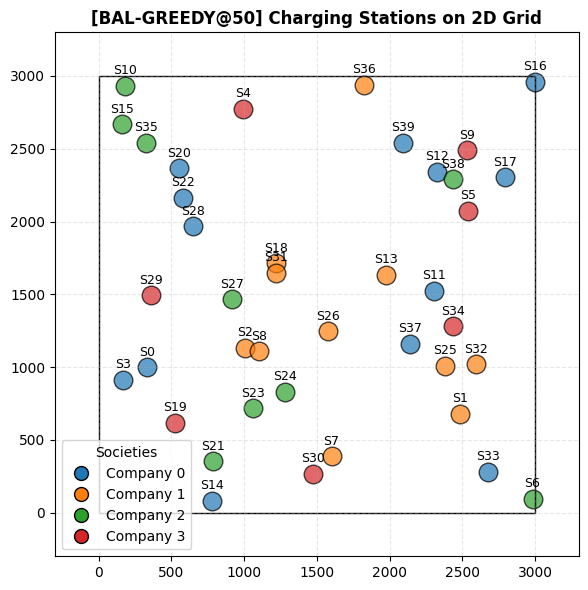

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

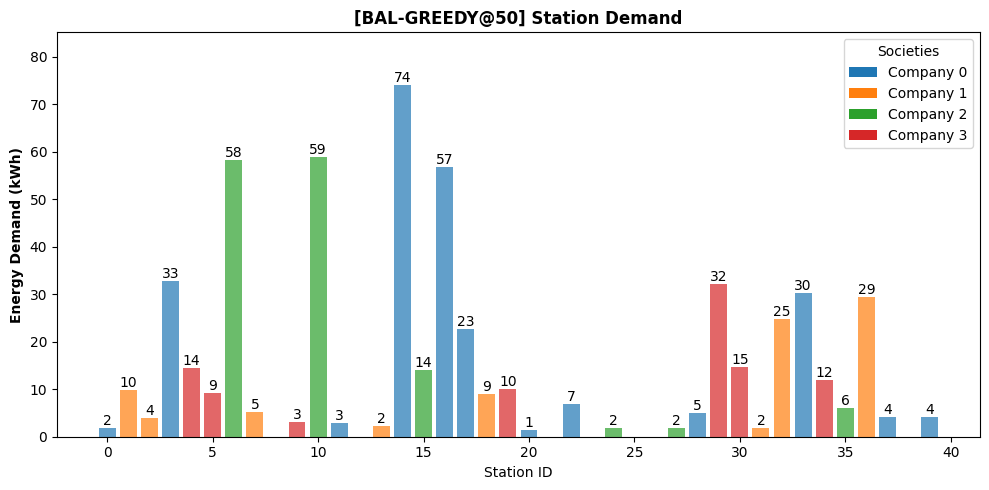

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

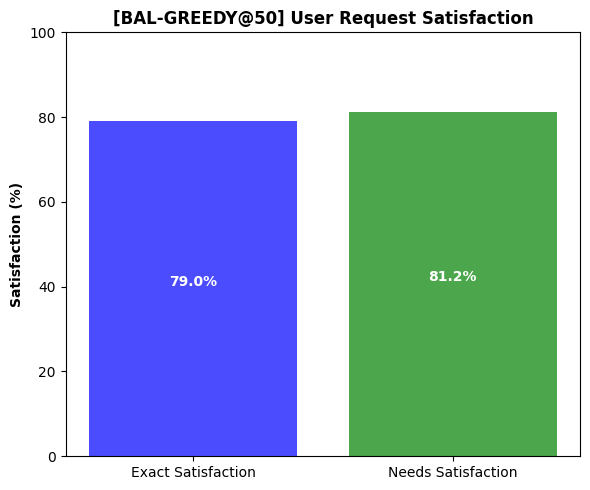

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

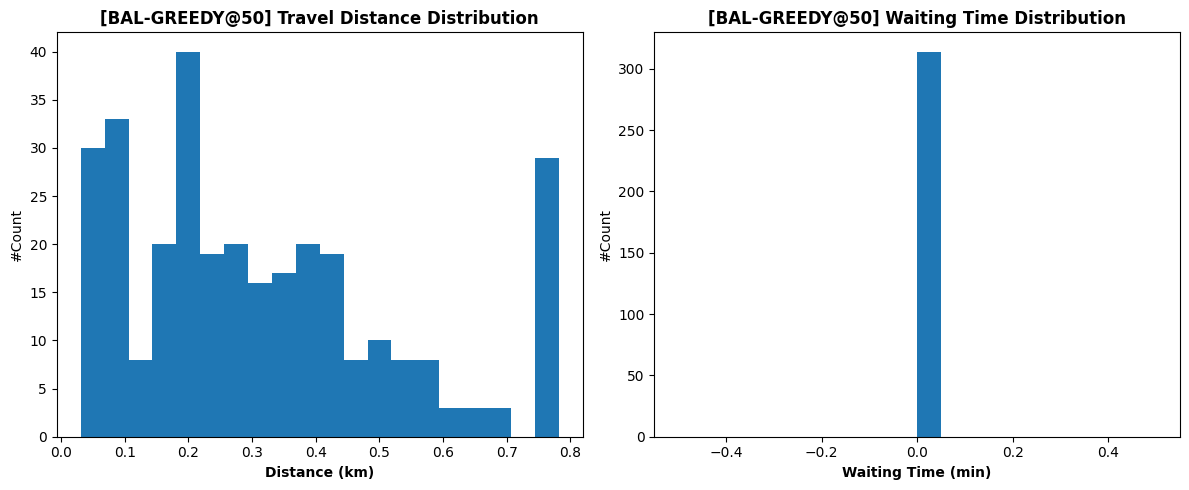

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

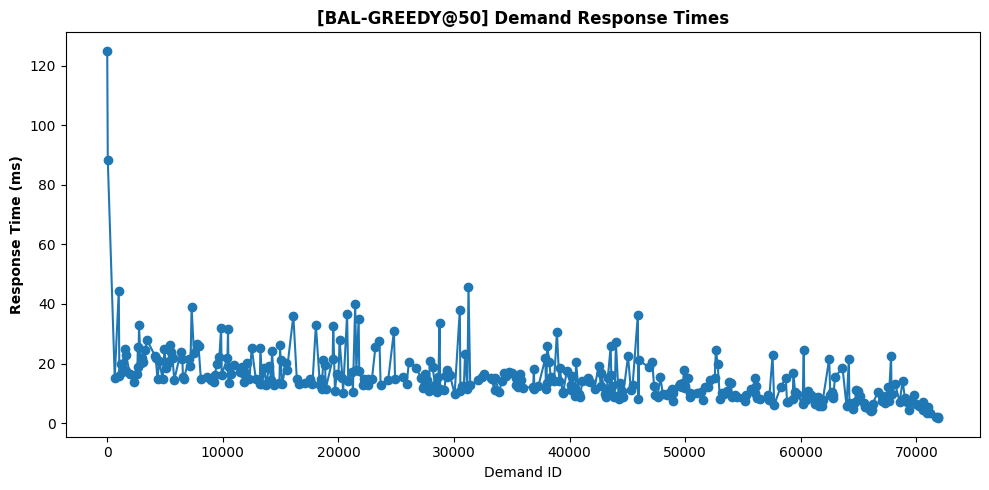

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

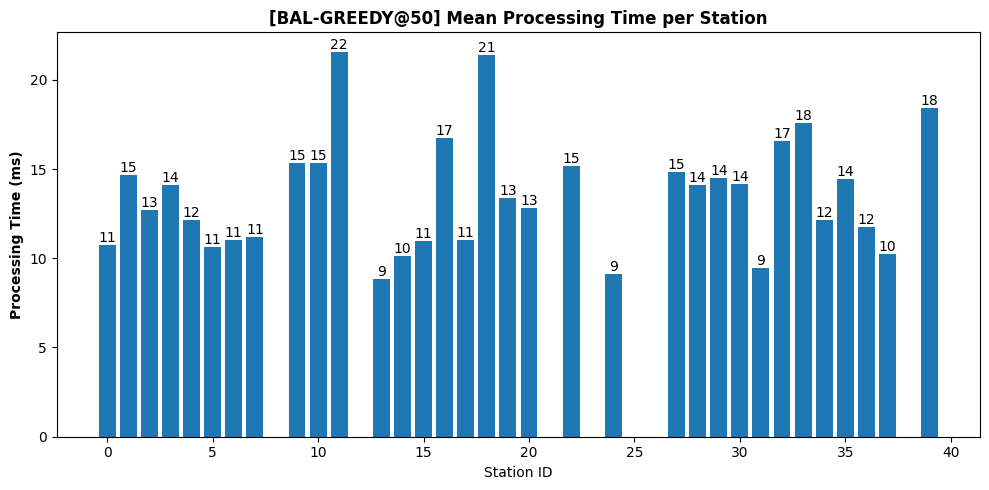

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [26]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.024306  0.000000  0.000000  0.000000  0.000000   
1            0           3  0.356944  0.106944  0.000000  0.000000  0.000000   
2            0          11  0.047222  0.000000  0.000000  0.000000  0.000000   
3            0          12  0.000000  0.000000  0.000000  0.000000  0.000000   
4            0          14  0.472917  0.282639  0.059028  0.165972       NaN   
5            0          16  0.422917  0.249306  0.047222  0.000000  0.000000   
6            0          17  0.256250  0.045139  0.000000  0.000000       NaN   
7            0          20  0.015278  0.000000  0.000000  0.000000  0.000000   
8            0          22  0.074306  0.021528  0.000000  0.000000  0.000000   
9            0          28  0.061806  0.000000  0.000000  0.000000       NaN   
10           0          33  0.295139  0.149306  0.000000  0.000000  0.000000   
11           0          37  0.042361  0.

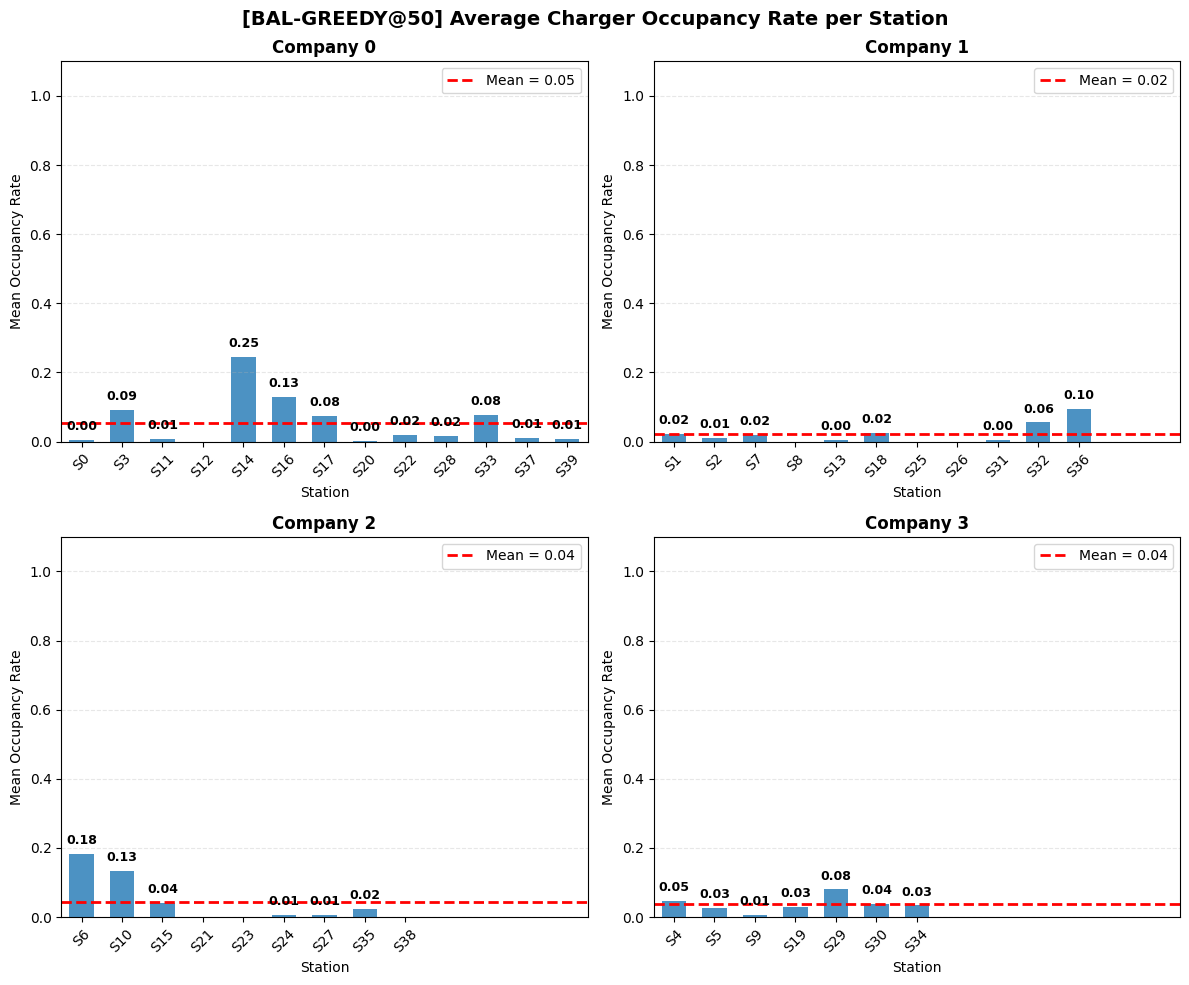

In [27]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

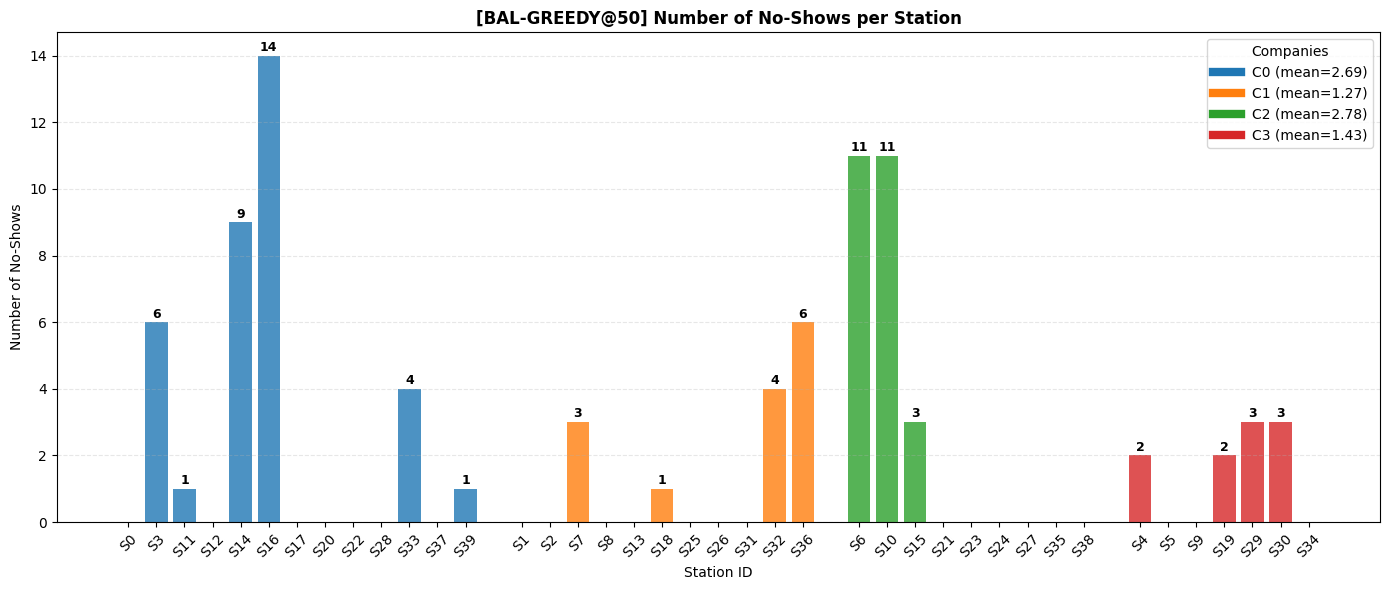

In [28]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [29]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,1,1,0,0,0,1.000000,0.000000,0.0,0.0
1,0,3,25,18,6,0,0,0.720000,0.240000,0.0,0.0
2,0,11,2,1,1,0,0,0.500000,0.500000,0.0,0.0
3,0,12,0,0,0,0,0,NaN,NaN,NaN,NaN
4,0,14,51,40,9,0,0,0.784314,0.176471,0.0,0.0
5,0,16,46,31,14,0,0,0.673913,0.304348,0.0,0.0
6,0,17,12,12,0,0,0,1.000000,0.000000,0.0,0.0
7,0,20,1,1,0,0,0,1.000000,0.000000,0.0,0.0
8,0,22,4,4,0,0,0,1.000000,0.000000,0.0,0.0
9,0,28,3,3,0,0,0,1.000000,0.000000,0.0,0.0


NUMBER OF REJECTED REQUESTS

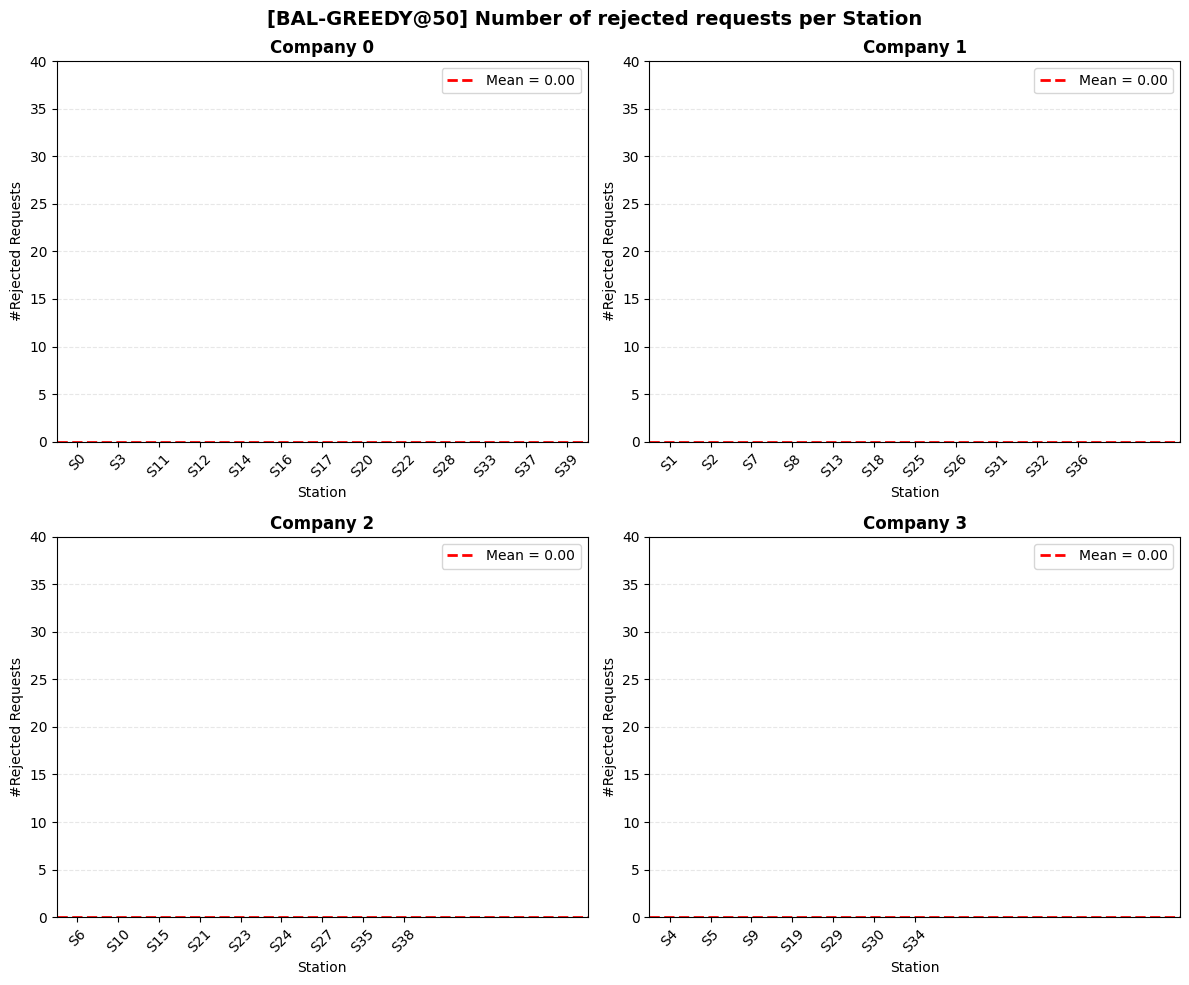

In [30]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

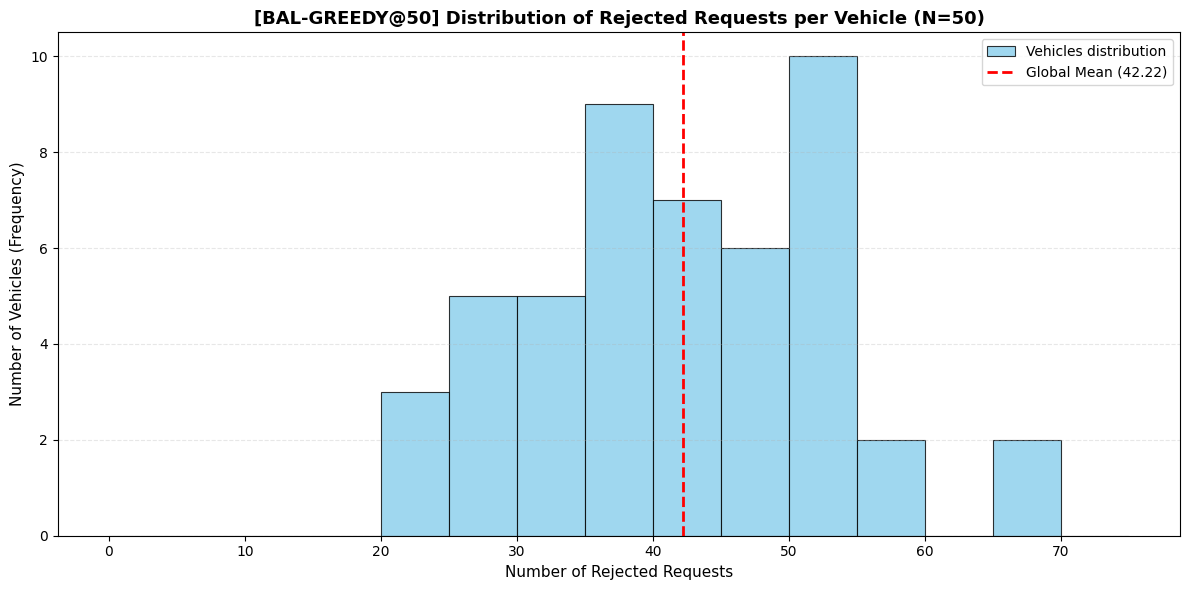

In [31]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

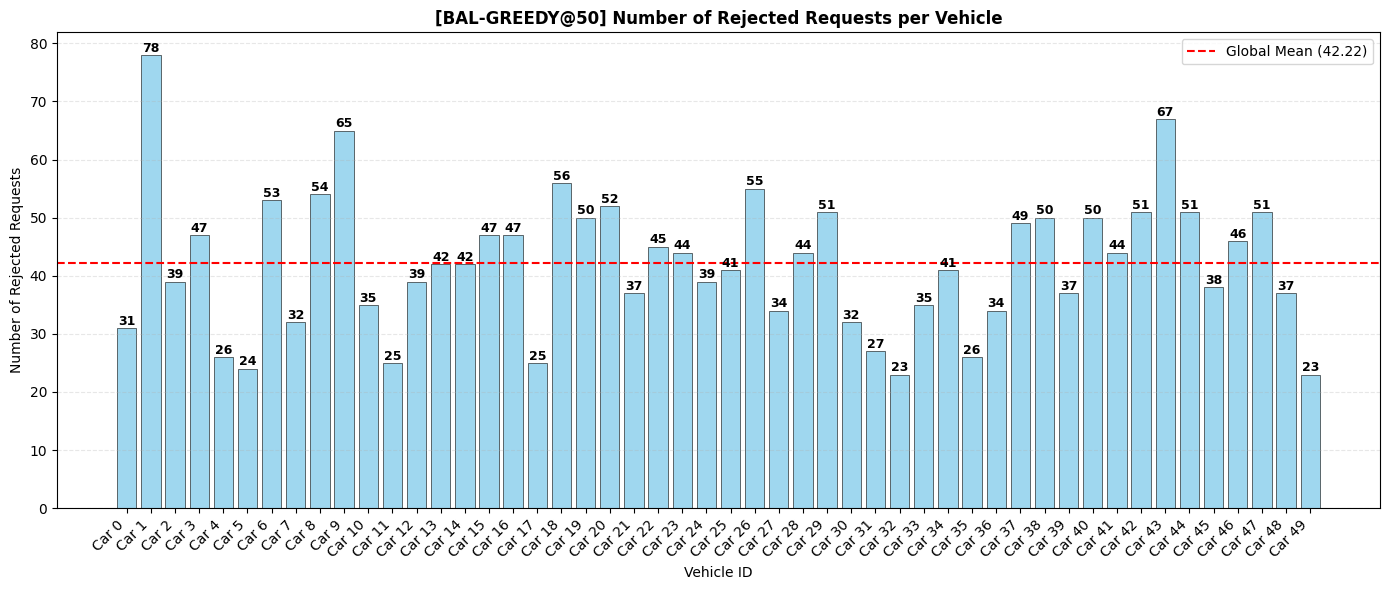

In [32]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

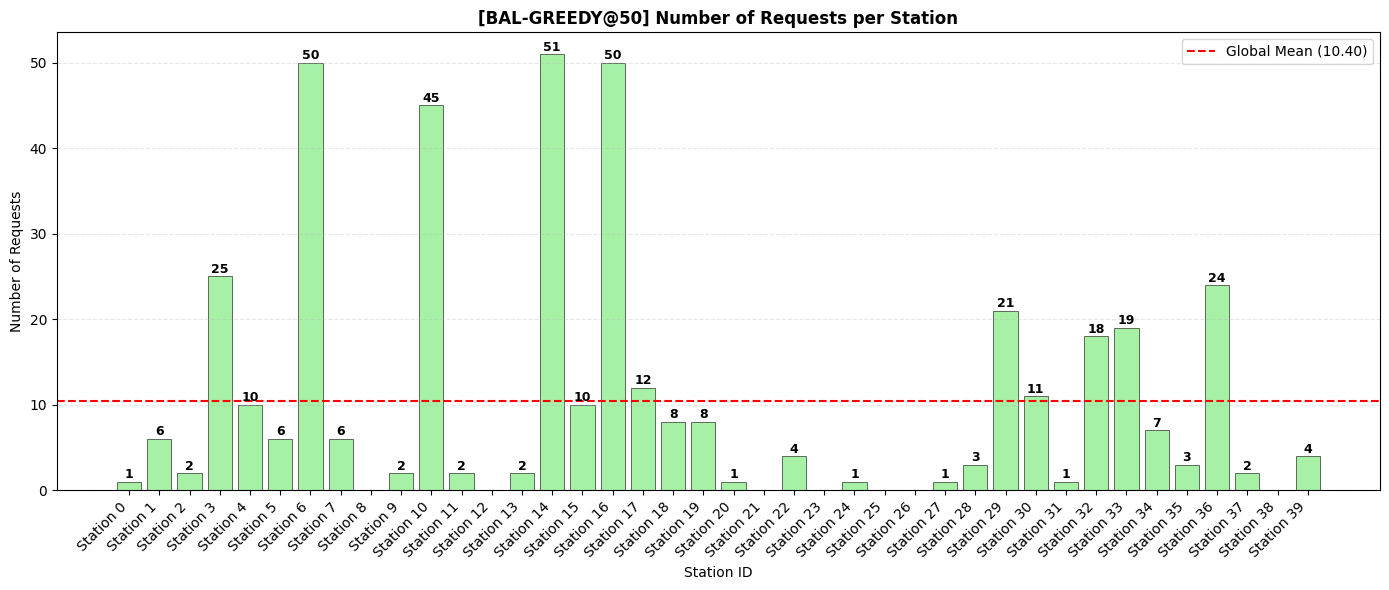

In [33]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [34]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [35]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [36]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:11:21.361 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:11:21.711 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:11:21.930 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:11:22.397 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:11:22.644 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:11:23.621 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:11:23.738 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:11:24.188 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:11:25.018 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:11:25.298 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:11:25.661 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [37]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 17.70 kWh
  Station 1: 2.50 kWh
  Station 2: 57.90 kWh
  Station 3: 12.85 kWh
  Station 4: 1.38 kWh
  Station 5: 16.55 kWh
  Station 6: 11.02 kWh
  Station 7: 6.13 kWh
  Station 8: 5.15 kWh
  Station 9: 20.89 kWh
  Station 10: 15.67 kWh
  Station 11: 0.00 kWh
  Station 12: 4.70 kWh
  Station 13: 11.29 kWh
  Station 14: 5.60 kWh
  Station 15: 0.00 kWh
  Station 16: 1.21 kWh
  Station 17: 4.45 kWh
  Station 18: 1.80 kWh
  Station 19: 3.95 kWh
  Station 20: 54.73 kWh
  Station 21: 32.23 kWh
  Station 22: 1.80 kWh
  Station 23: 5.47 kWh
  Station 24: 20.51 kWh
  Station 25: 3.08 kWh
  Station 26: 0.00 kWh
  Station 27: 0.00 kWh
  Station 28: 14.53 kWh
  Station 29: 3.08 kWh
  Station 30: 3.62 kWh
  Station 31: 22.34 kWh
  Station 32: 0.00 kWh
  Station 33: 50.87 kWh
  Station 34: 17.31 kWh
  Station 35: 65.97 kWh
  Station 36: 18.26 kWh
  Station 37: 9.97 kWh
  Station 38: 7.53 kWh
  Station 39: 1.20 kWh

--- User 

In [38]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

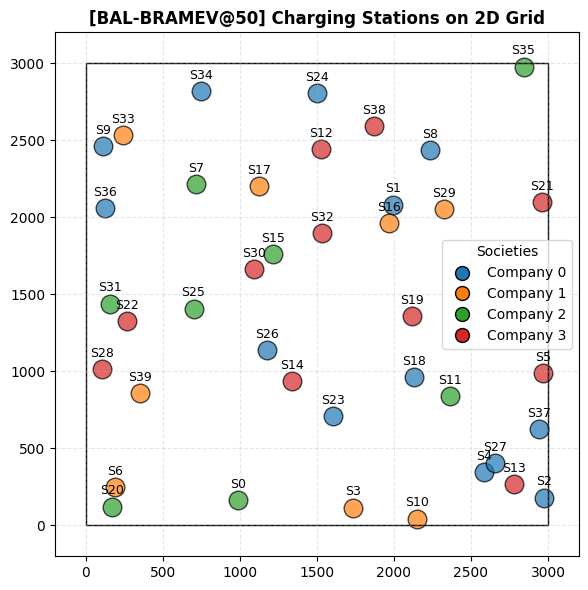

In [39]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

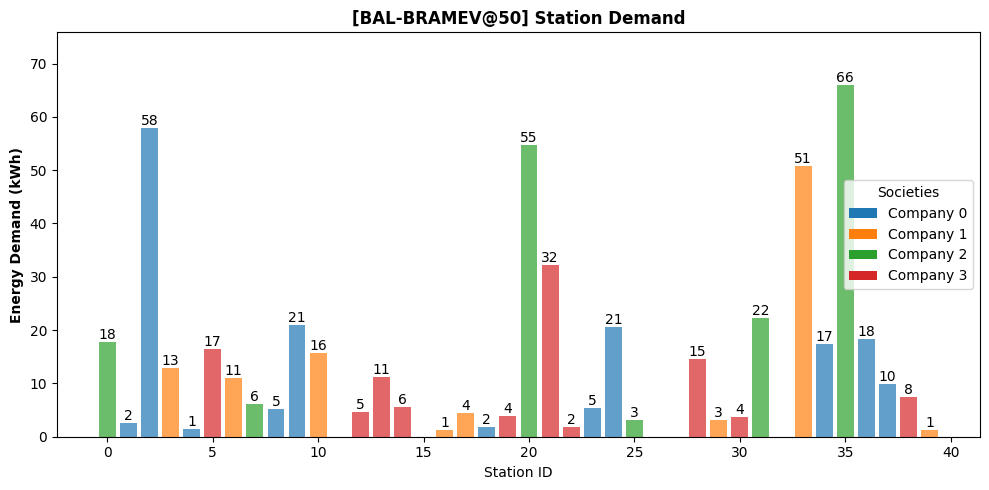

In [40]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

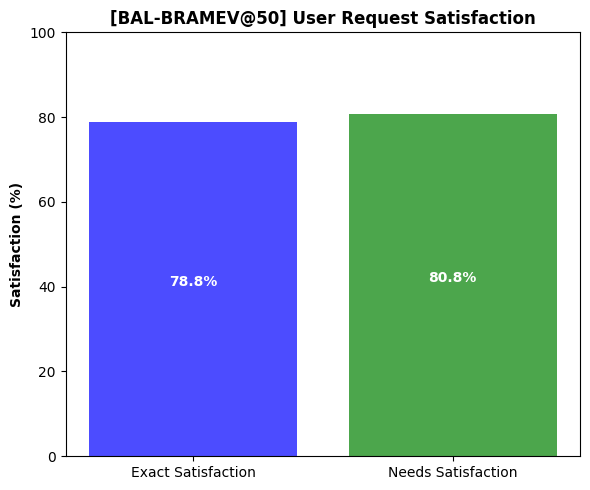

In [41]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

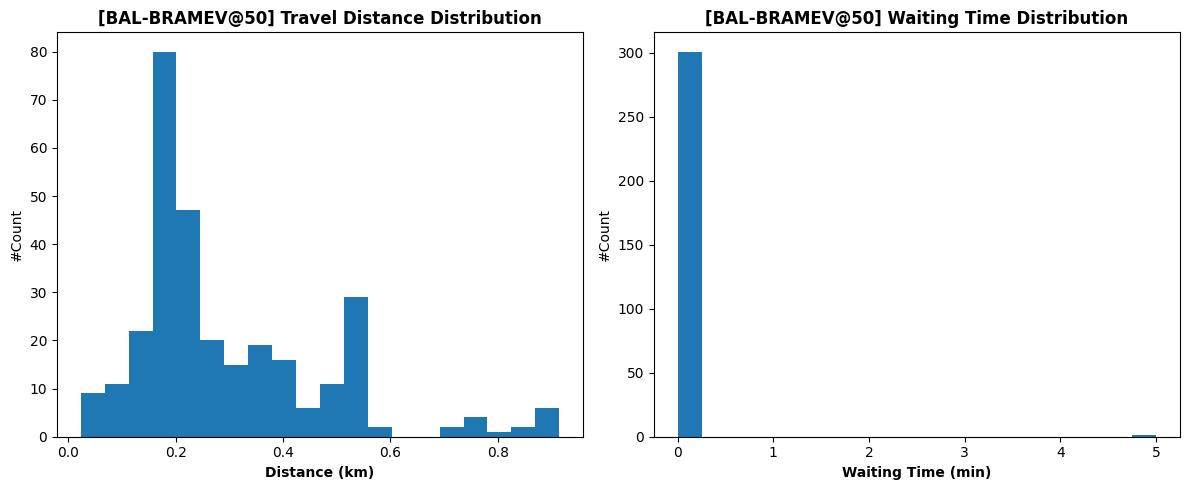

In [42]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

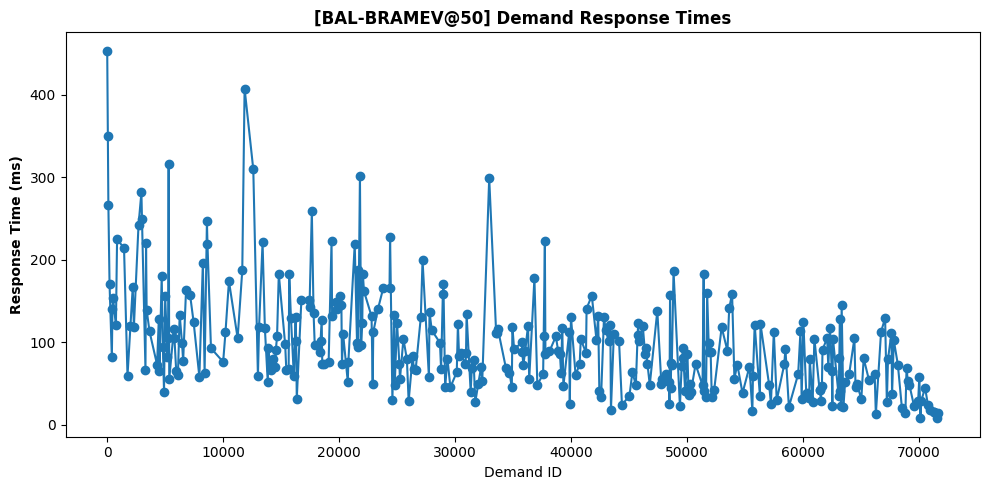

In [43]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

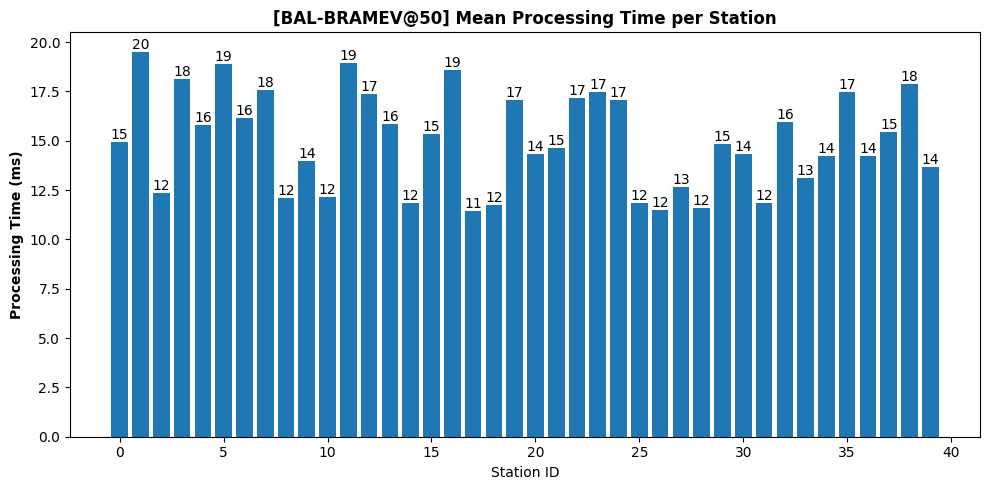

In [44]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

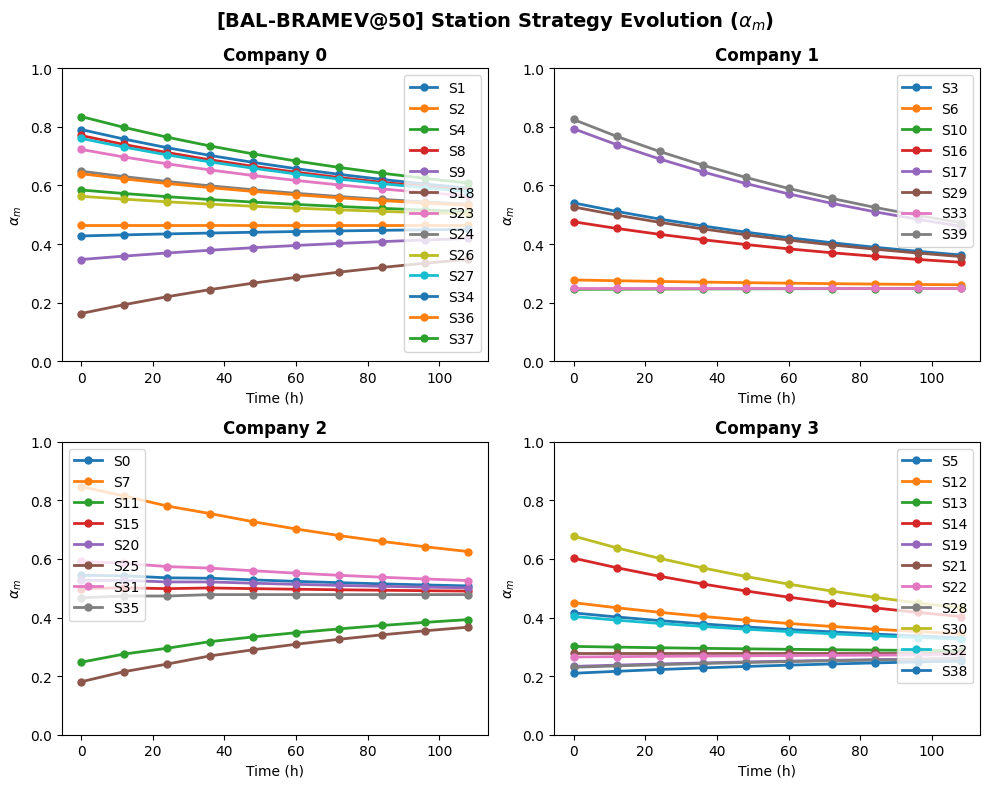

In [45]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [46]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.034722  0.000000  0.000000  0.000000  0.000000   
1            0           2  0.434722  0.297222  0.088194  0.084028       NaN   
2            0           4  0.022917  0.000000  0.000000  0.000000  0.000000   
3            0           8  0.097917  0.000000  0.000000  0.000000       NaN   
4            0           9  0.265972  0.060417  0.034722  0.000000  0.000000   
5            0          18  0.018750  0.000000  0.000000  0.000000       NaN   
6            0          23  0.076389  0.000000  0.000000  0.000000  0.000000   
7            0          24  0.191667  0.081944  0.000000  0.000000  0.000000   
8            0          26  0.000000  0.000000  0.000000  0.000000       NaN   
9            0          27  0.000000  0.000000  0.000000  0.000000       NaN   
10           0          34  0.164583  0.070139  0.000000  0.025000  0.000000   
11           0          36  0.259722  0.

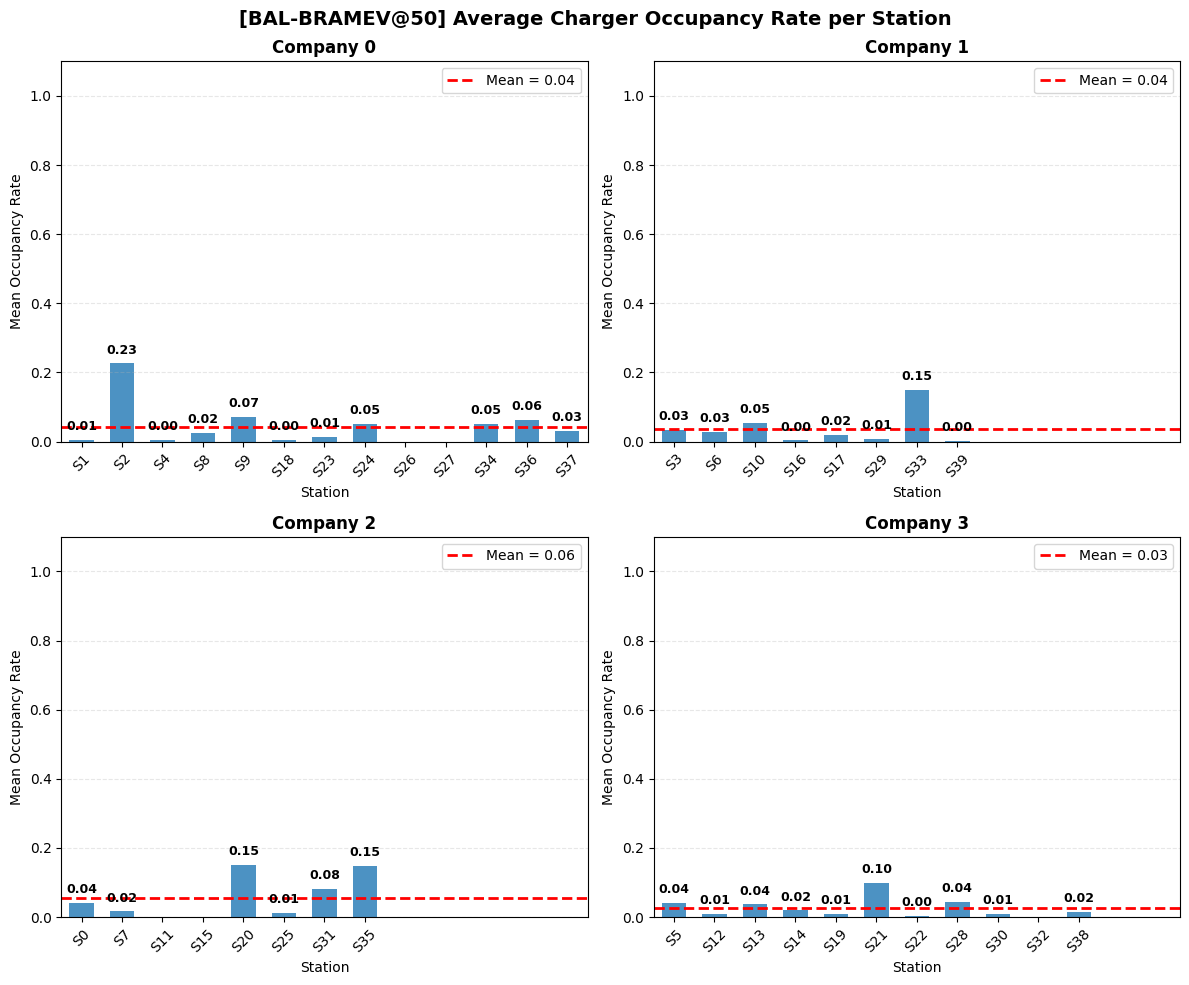

In [47]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

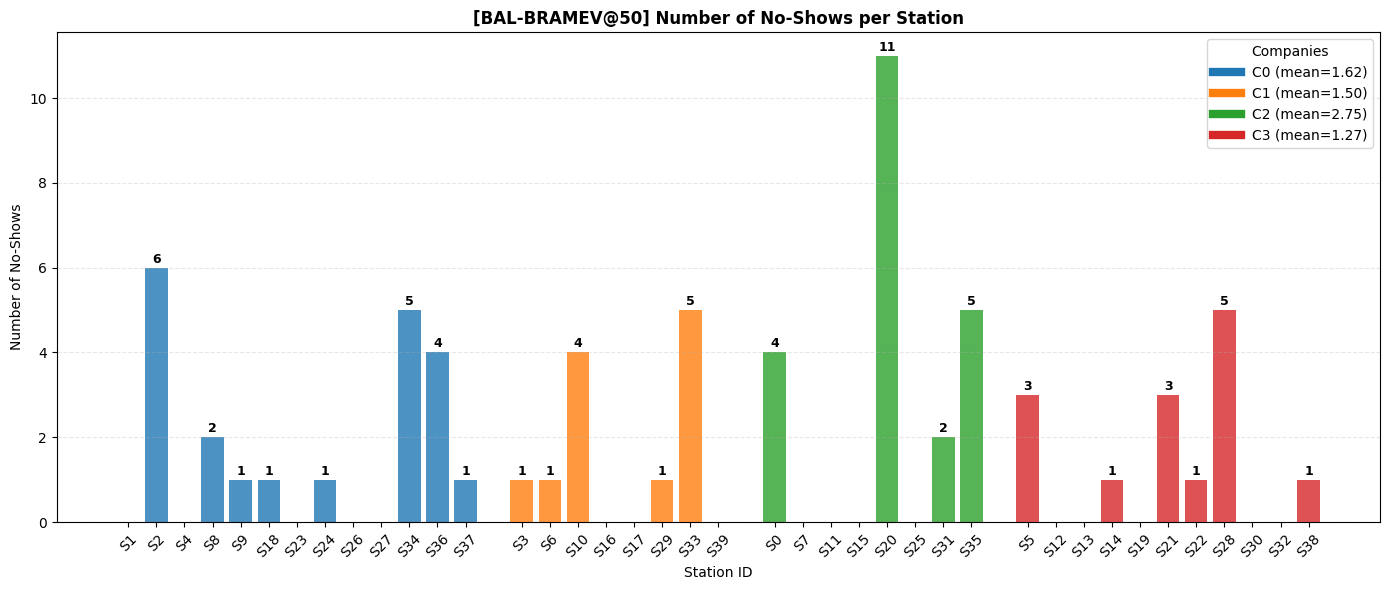

In [48]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [49]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,1,1,0,0,0,1.000000,0.000000,0.0,0.0
1,0,2,38,32,6,0,0,0.842105,0.157895,0.0,0.0
2,0,4,1,1,0,0,0,1.000000,0.000000,0.0,0.0
3,0,8,5,3,2,0,0,0.600000,0.400000,0.0,0.0
4,0,9,14,12,1,0,0,0.857143,0.071429,0.0,0.0
5,0,18,2,1,1,0,0,0.500000,0.500000,0.0,0.0
6,0,23,3,3,0,0,0,1.000000,0.000000,0.0,0.0
7,0,24,14,13,1,0,0,0.928571,0.071429,0.0,0.0
8,0,26,0,0,0,0,0,NaN,NaN,NaN,NaN
9,0,27,0,0,0,0,0,NaN,NaN,NaN,NaN


NUMBER OF REJECTED REQUESTS

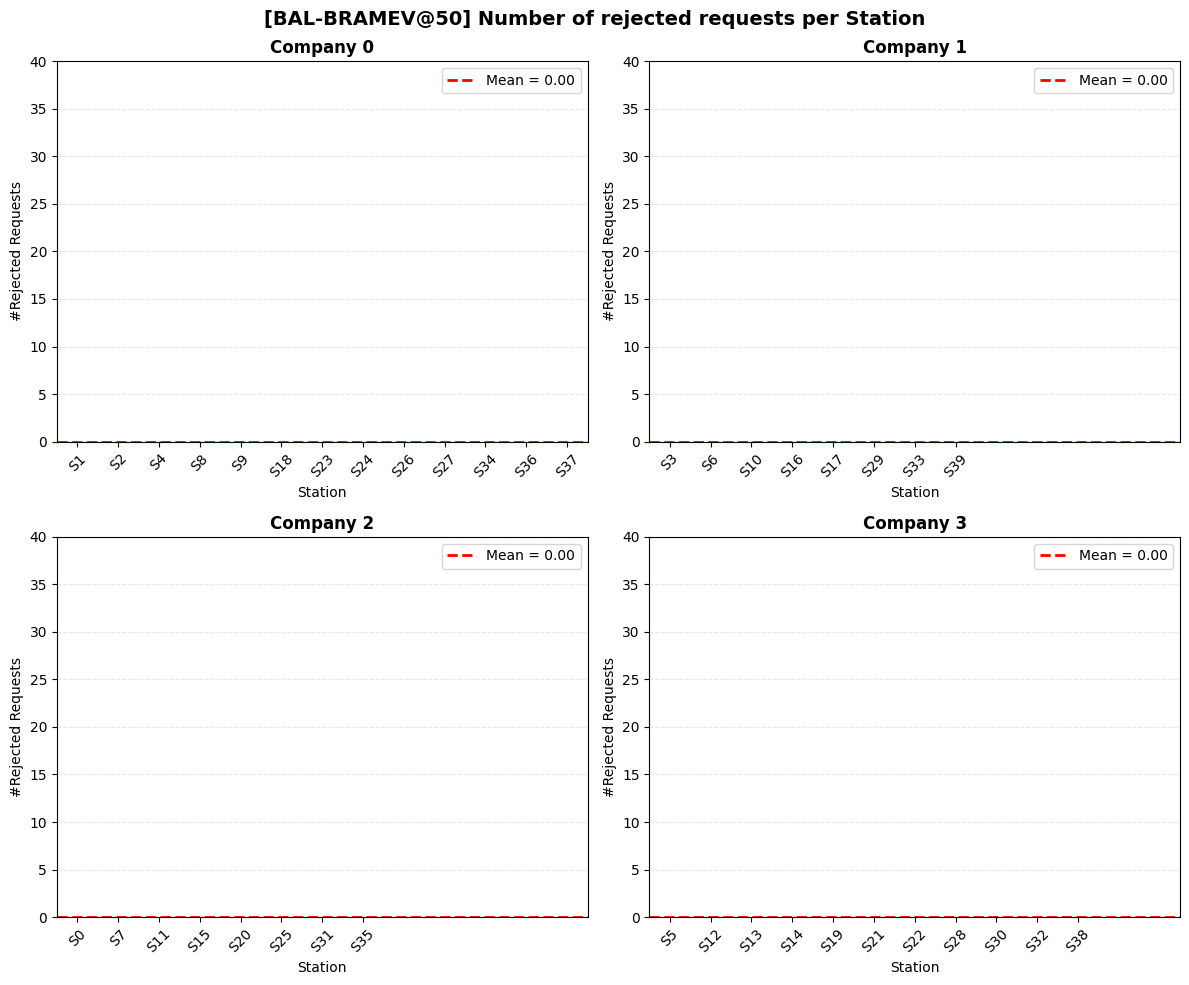

In [50]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

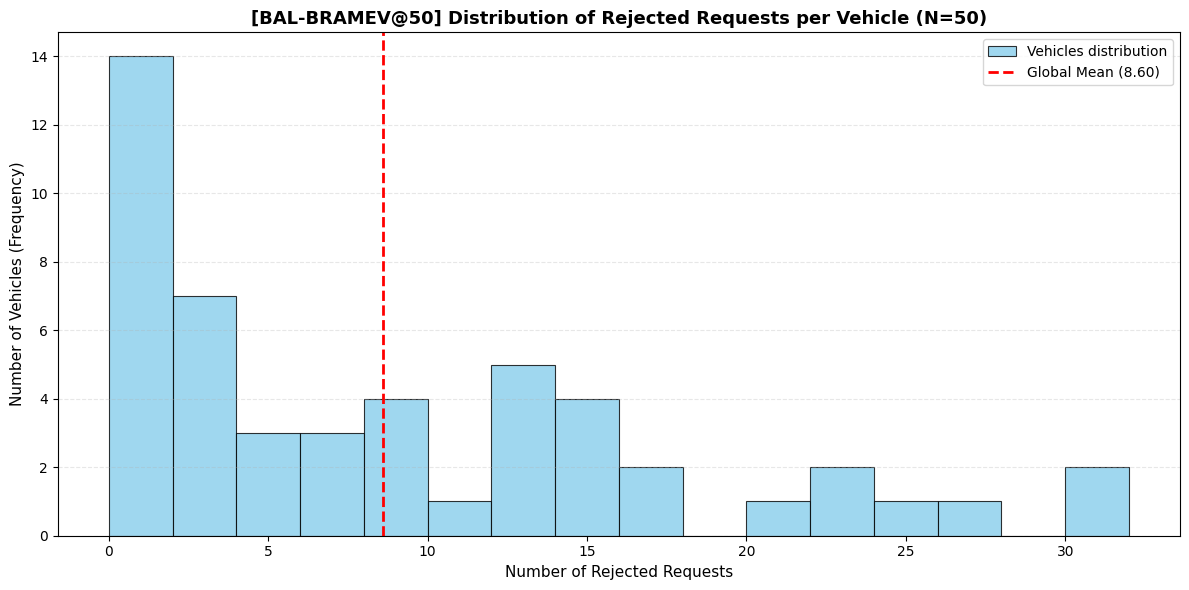

In [51]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

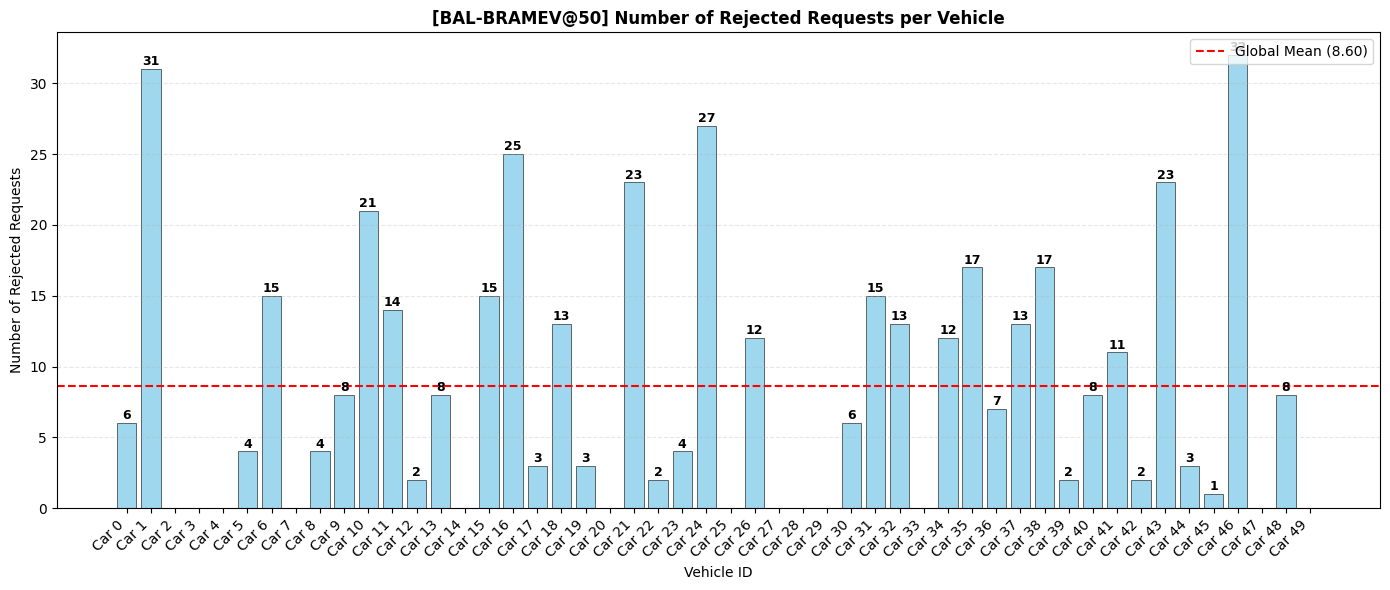

In [52]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

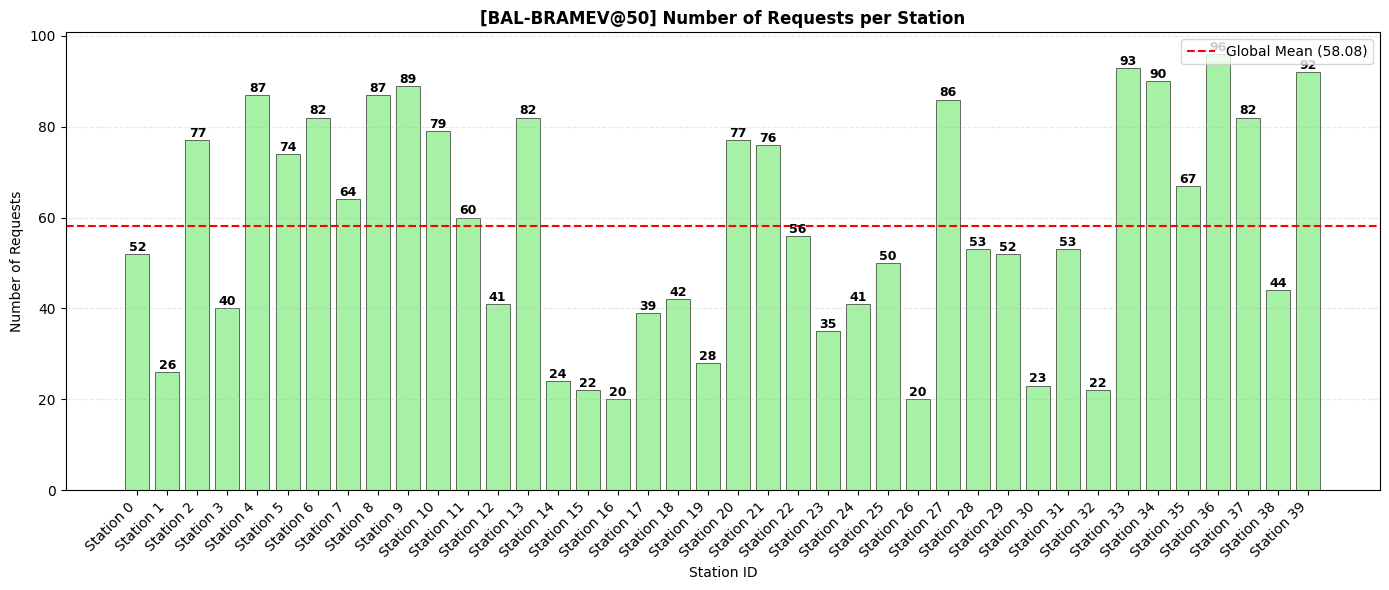

In [53]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [54]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

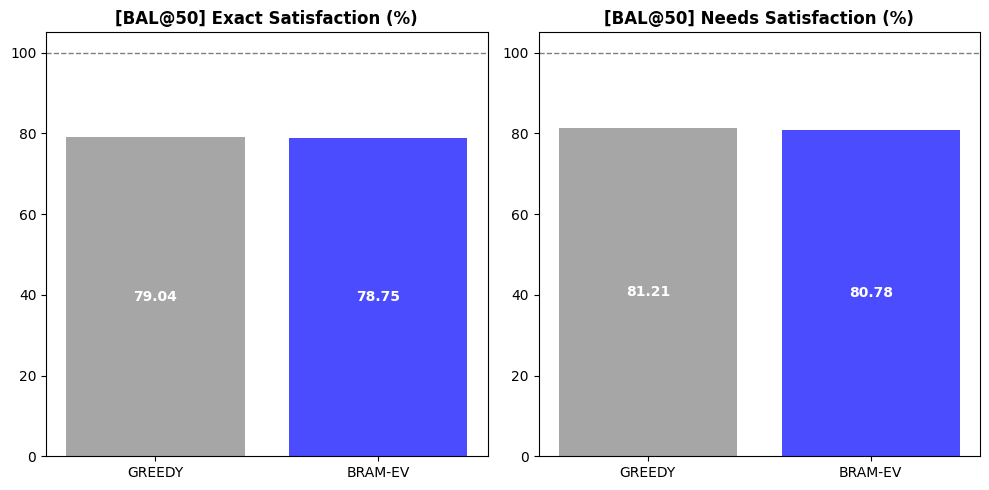

In [55]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

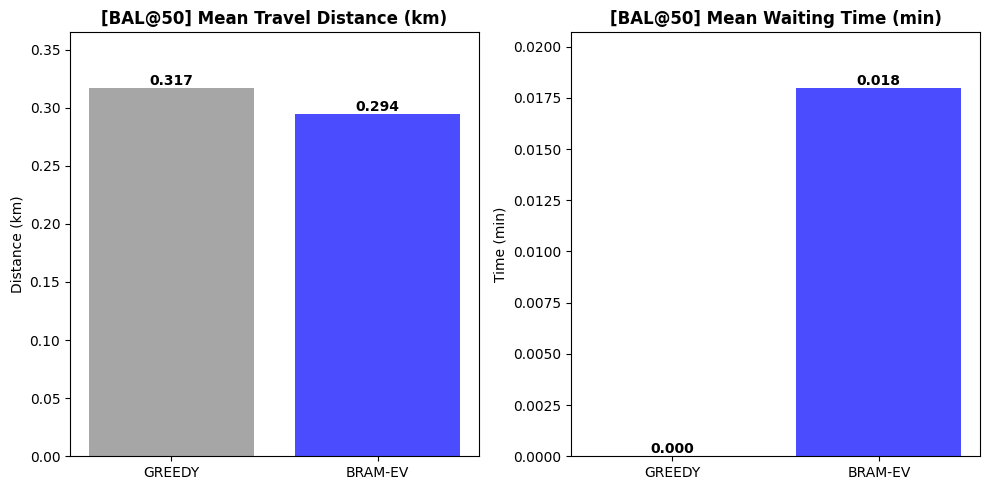

In [56]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

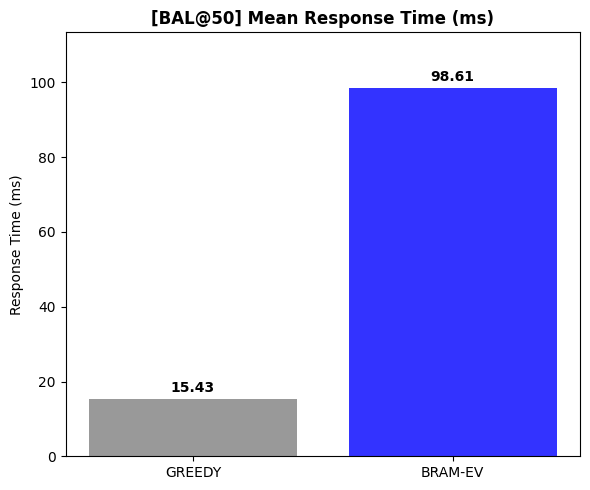

In [57]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [58]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [59]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [60]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [61]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:11:55.235 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:11:55.348 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:11:55.592 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:11:55.697 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:11:56.113 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:11:56.168 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:11:56.466 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:11:56.530 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:11:56.699 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:11:56.797 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:11:56.955 | IN

##### *Metrics*

In [62]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 17.64 kWh
  Station 1: 32.20 kWh
  Station 2: 3.23 kWh
  Station 3: 30.69 kWh
  Station 4: 42.36 kWh
  Station 5: 100.02 kWh
  Station 6: 5.74 kWh
  Station 7: 24.44 kWh
  Station 8: 20.17 kWh
  Station 9: 7.67 kWh
  Station 10: 3.40 kWh
  Station 11: 0.00 kWh
  Station 12: 155.12 kWh
  Station 13: 47.20 kWh
  Station 14: 2.27 kWh
  Station 15: 1.15 kWh
  Station 16: 74.99 kWh
  Station 17: 1.21 kWh
  Station 18: 11.00 kWh
  Station 19: 54.30 kWh
  Station 20: 22.21 kWh
  Station 21: 0.00 kWh
  Station 22: 5.66 kWh
  Station 23: 2.56 kWh
  Station 24: 15.01 kWh
  Station 25: 24.70 kWh
  Station 26: 7.33 kWh
  Station 27: 38.61 kWh
  Station 28: 5.82 kWh
  Station 29: 4.38 kWh
  Station 30: 2.10 kWh
  Station 31: 192.00 kWh
  Station 32: 7.28 kWh
  Station 33: 0.00 kWh
  Station 34: 26.86 kWh
  Station 35: 14.86 kWh
  Station 36: 4.90 kWh
  Station 37: 3.27 kWh
  Station 38: 21.80 kWh
  Station 39: 0.70 kWh

---

In [63]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

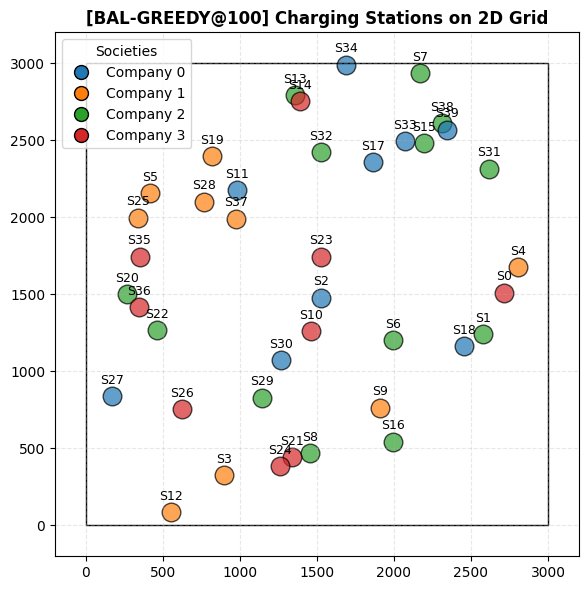

In [64]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

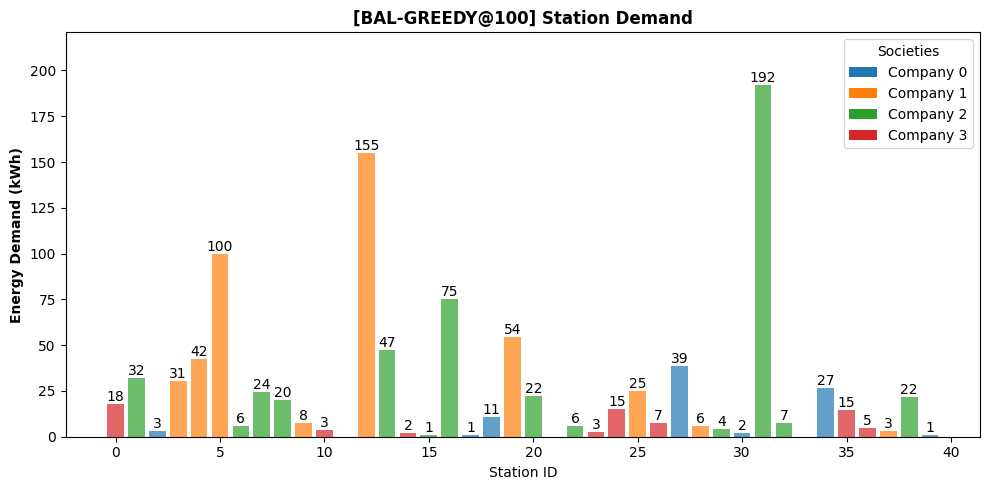

In [65]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

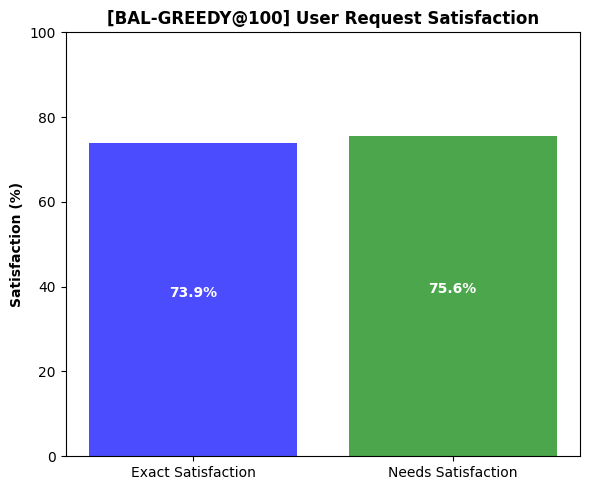

In [66]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

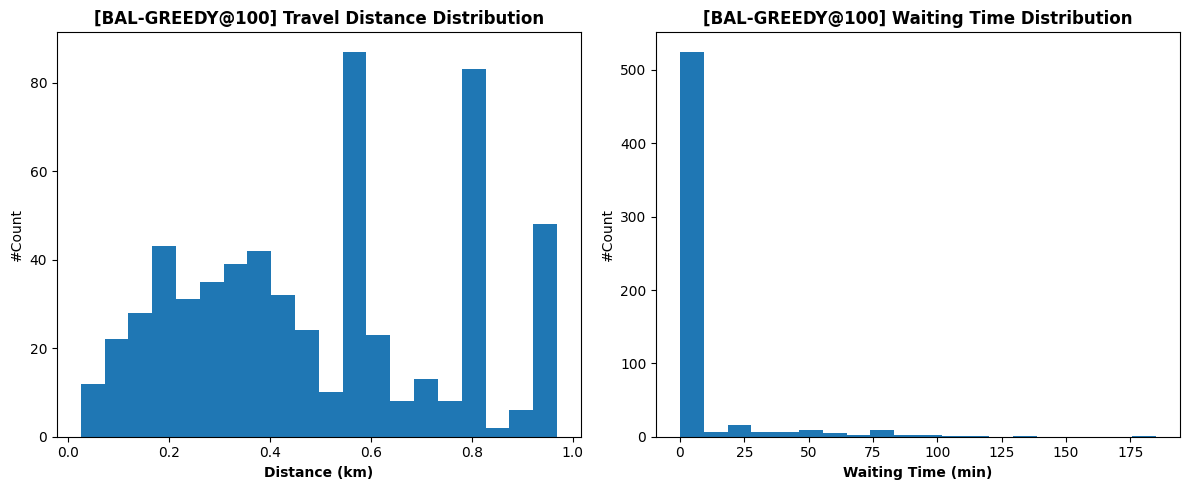

In [67]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

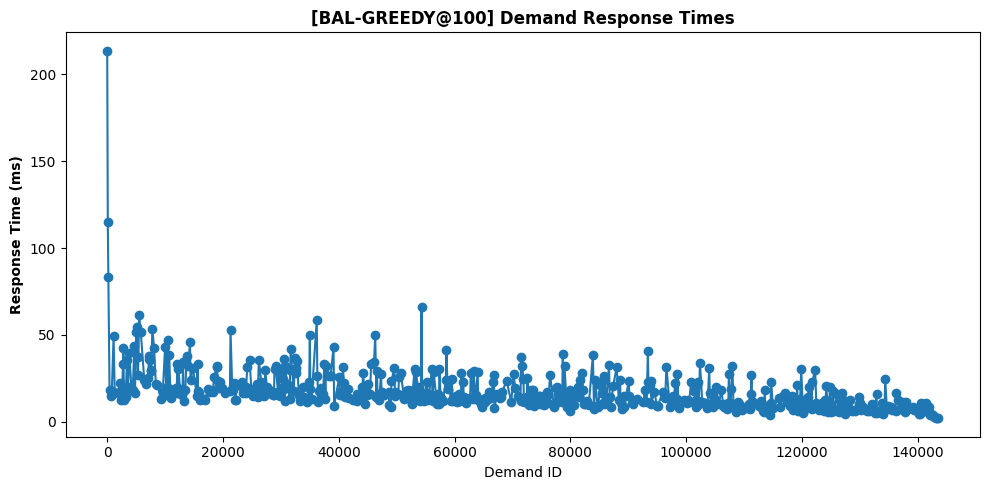

In [68]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

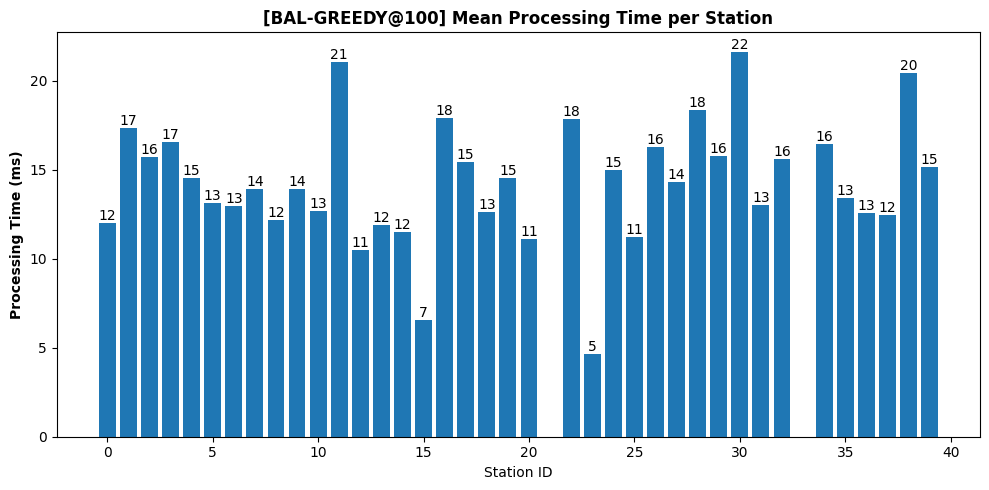

In [69]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [70]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.041667  0.000000  0.000000  0.000000  0.000000   
1            0          11  0.000000  0.000000  0.000000  0.000000  0.000000   
2            0          17  0.020139  0.000000  0.000000  0.000000  0.000000   
3            0          18  0.135417  0.000000  0.000000  0.000000       NaN   
4            0          27  0.409722  0.179861  0.025694  0.000000  0.010417   
5            0          30  0.000000  0.000000  0.000000  0.000000  0.000000   
6            0          33  0.000000  0.000000  0.000000  0.000000  0.000000   
7            0          34  0.283333  0.060417  0.000000  0.000000  0.056944   
8            0          39  0.009722  0.000000  0.000000  0.000000  0.000000   
9            1           3  0.218056  0.123611  0.000000  0.000000  0.072917   
10           1           4  0.384722  0.118056  0.045139  0.000000  0.050694   
11           1           5  0.530556  0.

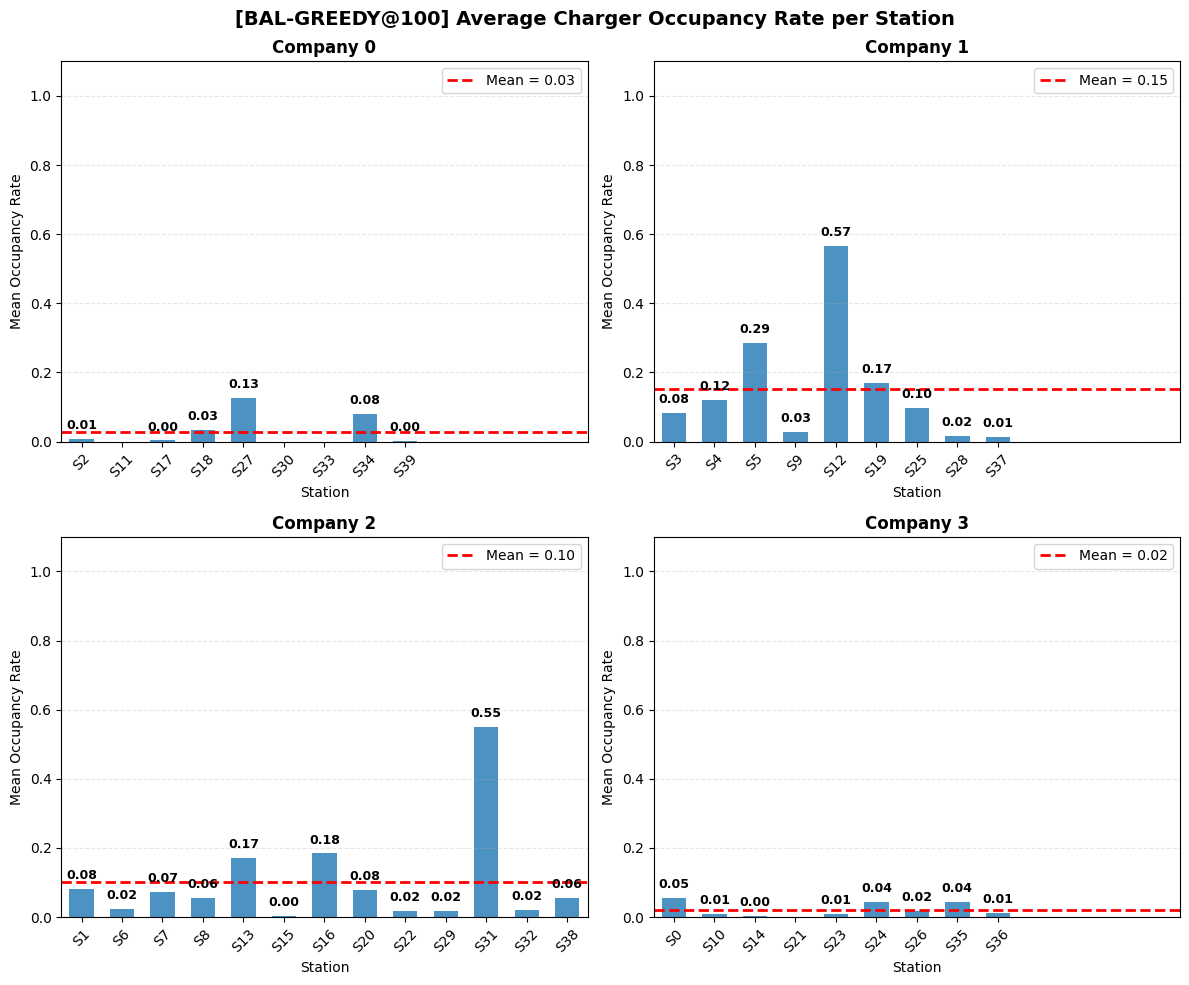

In [71]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

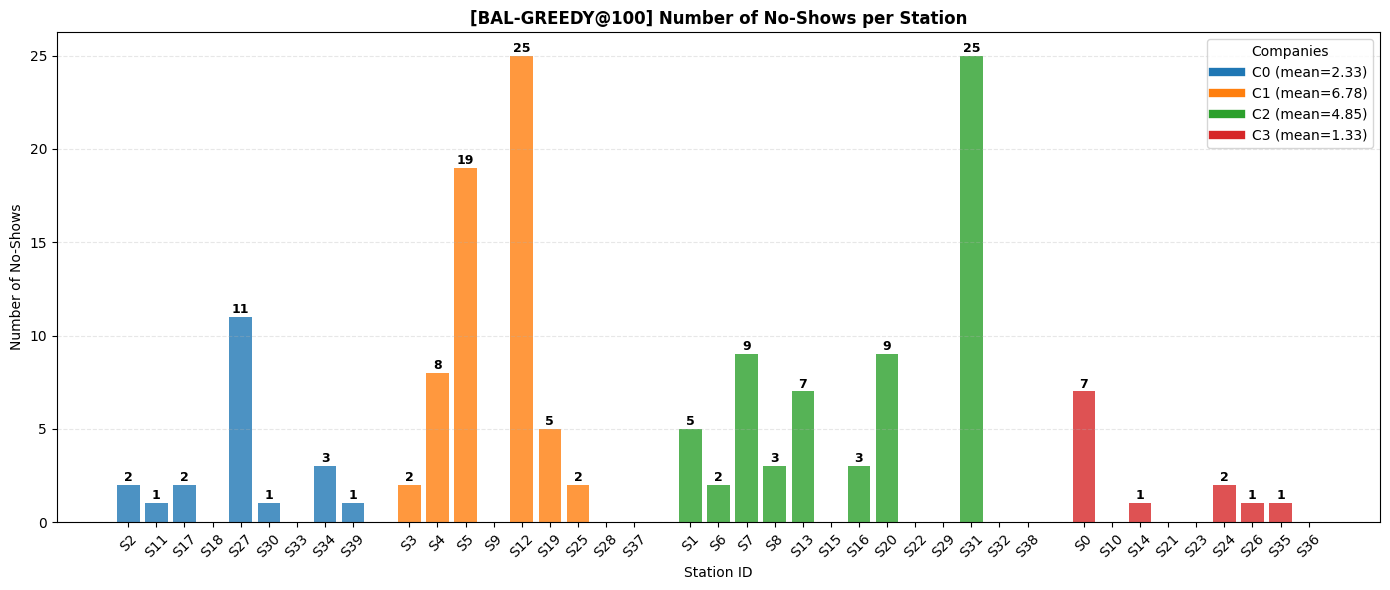

In [72]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [73]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,4,2,2,0,0,0.500000,0.500000,0.0,0.0
1,0,11,1,0,1,0,0,0.000000,1.000000,0.0,0.0
2,0,17,3,1,2,0,0,0.333333,0.666667,0.0,0.0
3,0,18,6,6,0,0,0,1.000000,0.000000,0.0,0.0
4,0,27,34,23,11,0,0,0.676471,0.323529,0.0,0.0
5,0,30,3,1,1,0,0,0.333333,0.333333,0.0,0.0
6,0,33,0,0,0,0,0,NaN,NaN,NaN,NaN
7,0,34,19,15,3,0,0,0.789474,0.157895,0.0,0.0
8,0,39,2,1,1,0,0,0.500000,0.500000,0.0,0.0
9,1,3,17,15,2,0,0,0.882353,0.117647,0.0,0.0


NUMBER OF REJECTED REQUESTS

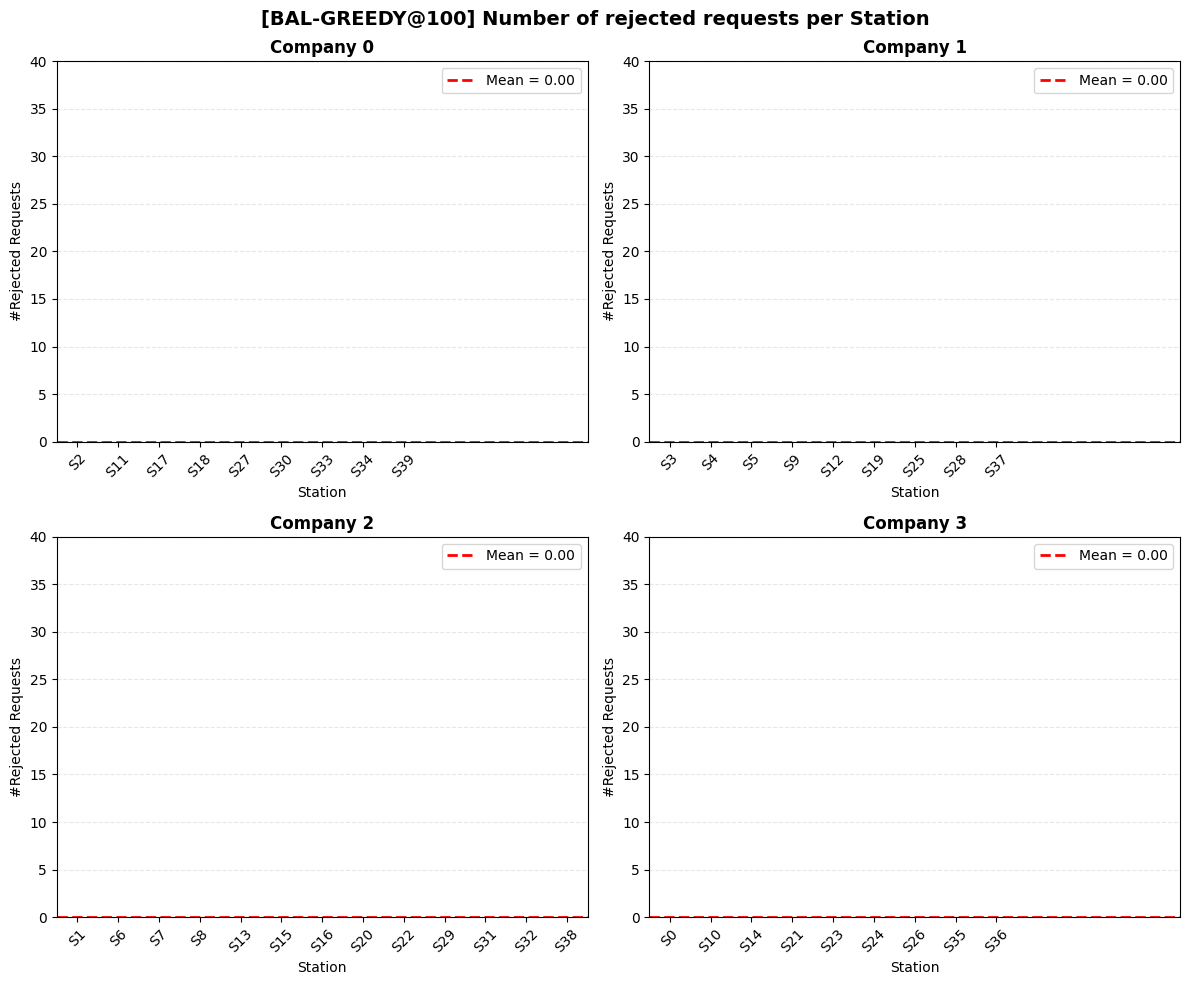

In [74]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

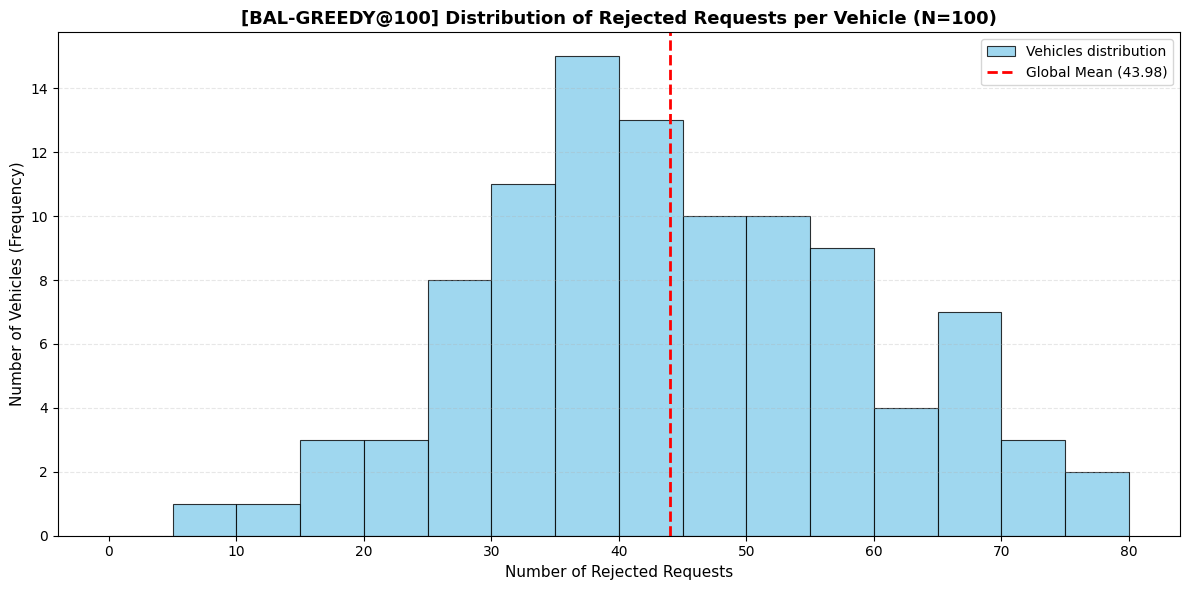

In [75]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

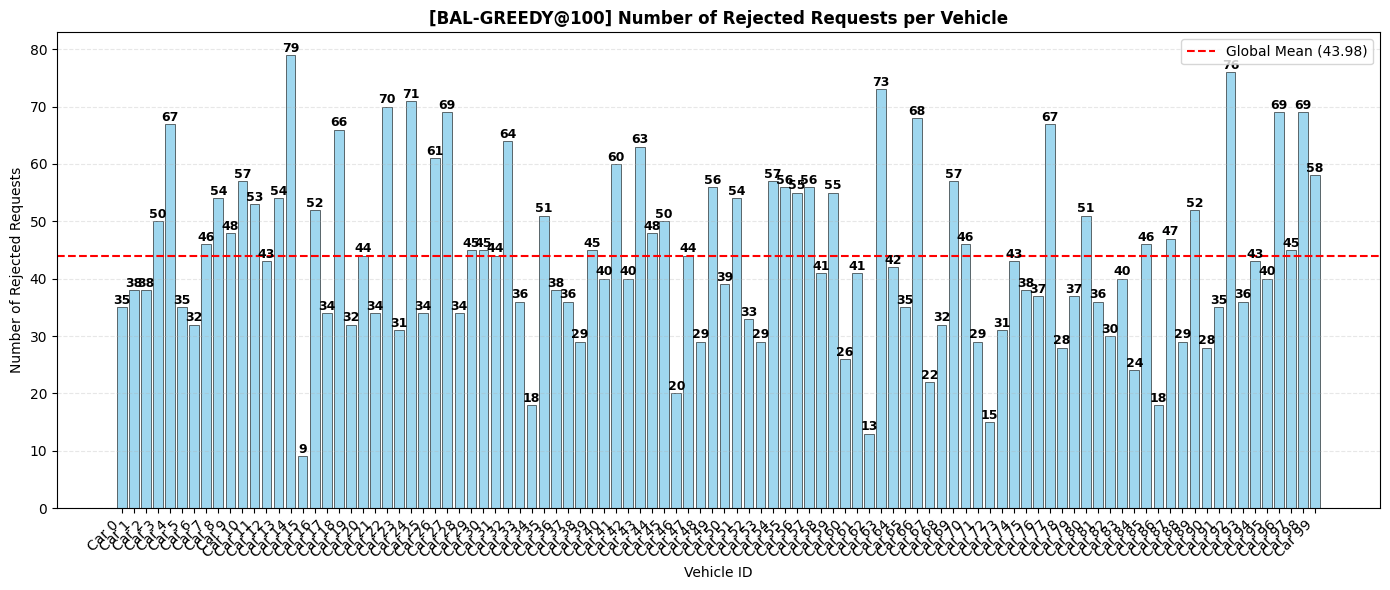

In [76]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

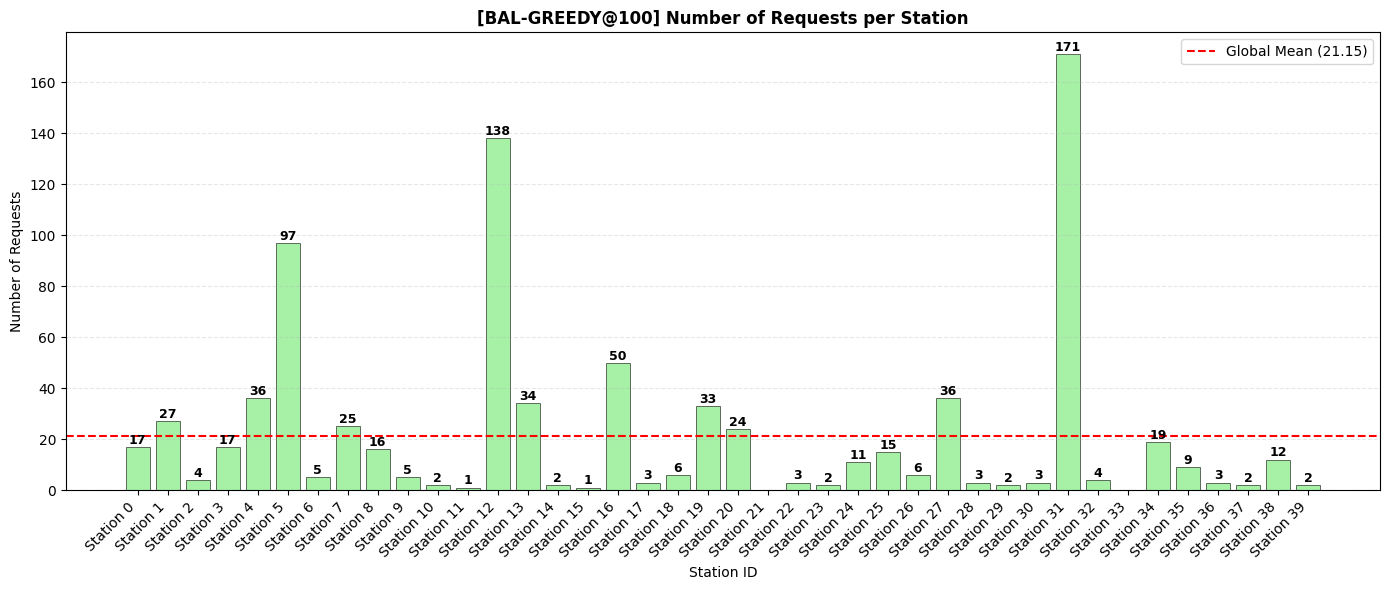

In [77]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [78]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [79]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [80]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:12:09.043 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:12:09.515 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:12:10.088 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:12:10.791 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:12:11.279 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:12:12.282 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:12:13.642 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:12:14.829 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:12:15.457 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:12:16.357 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:12:17.194 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [81]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 5.95 kWh
  Station 1: 63.38 kWh
  Station 2: 20.30 kWh
  Station 3: 7.43 kWh
  Station 4: 4.22 kWh
  Station 5: 59.75 kWh
  Station 6: 24.18 kWh
  Station 7: 7.37 kWh
  Station 8: 85.61 kWh
  Station 9: 104.59 kWh
  Station 10: 20.86 kWh
  Station 11: 19.44 kWh
  Station 12: 27.73 kWh
  Station 13: 5.38 kWh
  Station 14: 5.40 kWh
  Station 15: 3.13 kWh
  Station 16: 17.07 kWh
  Station 17: 5.09 kWh
  Station 18: 20.83 kWh
  Station 19: 25.23 kWh
  Station 20: 20.18 kWh
  Station 21: 17.15 kWh
  Station 22: 38.98 kWh
  Station 23: 17.89 kWh
  Station 24: 14.11 kWh
  Station 25: 3.10 kWh
  Station 26: 0.00 kWh
  Station 27: 53.82 kWh
  Station 28: 35.41 kWh
  Station 29: 108.38 kWh
  Station 30: 9.64 kWh
  Station 31: 24.18 kWh
  Station 32: 3.11 kWh
  Station 33: 1.42 kWh
  Station 34: 10.48 kWh
  Station 35: 4.72 kWh
  Station 36: 8.48 kWh
  Station 37: 3.88 kWh
  Station 38: 36.13 kWh
  Station 39: 115.73 kWh


In [82]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

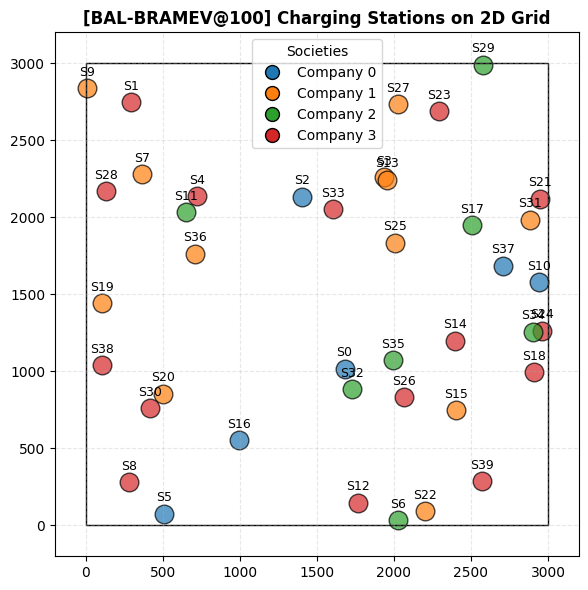

In [83]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

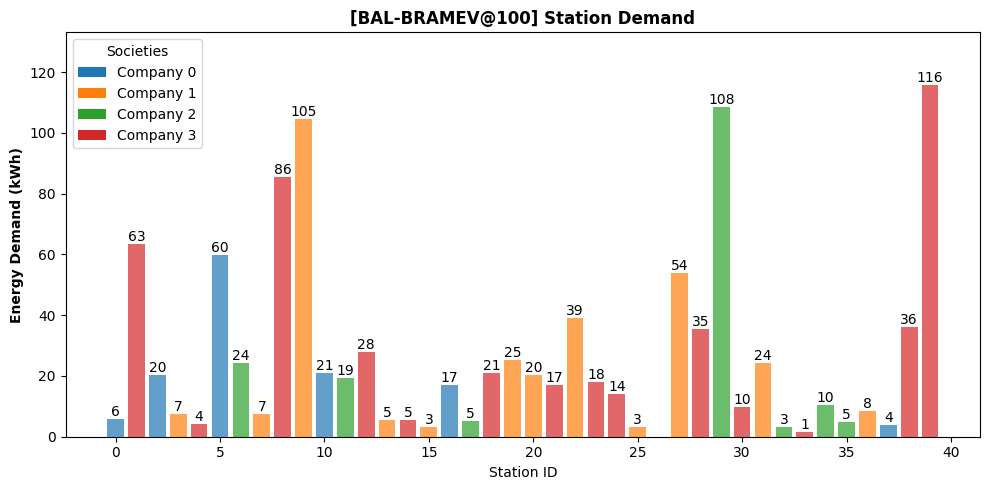

In [84]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

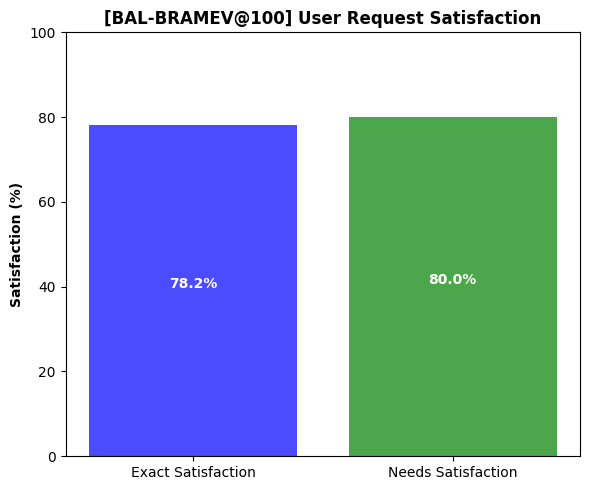

In [85]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

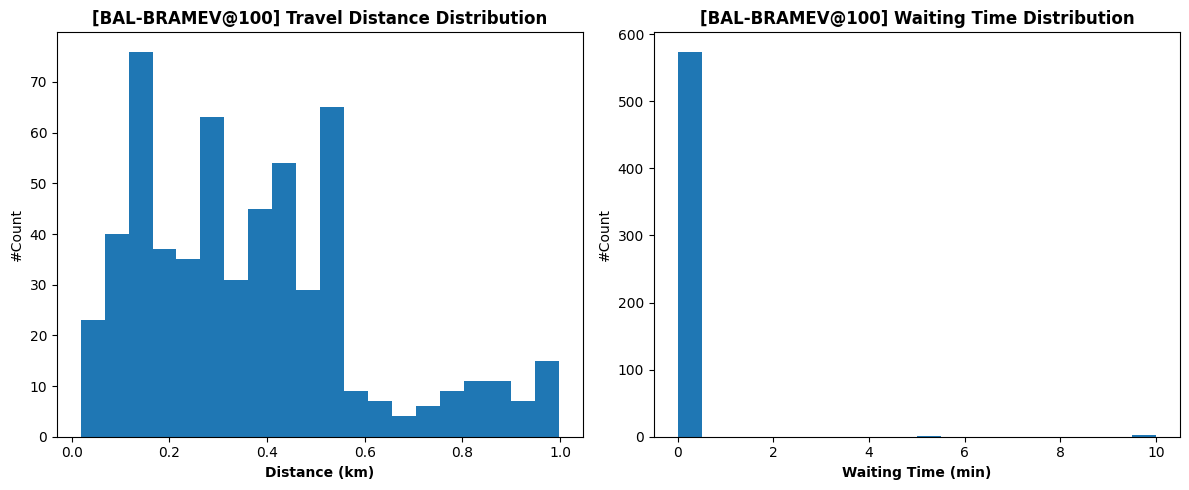

In [86]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

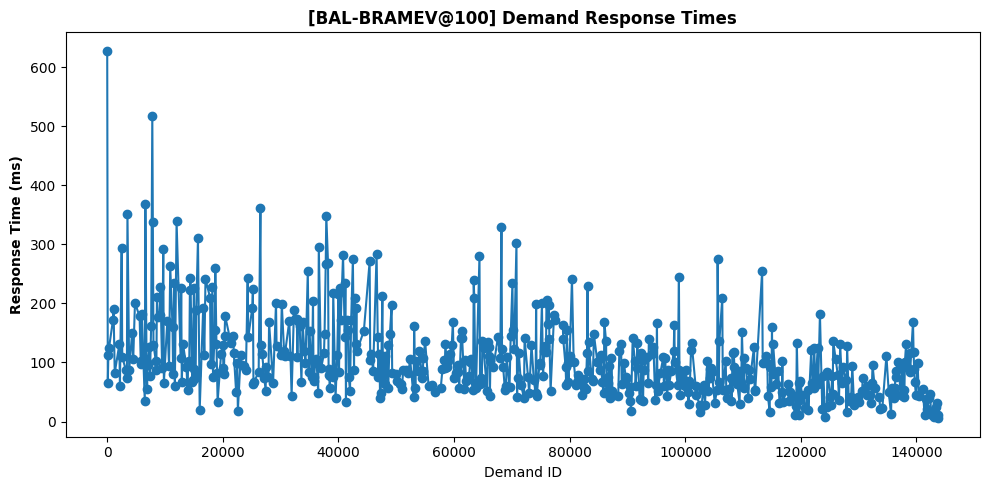

In [87]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

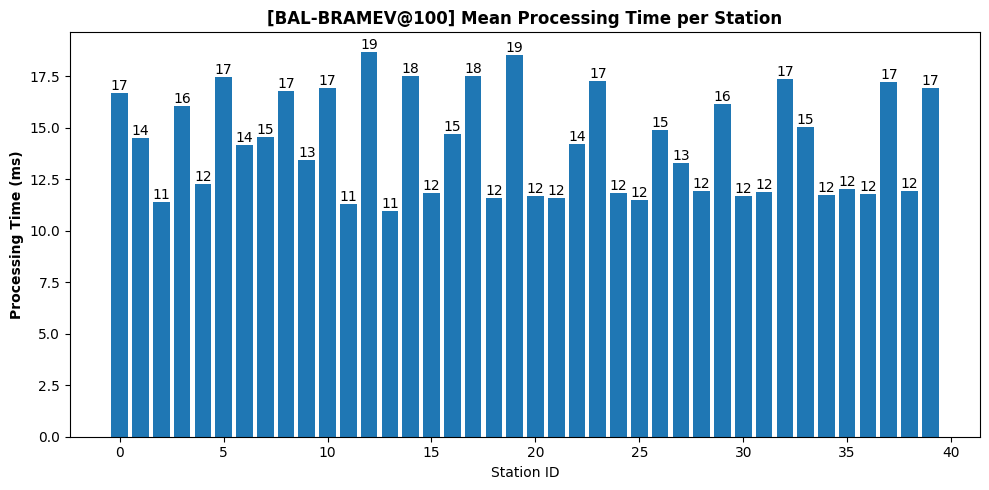

In [88]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

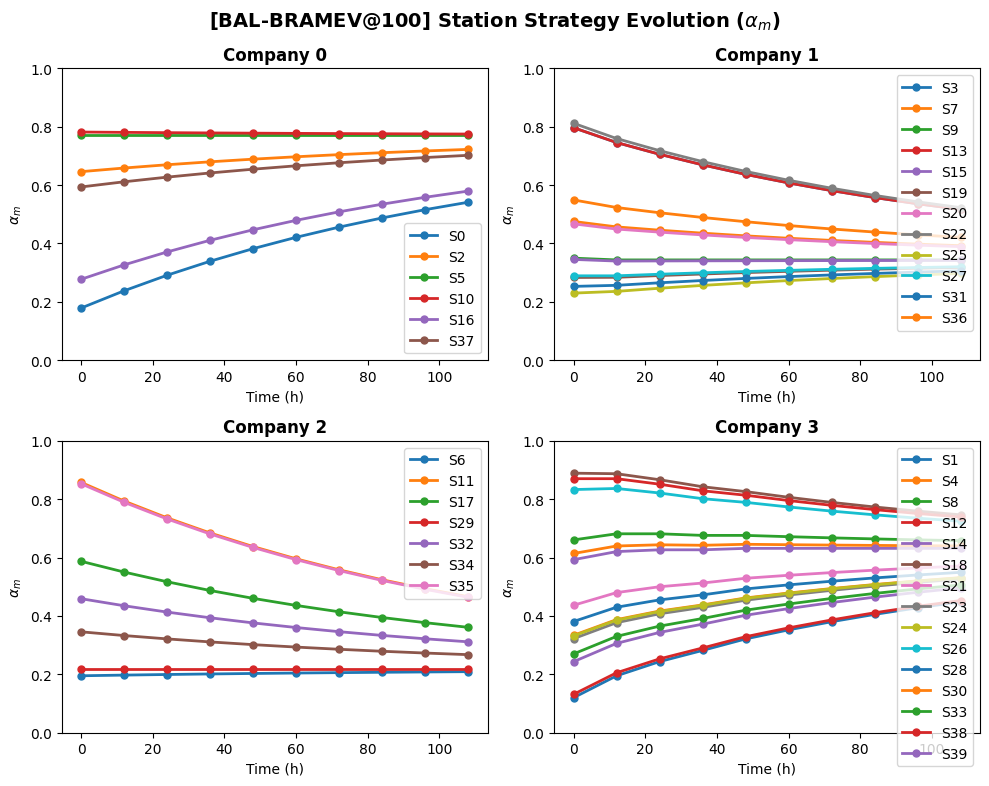

In [89]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [90]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.078472  0.026389  0.000000  0.000000  0.000000   
1            0           2  0.151389  0.127083  0.036111  0.000000       NaN   
2            0           5  0.367361  0.360417  0.045833  0.000000  0.000000   
3            0          10  0.210417  0.096528  0.000000  0.000000  0.000000   
4            0          16  0.236111  0.000000  0.000000  0.000000  0.000000   
5            0          37  0.065972  0.000000  0.000000  0.000000  0.000000   
6            1           3  0.134722  0.000000  0.000000  0.000000  0.000000   
7            1           7  0.086111  0.000000  0.000000  0.000000  0.000000   
8            1           9  0.474306  0.548611  0.309722  0.122917  0.154861   
9            1          13  0.073611  0.000000  0.000000  0.000000       NaN   
10           1          15  0.017361  0.015278  0.000000  0.000000       NaN   
11           1          19  0.306250  0.

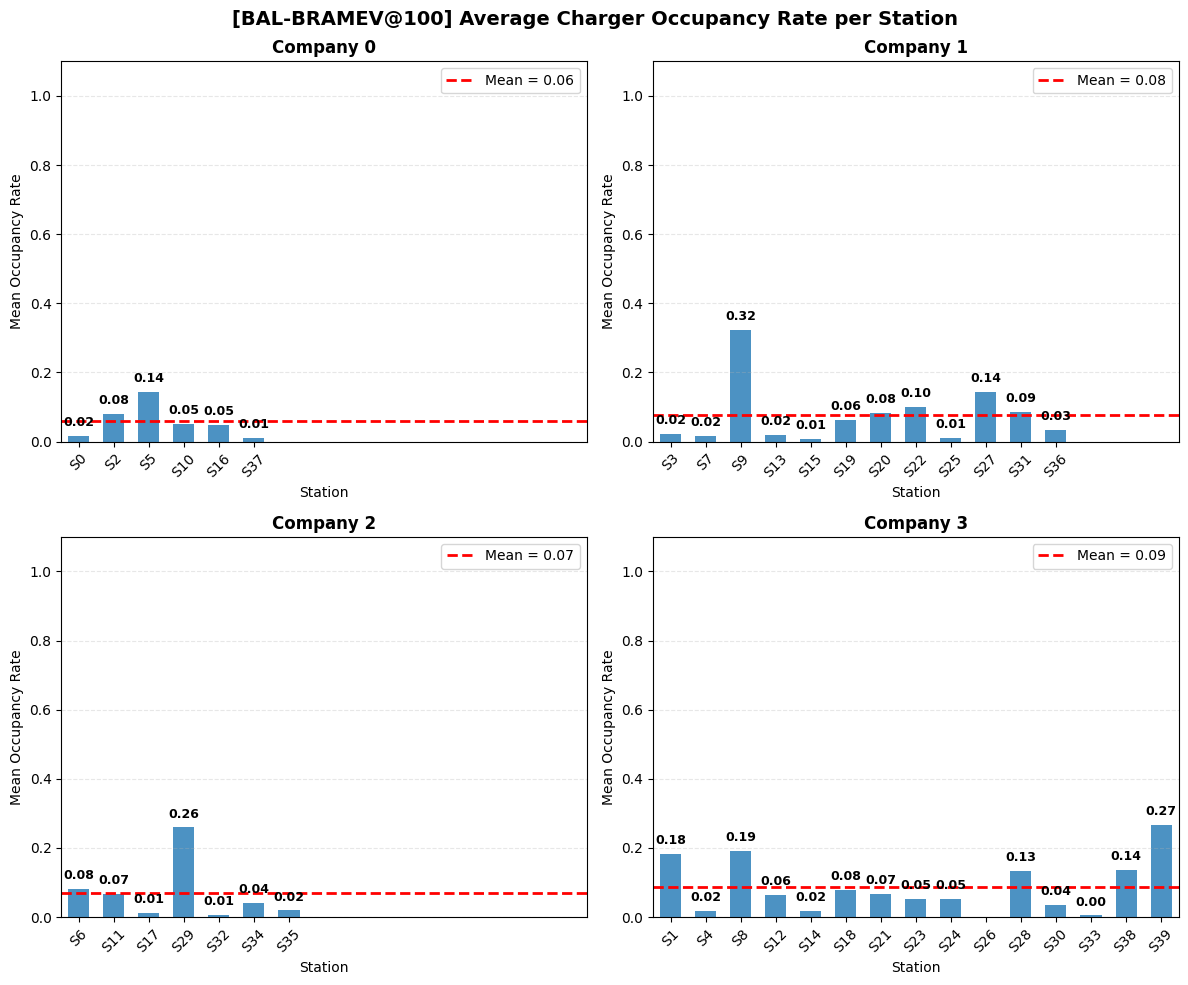

In [91]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

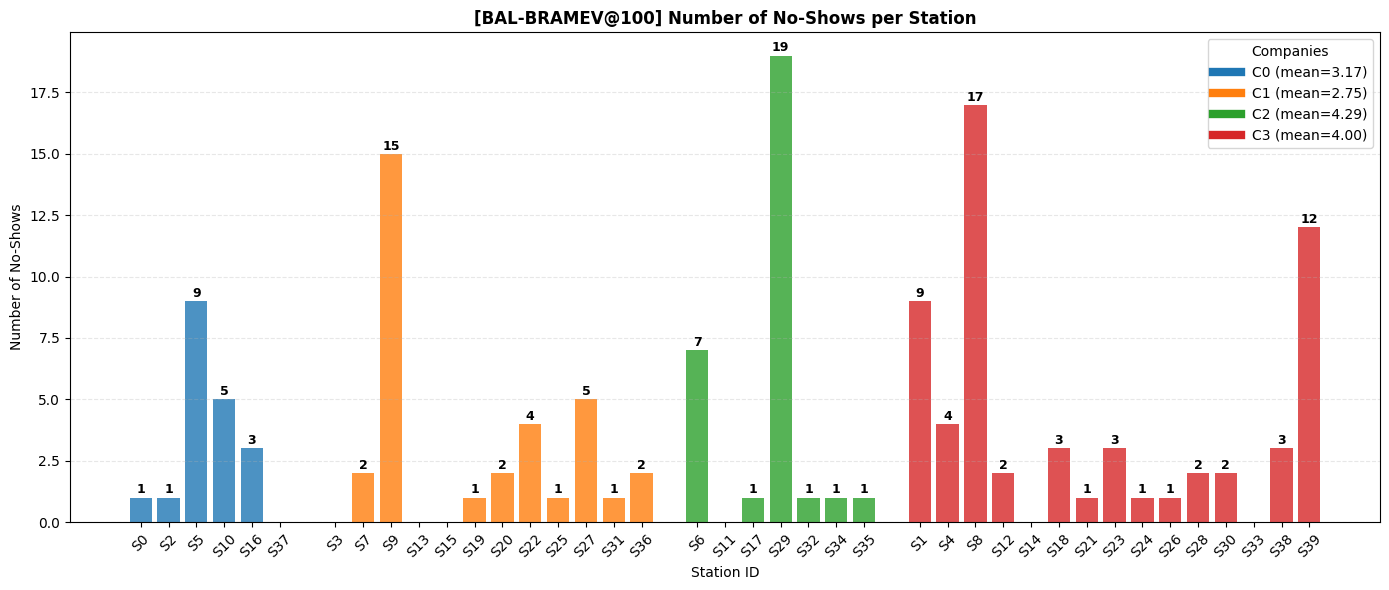

In [92]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [93]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,4,3,1,0,0,0.750000,0.250000,0.0,0.0
1,0,2,12,11,1,0,0,0.916667,0.083333,0.0,0.0
2,0,5,41,31,9,0,0,0.756098,0.219512,0.0,0.0
3,0,10,17,12,5,0,0,0.705882,0.294118,0.0,0.0
4,0,16,13,9,3,0,0,0.692308,0.230769,0.0,0.0
5,0,37,2,2,0,0,0,1.000000,0.000000,0.0,0.0
6,1,3,4,4,0,0,0,1.000000,0.000000,0.0,0.0
7,1,7,6,4,2,0,0,0.666667,0.333333,0.0,0.0
8,1,9,75,56,15,0,0,0.746667,0.200000,0.0,0.0
9,1,13,3,3,0,0,0,1.000000,0.000000,0.0,0.0


NUMBER OF REJECTED REQUESTS

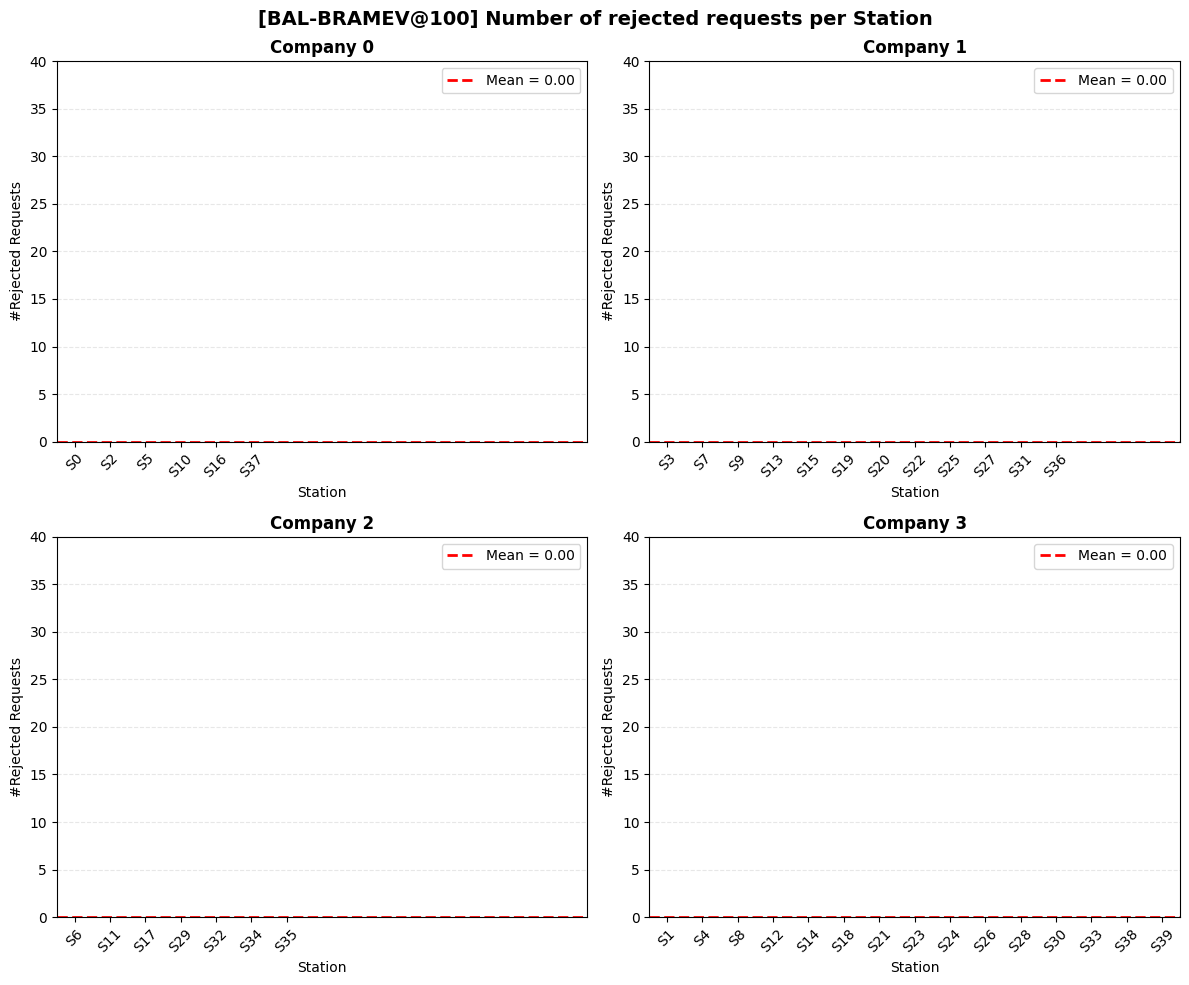

In [94]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

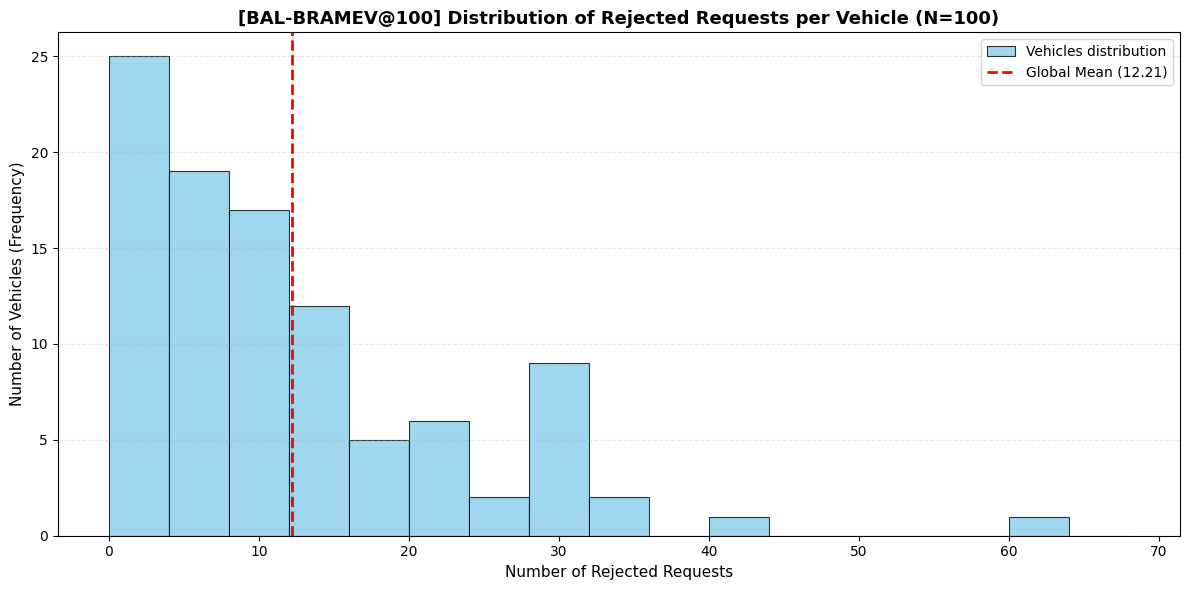

In [95]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

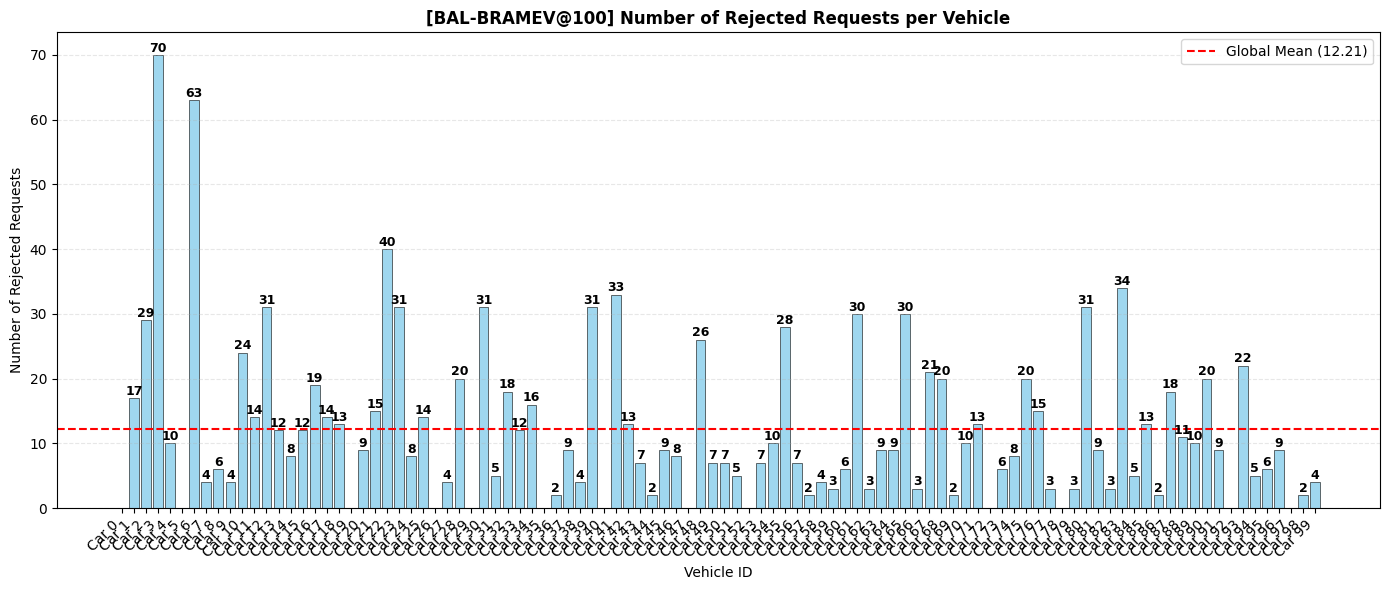

In [96]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

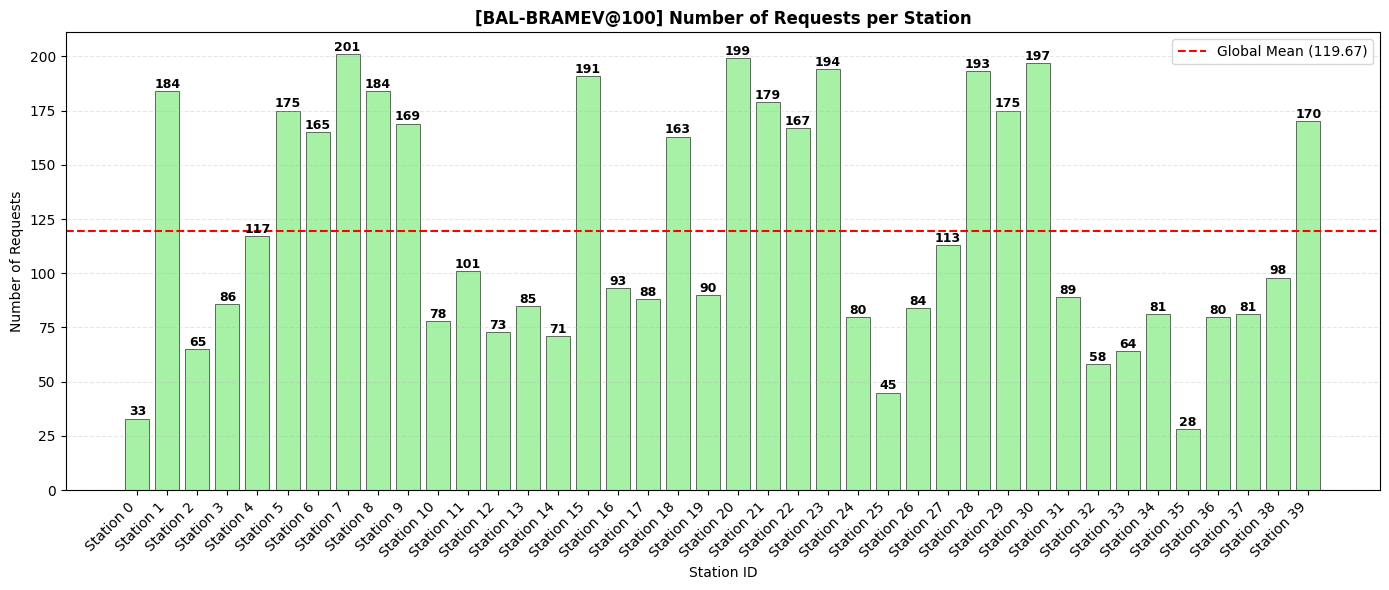

In [97]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [98]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

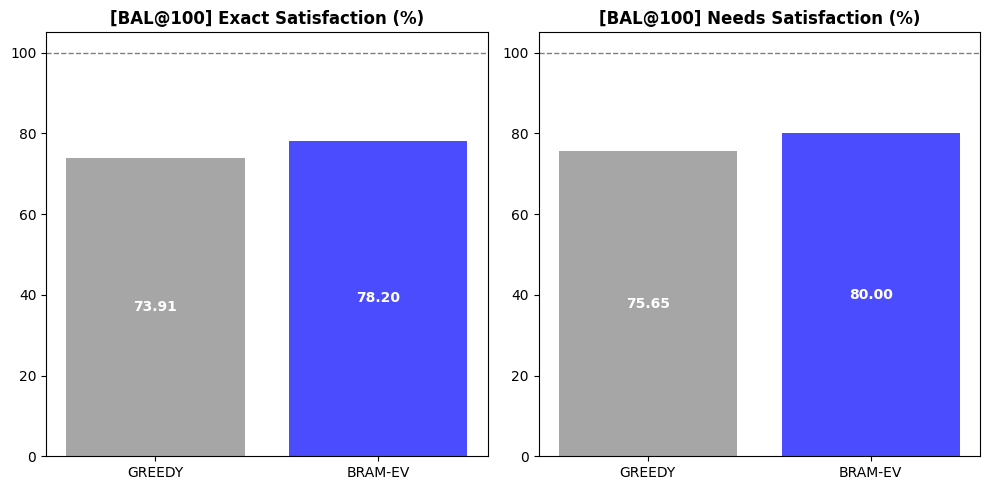

In [99]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

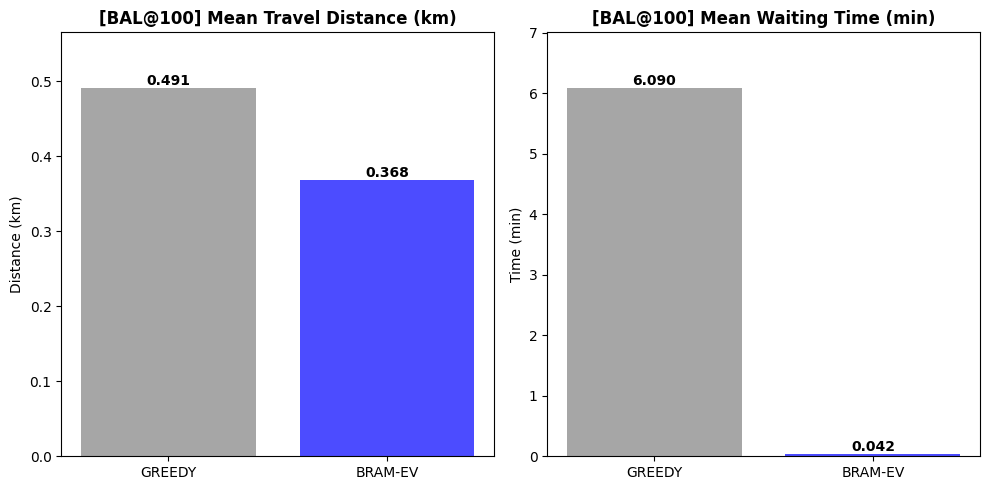

In [100]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

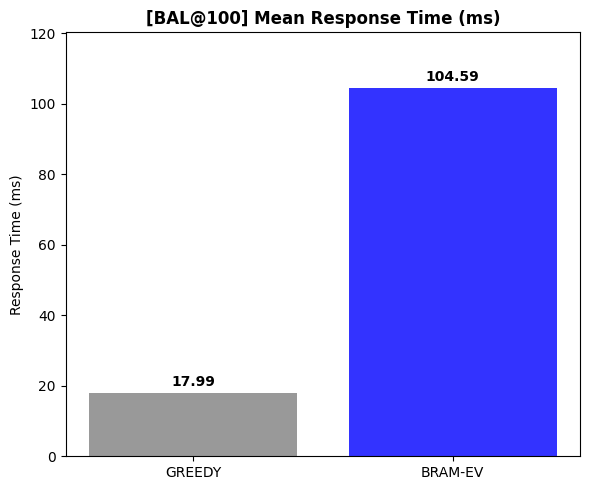

In [101]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [102]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [103]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [104]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [105]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:13:14.214 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:13:14.347 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:13:14.664 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:13:15.096 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:13:15.413 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:13:15.668 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:13:16.037 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:13:16.309 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:13:16.599 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:13:16.829 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:13:17.120 | IN

##### *Metrics*

In [106]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 3.62 kWh
  Station 1: 64.32 kWh
  Station 2: 1.81 kWh
  Station 3: 10.75 kWh
  Station 4: 57.83 kWh
  Station 5: 172.72 kWh
  Station 6: 1.07 kWh
  Station 7: 216.98 kWh
  Station 8: 86.68 kWh
  Station 9: 20.02 kWh
  Station 10: 52.01 kWh
  Station 11: 13.89 kWh
  Station 12: 32.43 kWh
  Station 13: 158.49 kWh
  Station 14: 25.56 kWh
  Station 15: 7.40 kWh
  Station 16: 46.32 kWh
  Station 17: 15.98 kWh
  Station 18: 20.25 kWh
  Station 19: 52.58 kWh
  Station 20: 15.89 kWh
  Station 21: 22.77 kWh
  Station 22: 63.94 kWh
  Station 23: 4.28 kWh
  Station 24: 10.12 kWh
  Station 25: 19.38 kWh
  Station 26: 44.46 kWh
  Station 27: 48.17 kWh
  Station 28: 28.73 kWh
  Station 29: 41.41 kWh
  Station 30: 151.37 kWh
  Station 31: 10.15 kWh
  Station 32: 23.23 kWh
  Station 33: 20.73 kWh
  Station 34: 4.92 kWh
  Station 35: 11.72 kWh
  Station 36: 26.42 kWh
  Station 37: 33.96 kWh
  Station 38: 2.00 kWh
  Station 39: 

In [107]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

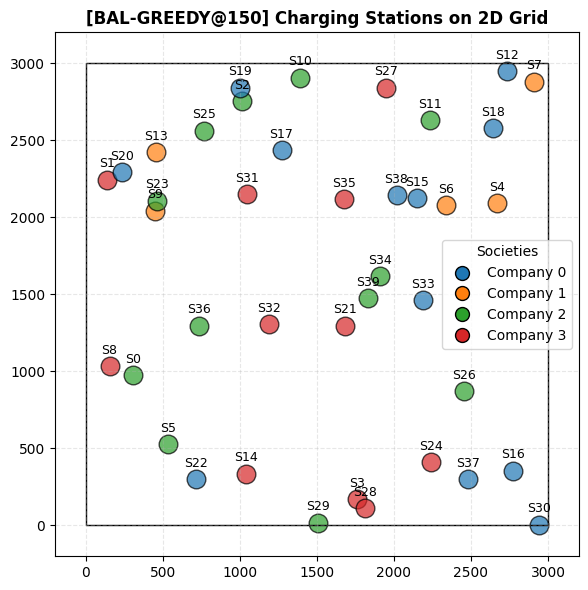

In [108]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

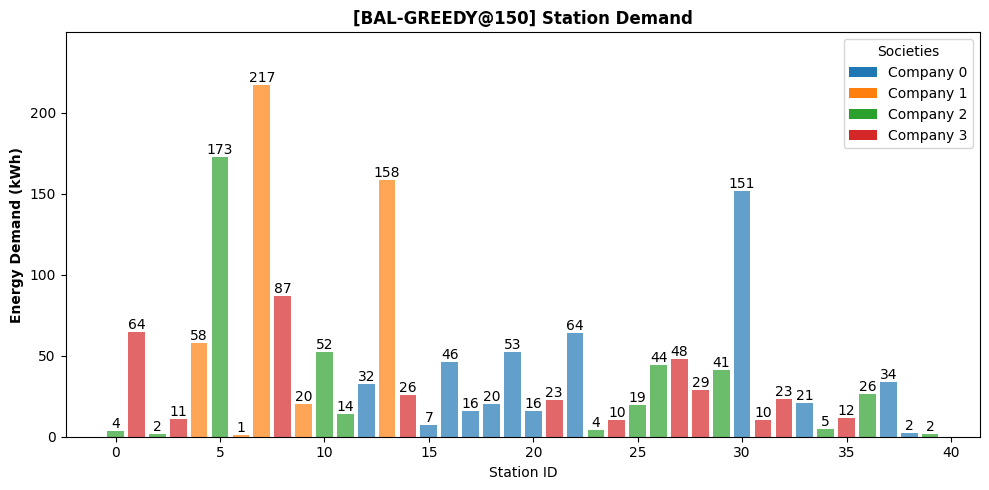

In [109]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

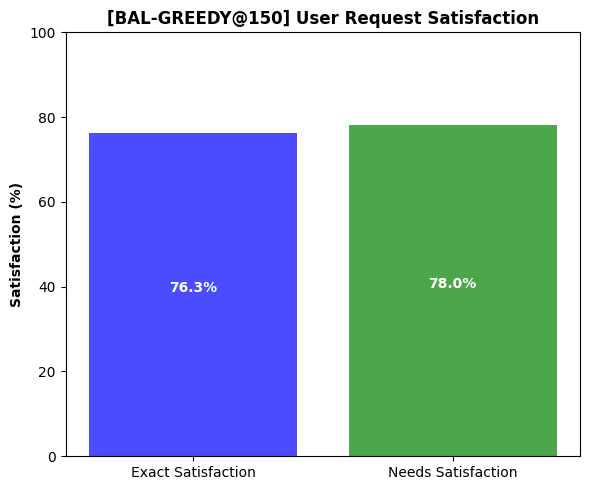

In [110]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

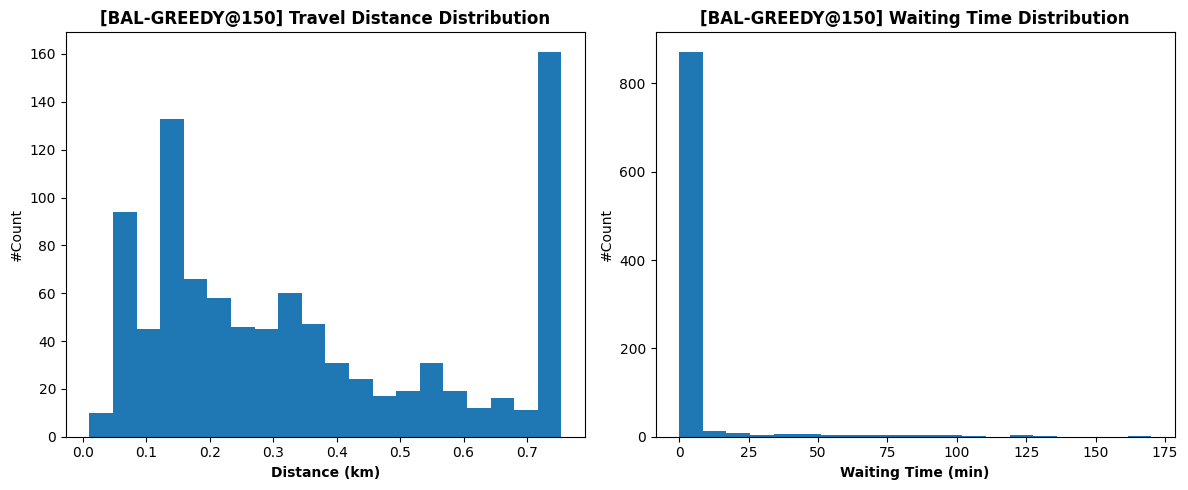

In [111]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

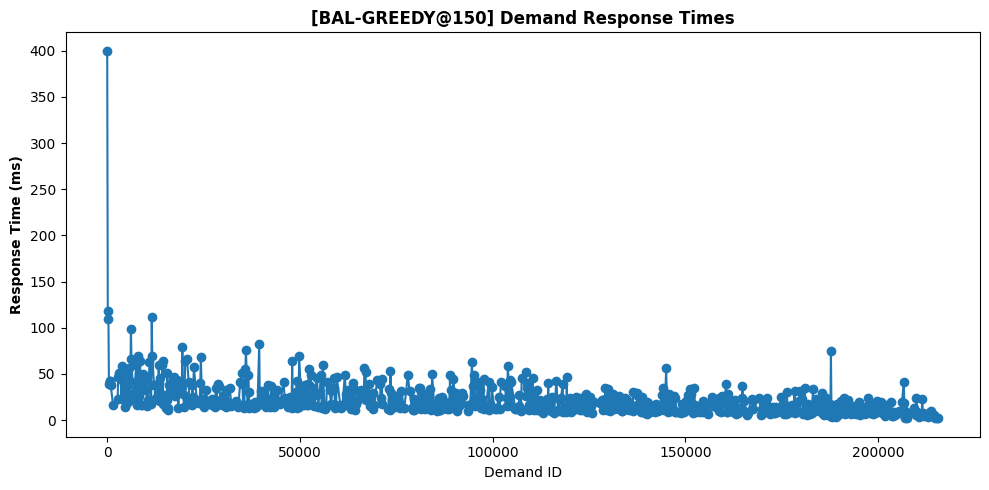

In [112]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

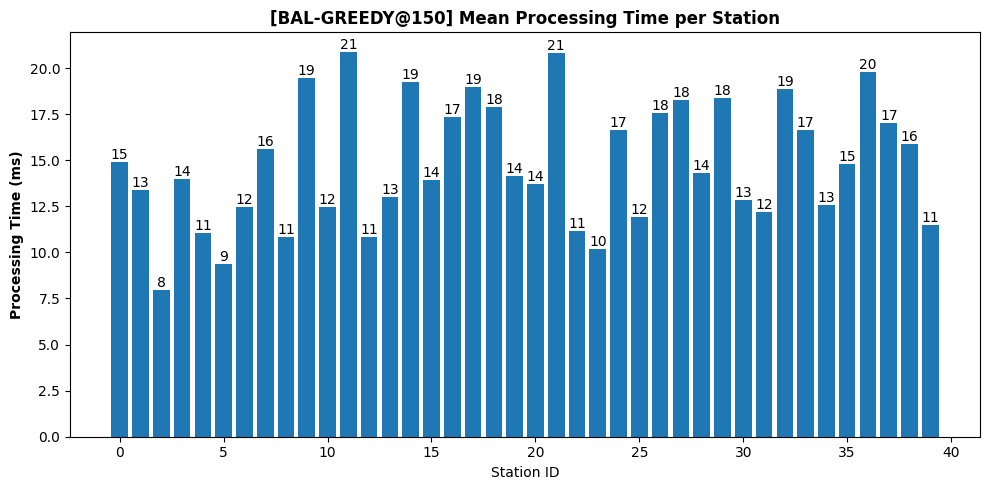

In [113]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [114]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0          12  0.289583  0.110417  0.000000  0.067361       NaN   
1            0          15  0.074306  0.036806  0.000000  0.000000       NaN   
2            0          16  0.404167  0.105556  0.032639  0.049306  0.015972   
3            0          17  0.194444  0.029861  0.000000  0.000000  0.000000   
4            0          18  0.222222  0.065972  0.000000  0.000000  0.000000   
5            0          19  0.309722  0.308333  0.084722  0.000000  0.046528   
6            0          20  0.124306  0.070833  0.000000  0.000000  0.017361   
7            0          22  0.413194  0.290278  0.054861  0.179861       NaN   
8            0          30  0.507639  0.575000  0.180556  0.361111  0.457639   
9            0          33  0.208333  0.098611  0.000000  0.000000  0.000000   
10           0          37  0.383333  0.091667  0.000000  0.000000  0.000000   
11           0          38  0.033333  0.

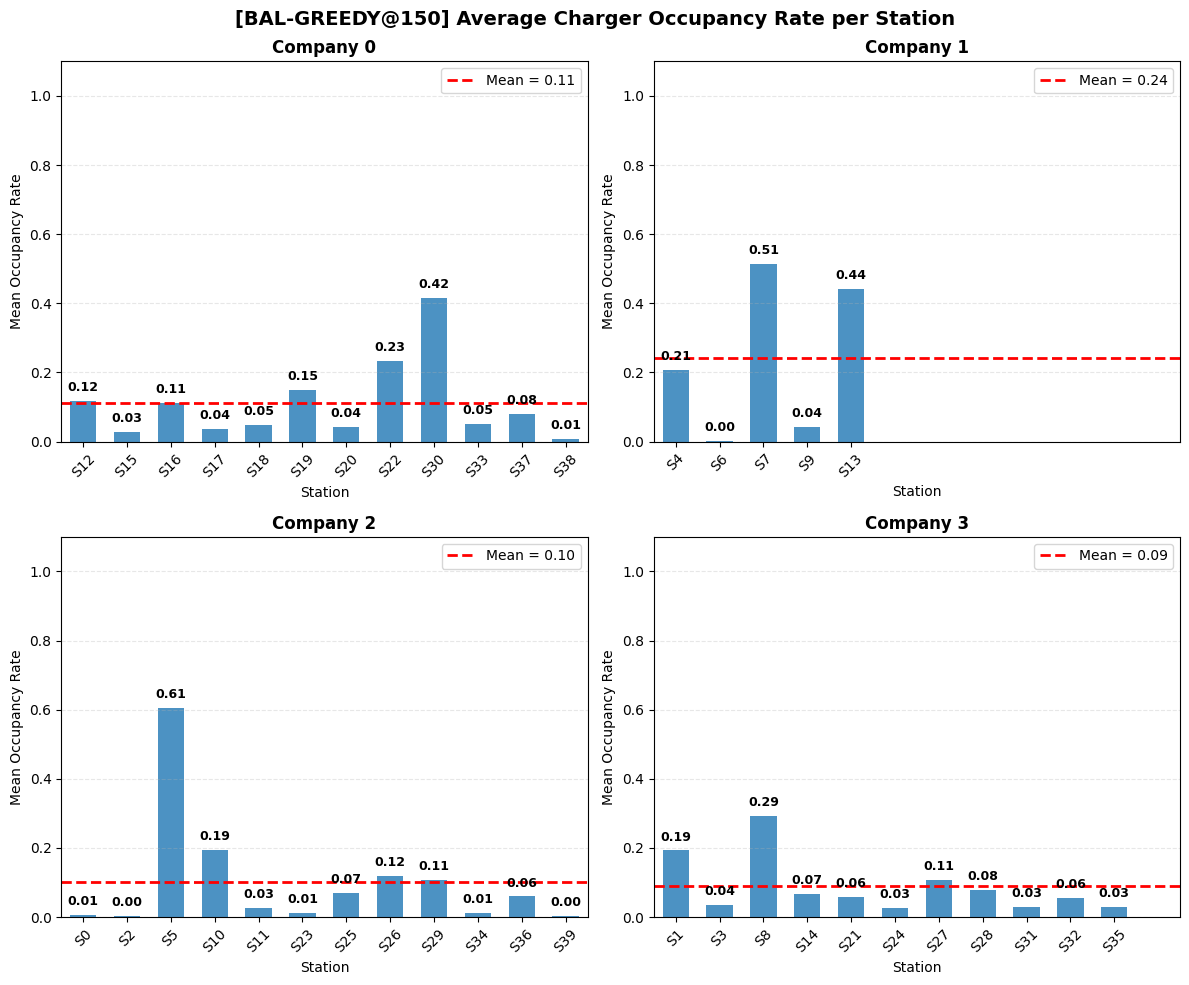

In [115]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

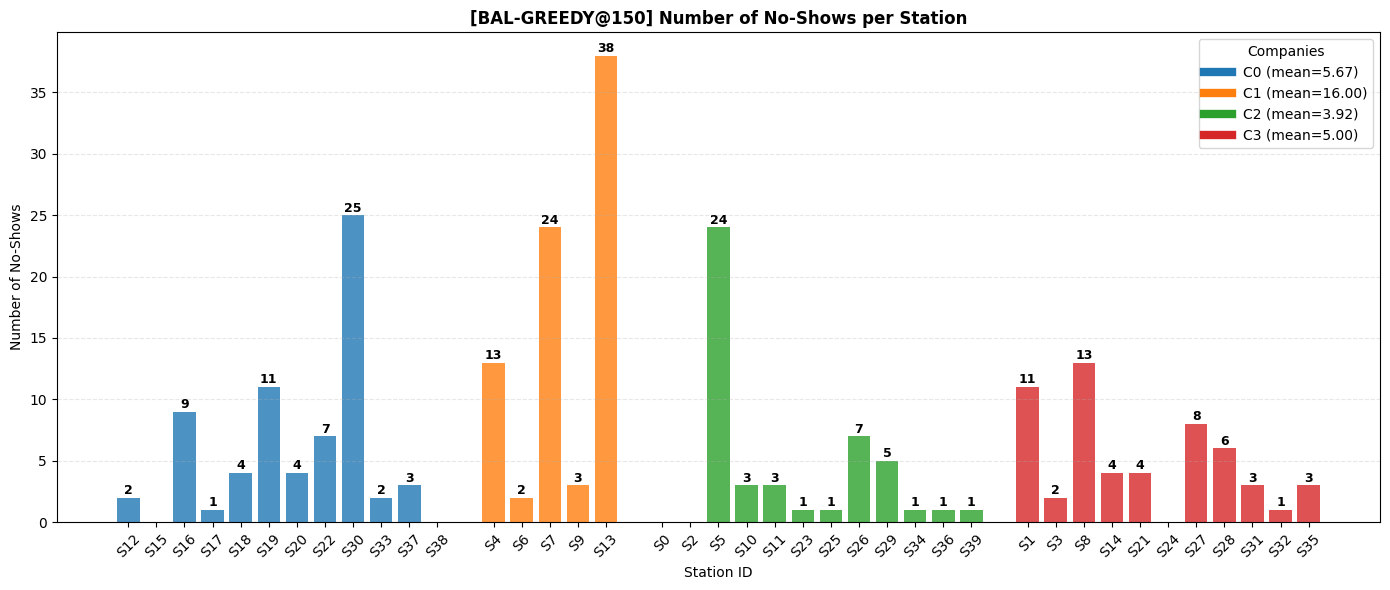

In [116]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [117]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,12,22,20,2,0,0,0.909091,0.090909,0.0,0.0
1,0,15,4,4,0,0,0,1.000000,0.000000,0.0,0.0
2,0,16,35,26,9,0,0,0.742857,0.257143,0.0,0.0
3,0,17,10,9,1,0,0,0.900000,0.100000,0.0,0.0
4,0,18,15,11,4,0,0,0.733333,0.266667,0.0,0.0
5,0,19,42,30,11,0,0,0.714286,0.261905,0.0,0.0
6,0,20,13,9,4,0,0,0.692308,0.307692,0.0,0.0
7,0,22,44,37,7,0,0,0.840909,0.159091,0.0,0.0
8,0,30,116,89,25,0,0,0.767241,0.215517,0.0,0.0
9,0,33,14,12,2,0,0,0.857143,0.142857,0.0,0.0


NUMBER OF REJECTED REQUESTS

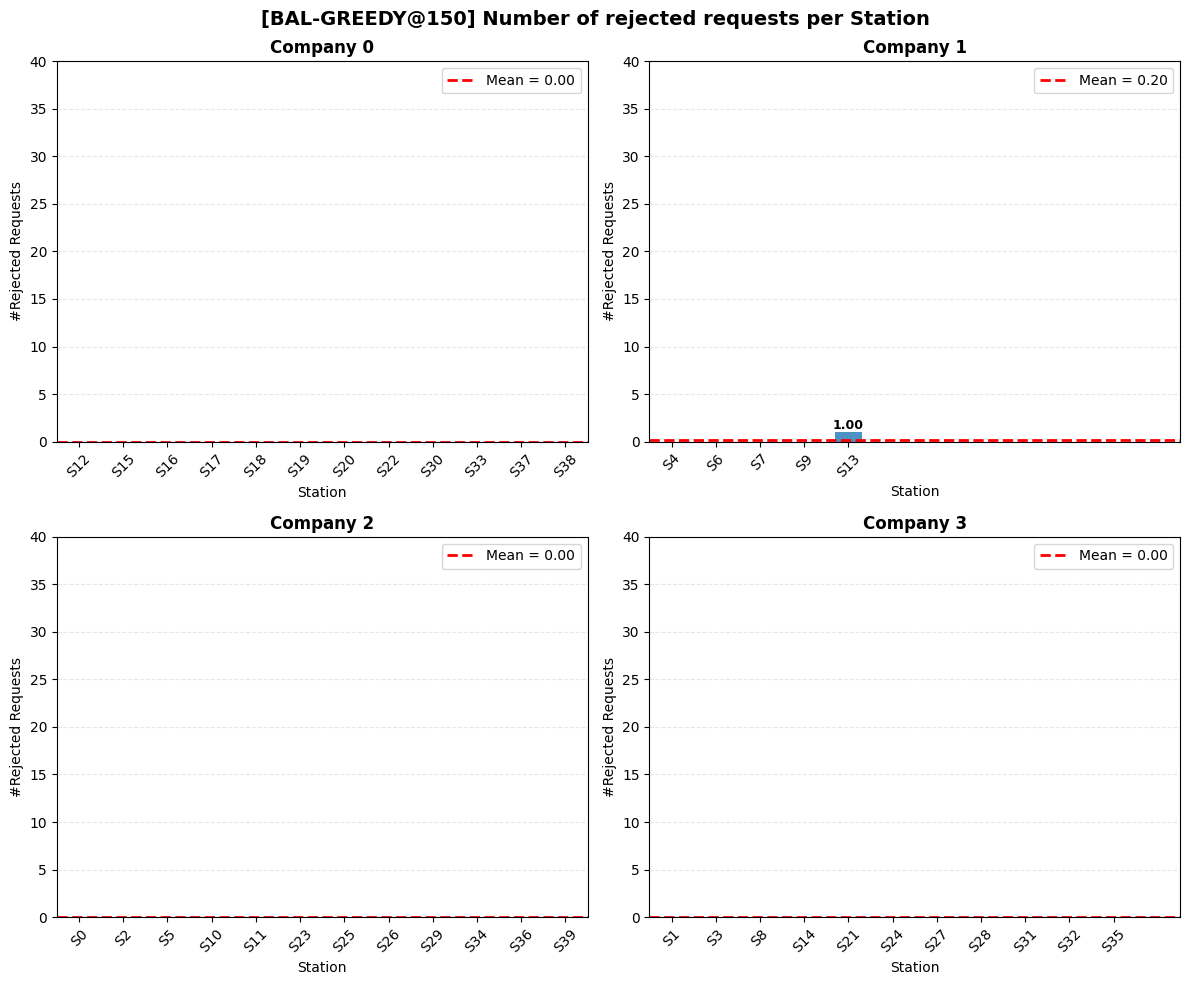

In [118]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [119]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [120]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [121]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:13:39.726 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:13:40.515 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:13:41.319 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:13:43.464 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:13:44.573 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:13:46.512 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:13:48.363 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:13:49.524 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:13:50.897 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:13:51.758 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:13:53.566 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [122]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 137.68 kWh
  Station 1: 124.22 kWh
  Station 2: 5.80 kWh
  Station 3: 11.35 kWh
  Station 4: 60.23 kWh
  Station 5: 5.56 kWh
  Station 6: 14.33 kWh
  Station 7: 1.75 kWh
  Station 8: 9.95 kWh
  Station 9: 84.19 kWh
  Station 10: 15.13 kWh
  Station 11: 55.04 kWh
  Station 12: 172.52 kWh
  Station 13: 4.12 kWh
  Station 14: 3.61 kWh
  Station 15: 46.32 kWh
  Station 16: 70.80 kWh
  Station 17: 20.27 kWh
  Station 18: 67.83 kWh
  Station 19: 10.47 kWh
  Station 20: 2.80 kWh
  Station 21: 74.47 kWh
  Station 22: 11.63 kWh
  Station 23: 22.88 kWh
  Station 24: 2.51 kWh
  Station 25: 6.87 kWh
  Station 26: 157.15 kWh
  Station 27: 152.21 kWh
  Station 28: 9.01 kWh
  Station 29: 37.55 kWh
  Station 30: 3.62 kWh
  Station 31: 34.72 kWh
  Station 32: 17.07 kWh
  Station 33: 32.65 kWh
  Station 34: 65.23 kWh
  Station 35: 2.15 kWh
  Station 36: 46.65 kWh
  Station 37: 25.75 kWh
  Station 38: 9.60 kWh
  Station 39: 17.97

In [123]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

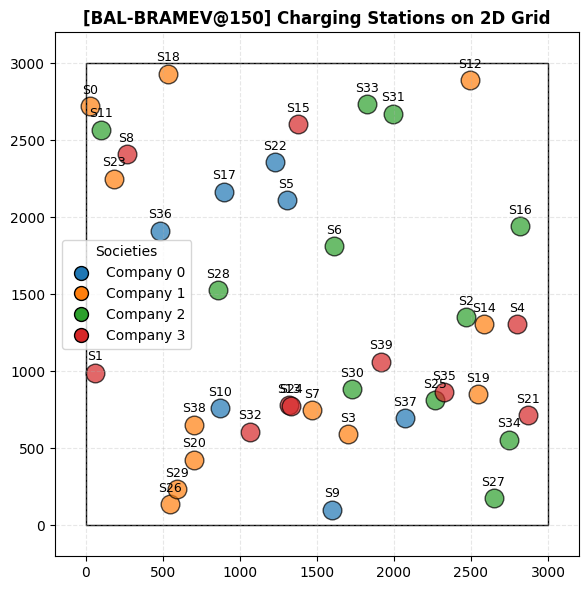

In [124]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

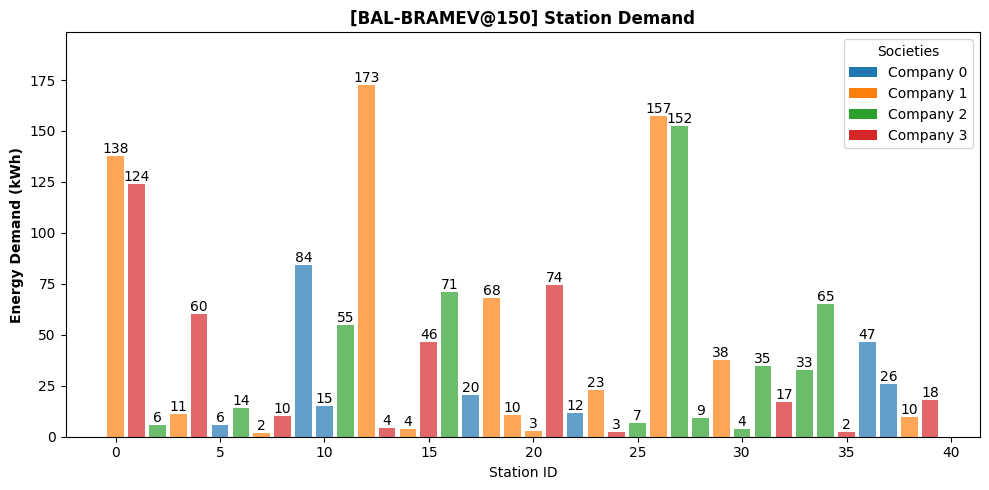

In [125]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

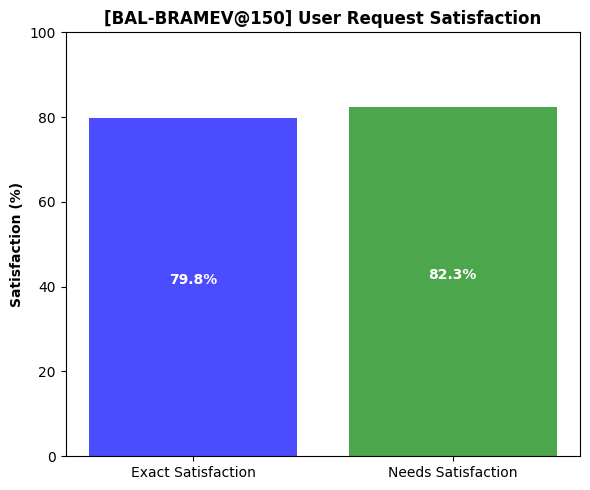

In [126]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

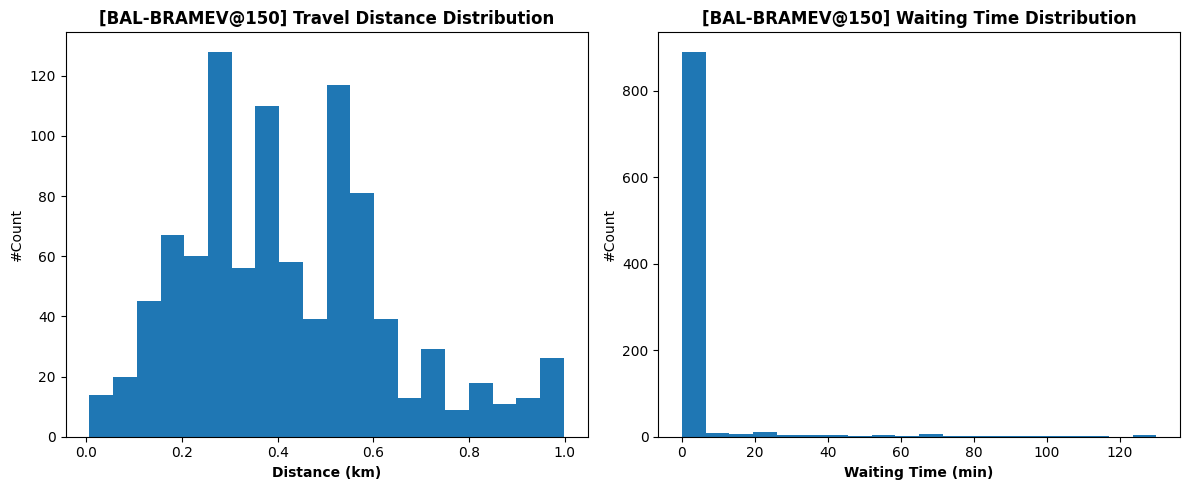

In [127]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

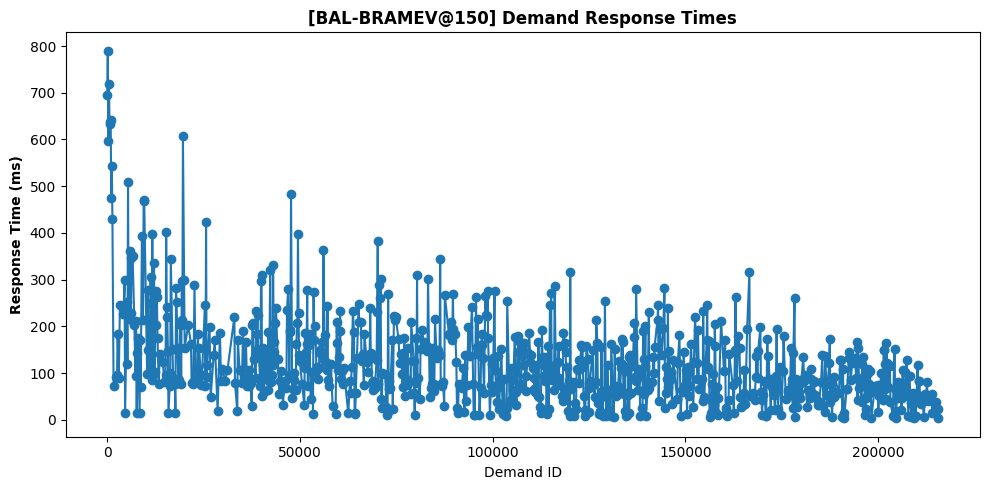

In [128]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

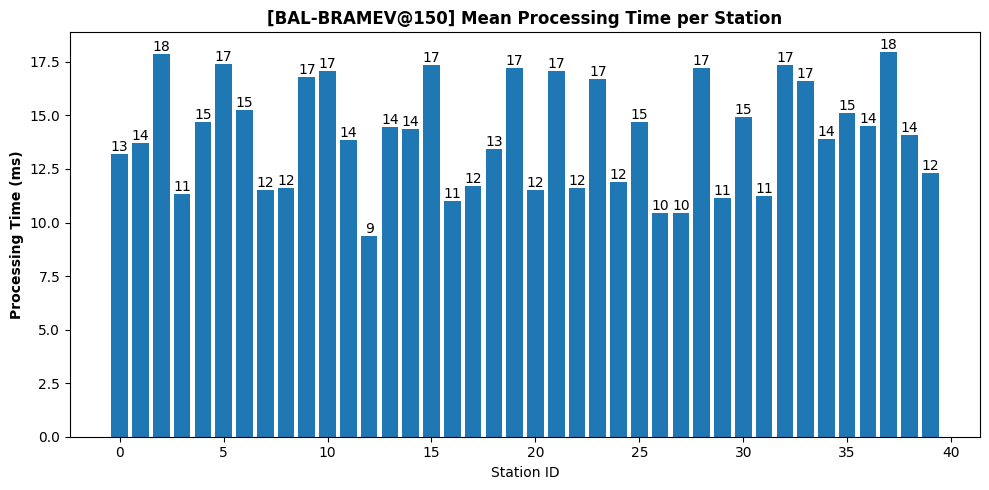

In [129]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

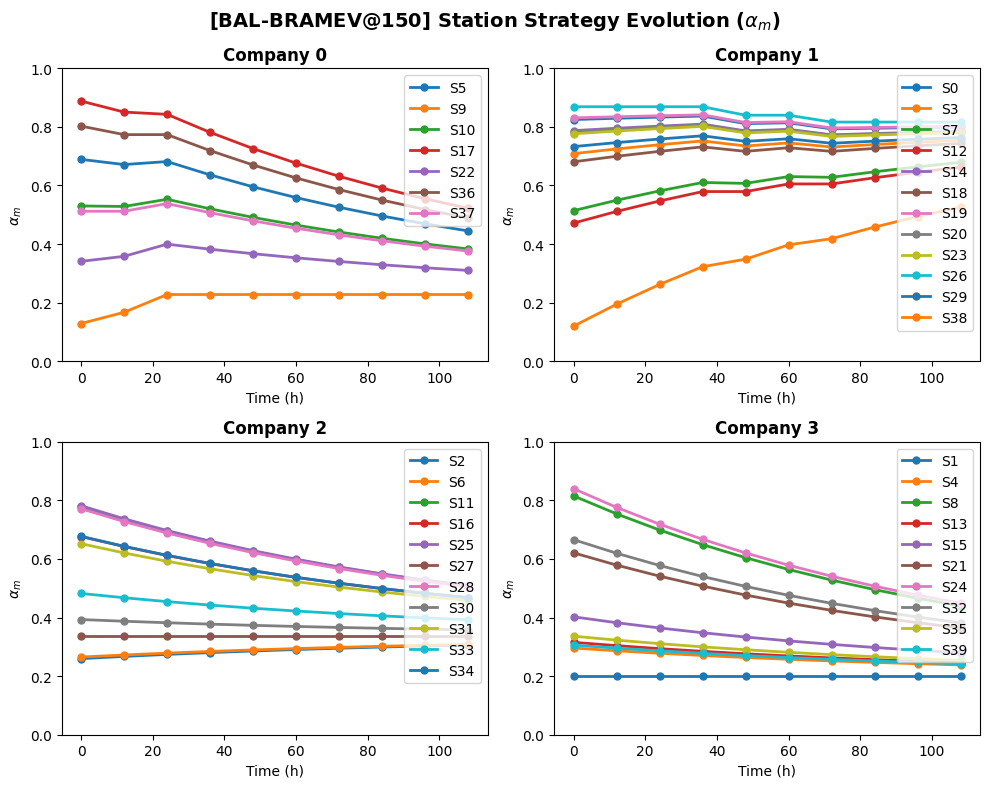

In [130]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [131]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.090278  0.000000  0.000000  0.000000  0.000000   
1            0           9  0.446528  0.300694  0.143056  0.044444  0.113194   
2            0          10  0.193056  0.034028  0.000000  0.000000  0.000000   
3            0          17  0.283333  0.019444  0.000000  0.041667       NaN   
4            0          22  0.092361  0.043056  0.000000  0.000000       NaN   
5            0          36  0.391667  0.172222  0.000000  0.000000  0.036111   
6            0          37  0.264583  0.090278  0.000000  0.000000  0.000000   
7            1           0  0.591667  0.582639  0.252778  0.193056  0.451389   
8            1           3  0.131250  0.047917  0.000000  0.000000       NaN   
9            1           7  0.024306  0.000000  0.000000  0.000000       NaN   
10           1          12  0.602778  0.696528  0.560417  0.461806       NaN   
11           1          14  0.050000  0.

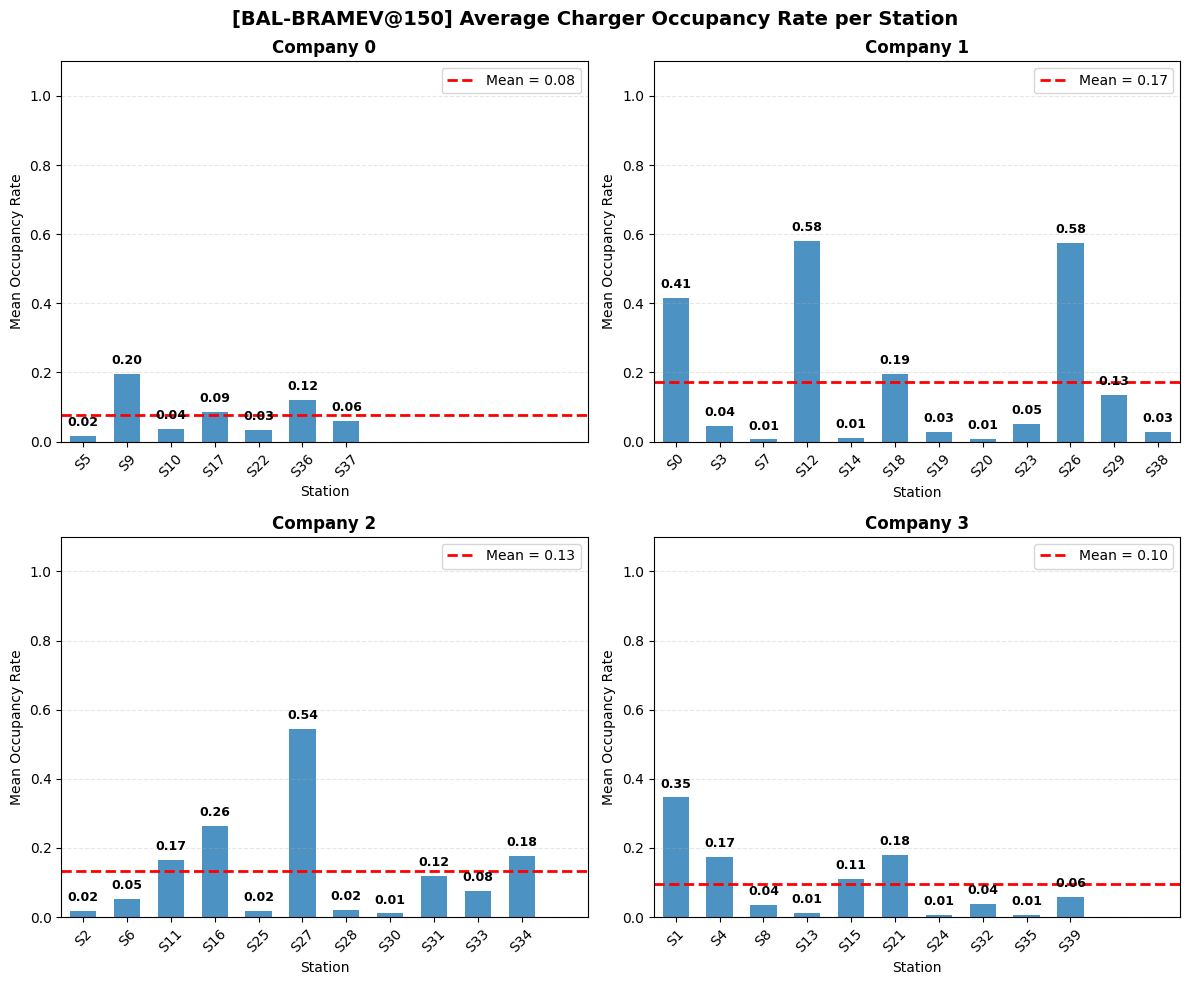

In [132]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

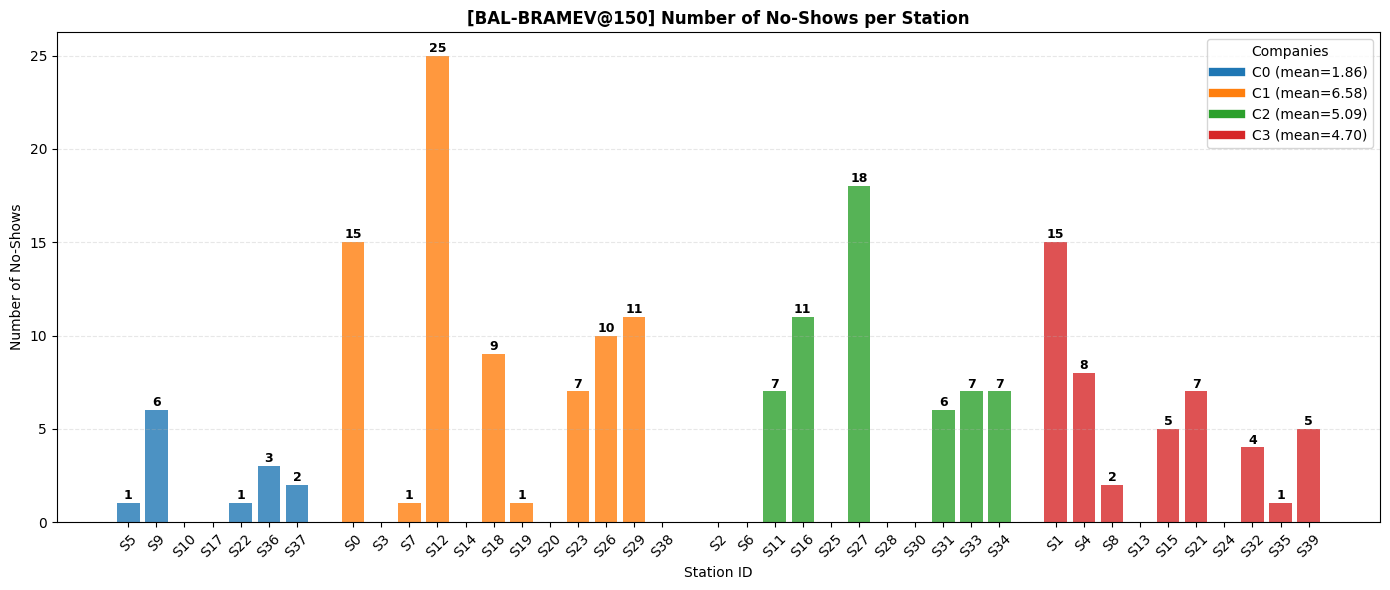

In [133]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [134]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,4,3,1,0,0,0.750000,0.250000,0.000000,0.0
1,0,9,54,48,6,0,0,0.888889,0.111111,0.000000,0.0
2,0,10,9,9,0,0,0,1.000000,0.000000,0.000000,0.0
3,0,17,12,12,0,0,0,1.000000,0.000000,0.000000,0.0
4,0,22,6,5,1,0,0,0.833333,0.166667,0.000000,0.0
5,0,36,30,27,3,0,0,0.900000,0.100000,0.000000,0.0
6,0,37,17,15,2,0,0,0.882353,0.117647,0.000000,0.0
7,1,0,94,78,15,0,0,0.829787,0.159574,0.000000,0.0
8,1,3,7,7,0,0,0,1.000000,0.000000,0.000000,0.0
9,1,7,2,1,1,0,0,0.500000,0.500000,0.000000,0.0


NUMBER OF REJECTED REQUESTS

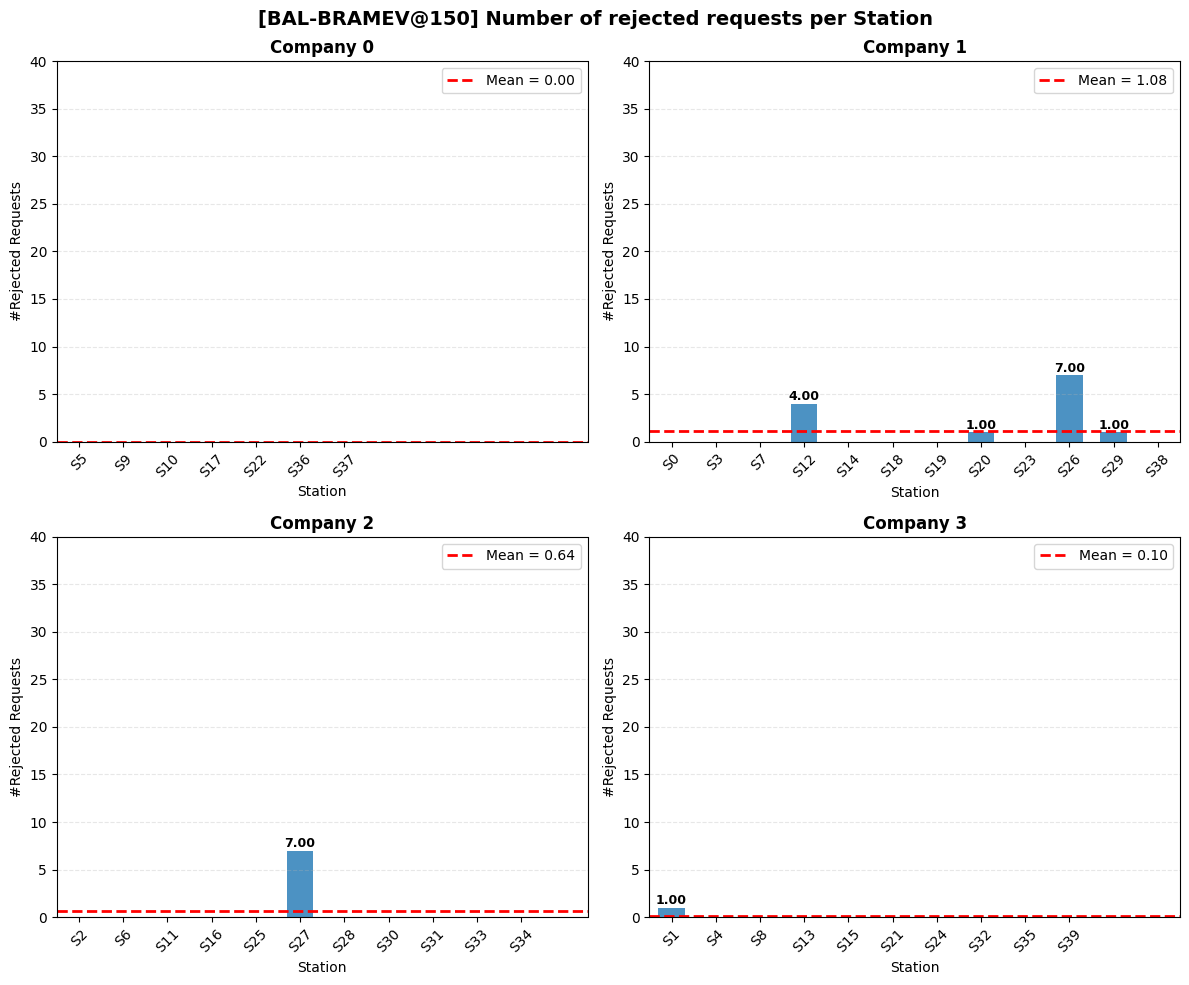

In [135]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

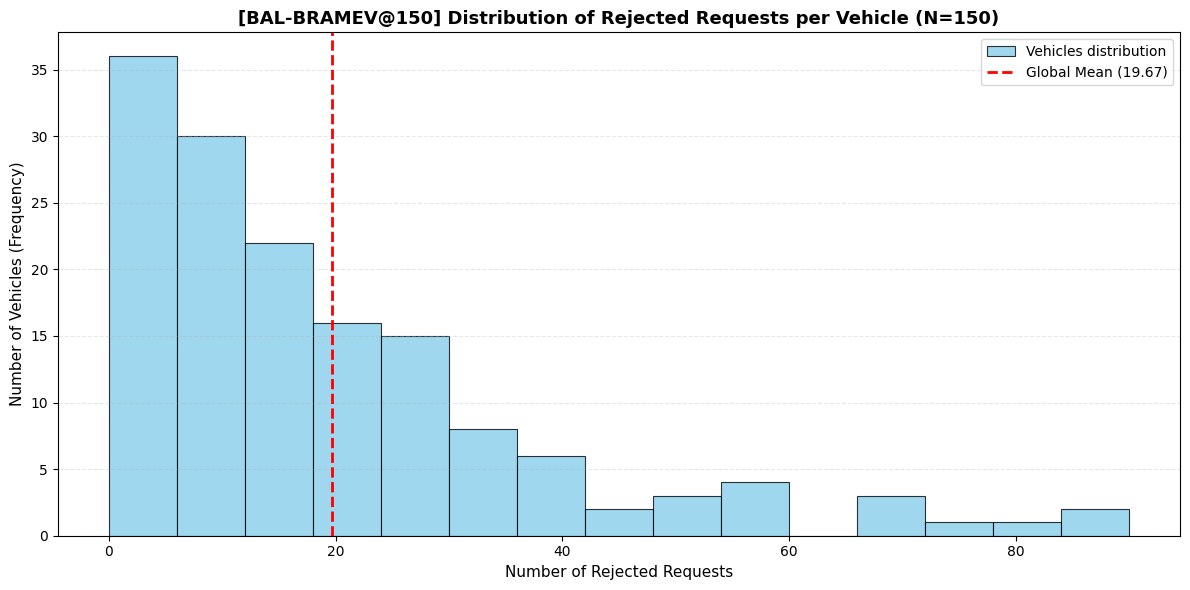

In [136]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

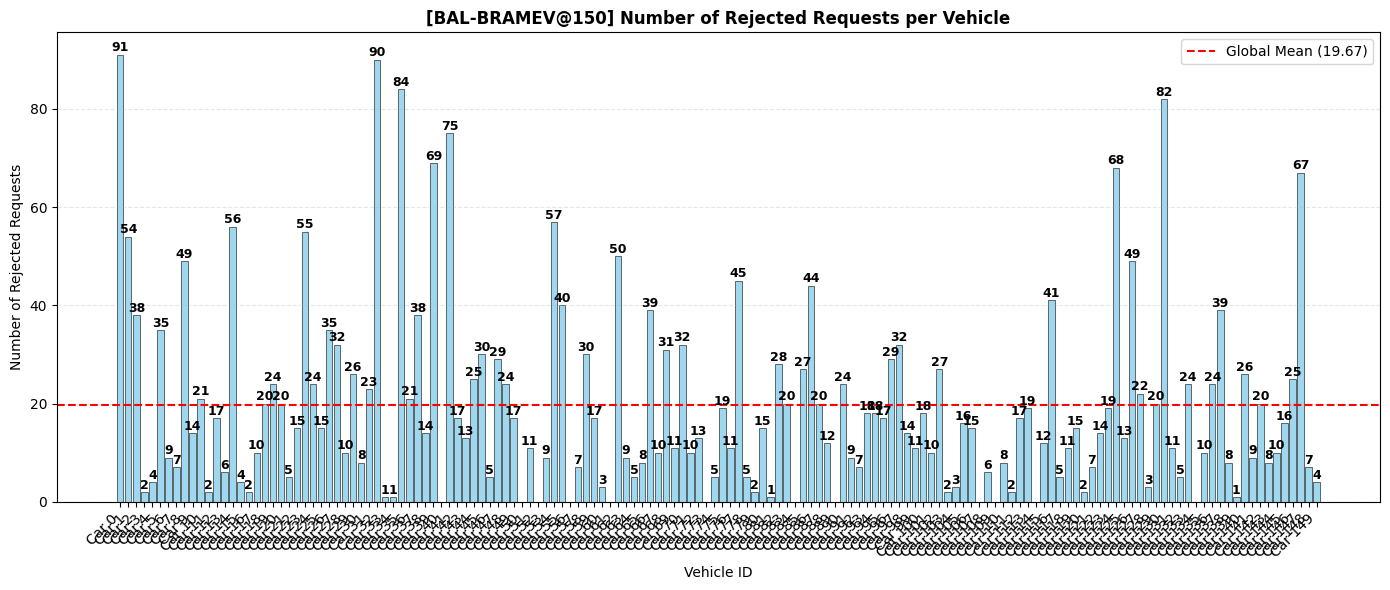

In [137]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

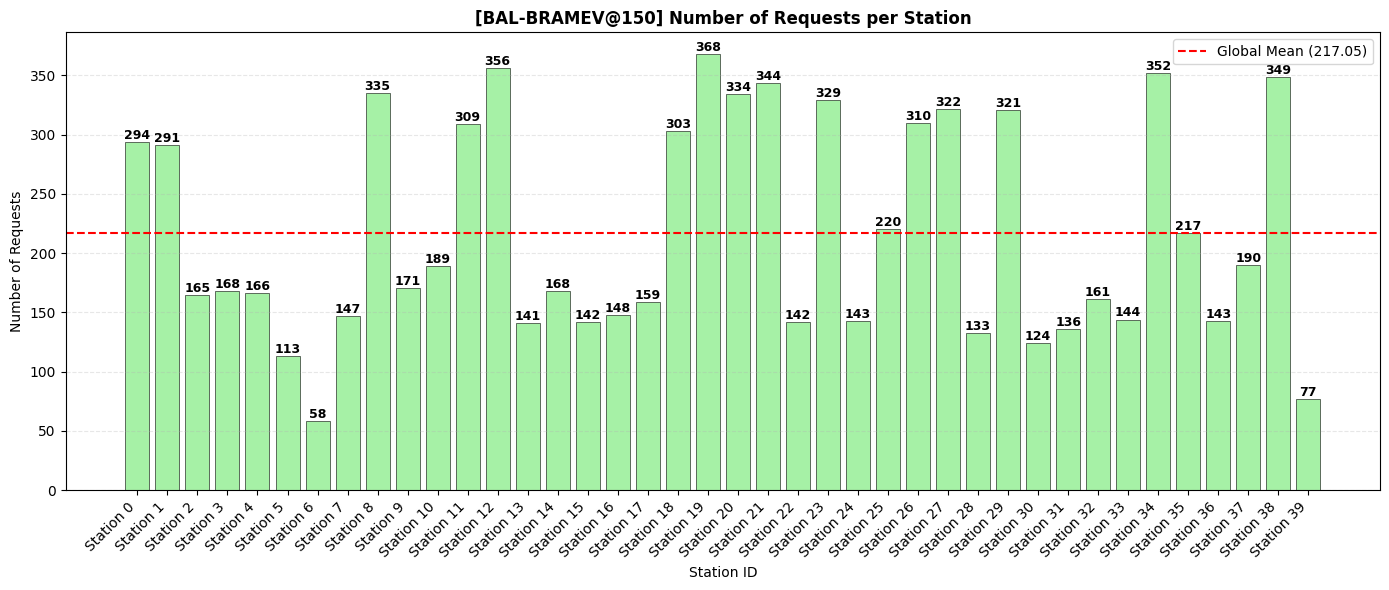

In [138]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [139]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

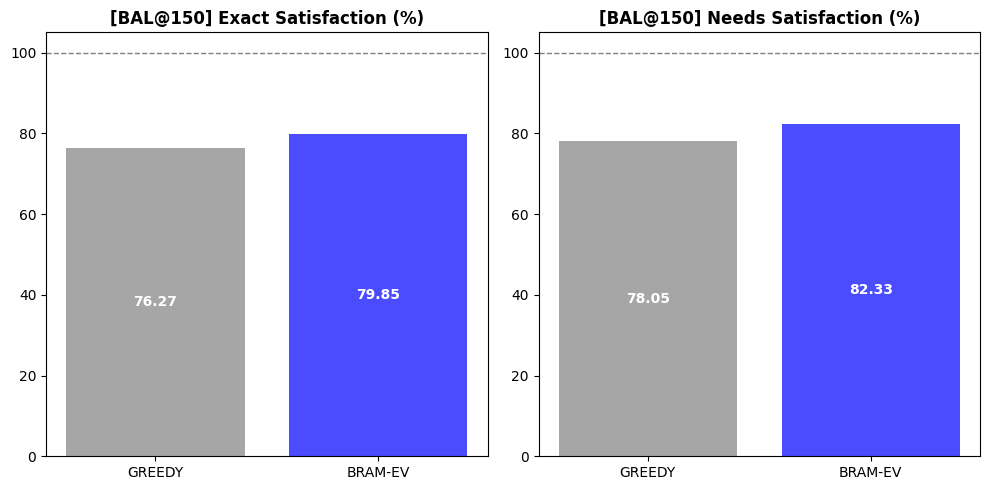

In [140]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

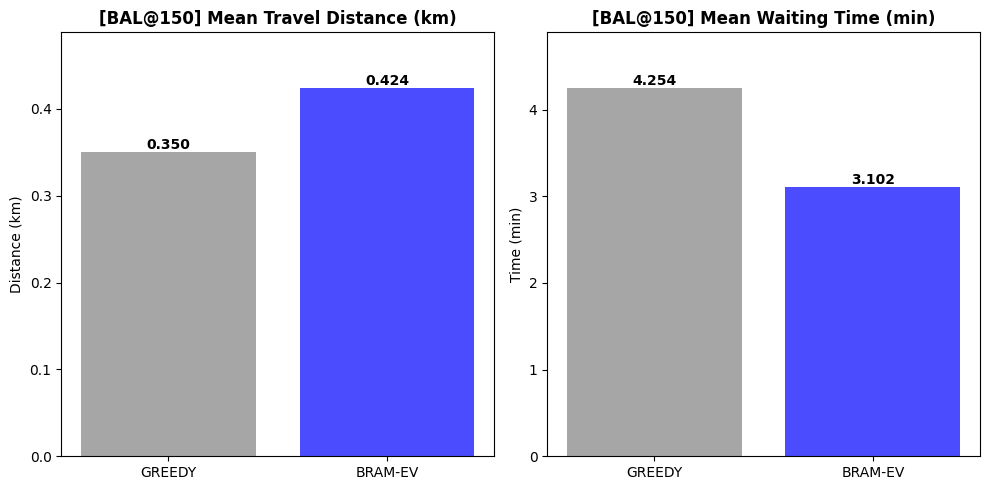

In [141]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

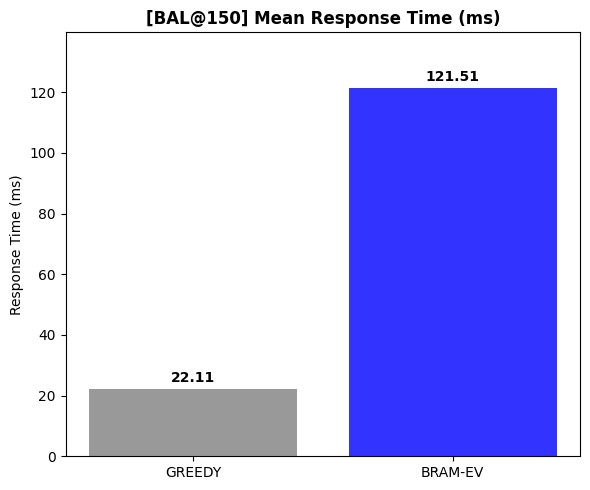

In [142]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [143]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [144]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [145]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [146]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:15:20.045 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:15:20.309 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:15:20.519 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:15:20.880 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:15:21.123 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:15:21.405 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:15:21.671 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:15:21.894 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:15:22.274 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:15:22.522 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:15:22.854 | IN

##### *Metrics*

In [147]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 3.07 kWh
  Station 1: 124.15 kWh
  Station 2: 204.04 kWh
  Station 3: 198.03 kWh
  Station 4: 18.82 kWh
  Station 5: 16.82 kWh
  Station 6: 5.87 kWh
  Station 7: 8.72 kWh
  Station 8: 12.53 kWh
  Station 9: 275.49 kWh
  Station 10: 49.29 kWh
  Station 11: 71.21 kWh
  Station 12: 16.68 kWh
  Station 13: 87.57 kWh
  Station 14: 88.74 kWh
  Station 15: 12.77 kWh
  Station 16: 7.08 kWh
  Station 17: 70.22 kWh
  Station 18: 8.29 kWh
  Station 19: 3.90 kWh
  Station 20: 57.44 kWh
  Station 21: 56.97 kWh
  Station 22: 2.23 kWh
  Station 23: 3.33 kWh
  Station 24: 9.94 kWh
  Station 25: 15.90 kWh
  Station 26: 47.88 kWh
  Station 27: 1.60 kWh
  Station 28: 68.17 kWh
  Station 29: 34.65 kWh
  Station 30: 208.10 kWh
  Station 31: 15.53 kWh
  Station 32: 11.28 kWh
  Station 33: 12.11 kWh
  Station 34: 65.35 kWh
  Station 35: 4.24 kWh
  Station 36: 56.52 kWh
  Station 37: 35.06 kWh
  Station 38: 10.80 kWh
  Station 39: 29.

In [148]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

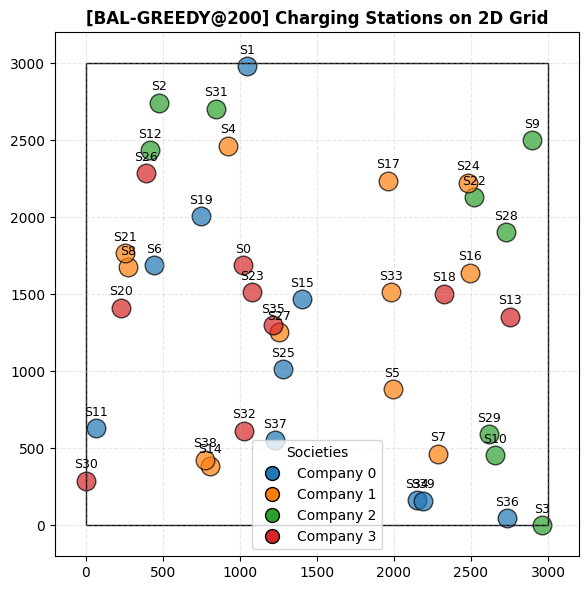

In [149]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

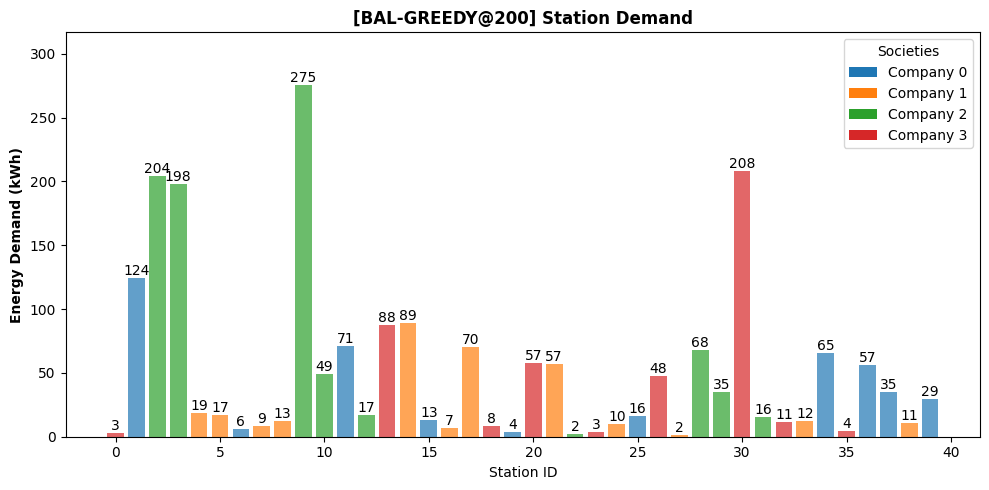

In [150]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

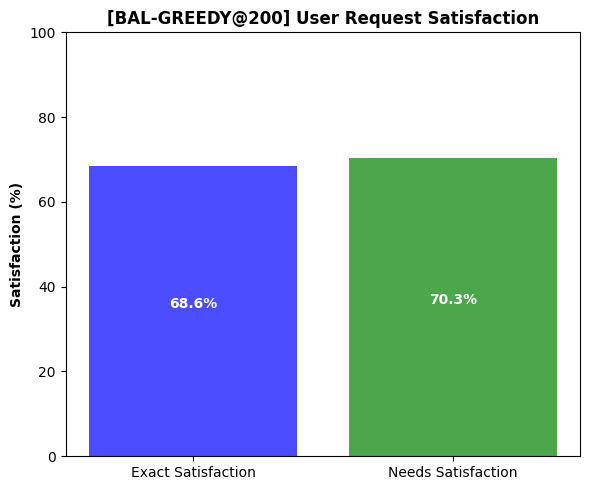

In [151]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

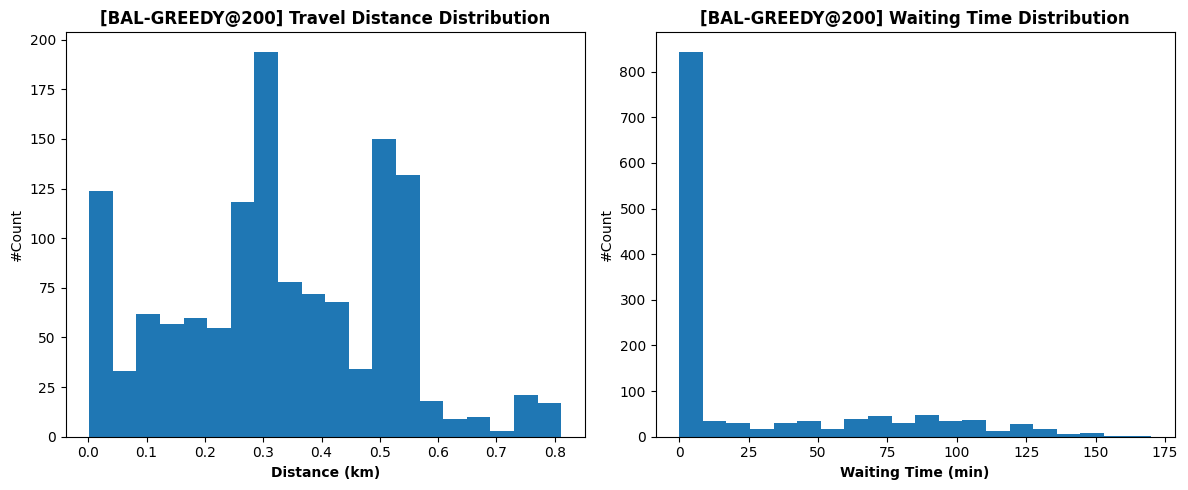

In [152]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

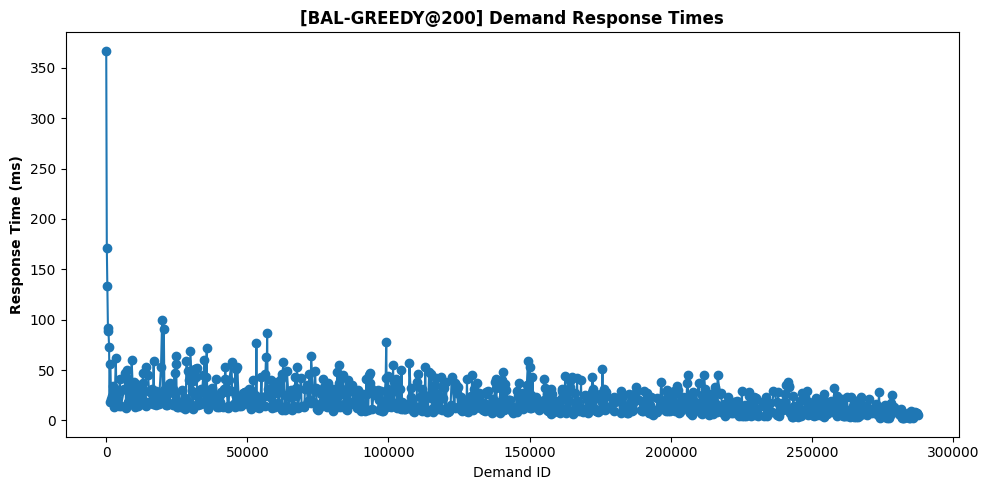

In [153]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

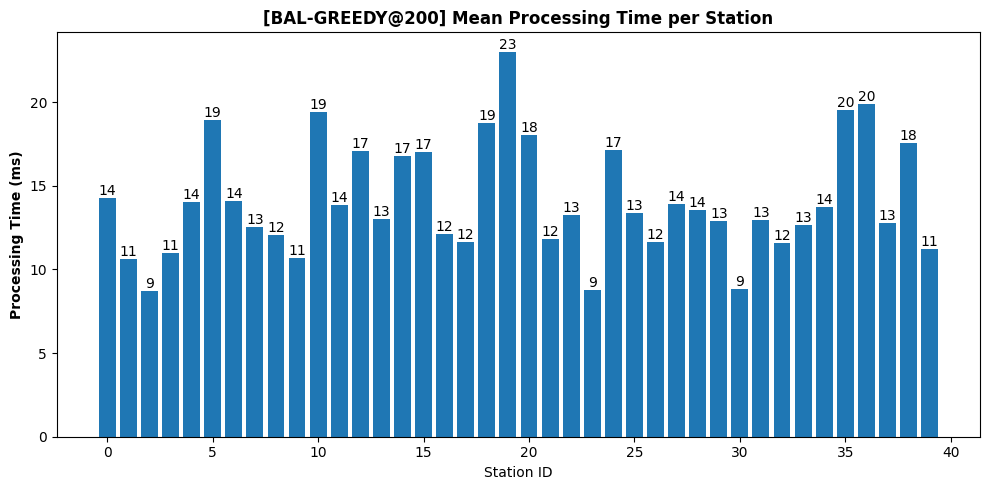

In [154]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [155]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.490972  0.581250  0.388889  0.347222       NaN   
1            0           6  0.047222  0.026389  0.000000  0.000000  0.000000   
2            0          11  0.470139  0.272917  0.102083  0.055556  0.159028   
3            0          15  0.140972  0.036111  0.000000  0.000000  0.000000   
4            0          19  0.081250  0.000000  0.000000  0.000000  0.000000   
5            0          25  0.193750  0.022917  0.000000  0.000000  0.000000   
6            0          34  0.515278  0.200000  0.052778  0.090278  0.161111   
7            0          36  0.392361  0.248611  0.036111  0.000000  0.063194   
8            0          37  0.437500  0.095139  0.018750  0.000000  0.000000   
9            0          39  0.329861  0.131944  0.000000  0.025000       NaN   
10           1           4  0.145833  0.090278  0.000000  0.018750       NaN   
11           1           5  0.180556  0.

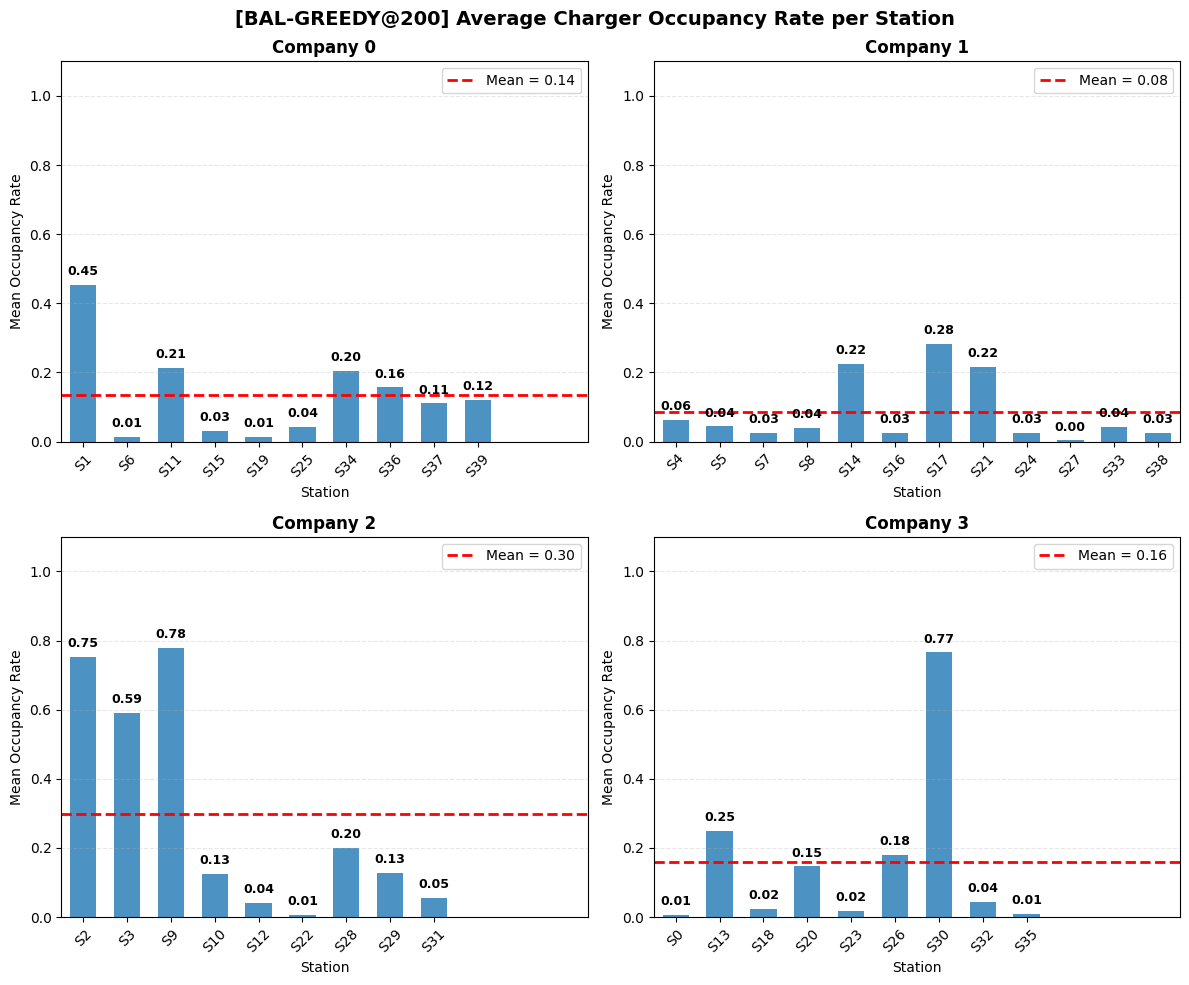

In [156]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

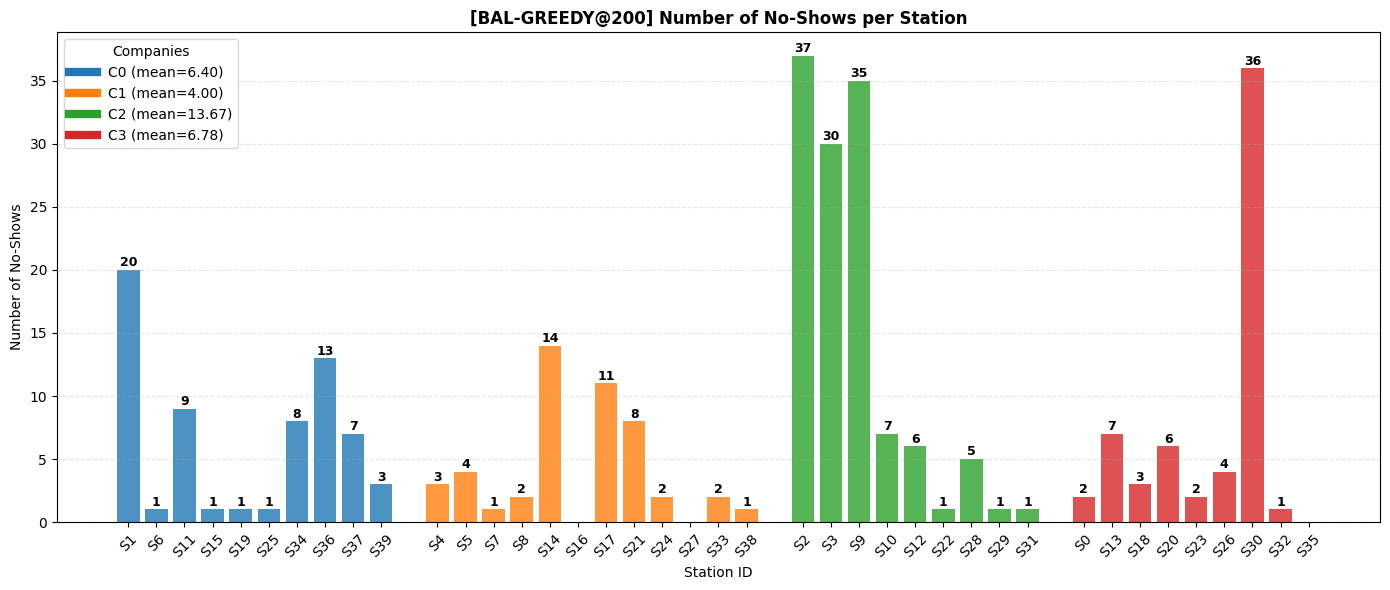

In [157]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [158]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,92,72,20,0,0,0.782609,0.217391,0.000000,0.000000
1,0,6,4,3,1,0,0,0.750000,0.250000,0.000000,0.000000
2,0,11,51,41,9,0,0,0.803922,0.176471,0.000000,0.000000
3,0,15,8,7,1,0,0,0.875000,0.125000,0.000000,0.000000
4,0,19,3,2,1,0,0,0.666667,0.333333,0.000000,0.000000
5,0,25,10,9,1,0,0,0.900000,0.100000,0.000000,0.000000
6,0,34,44,35,8,0,0,0.795455,0.181818,0.000000,0.000000
7,0,36,44,30,13,0,0,0.681818,0.295455,0.000000,0.000000
8,0,37,29,21,7,0,0,0.724138,0.241379,0.000000,0.000000
9,0,39,21,18,3,0,0,0.857143,0.142857,0.000000,0.000000


NUMBER OF REJECTED REQUESTS

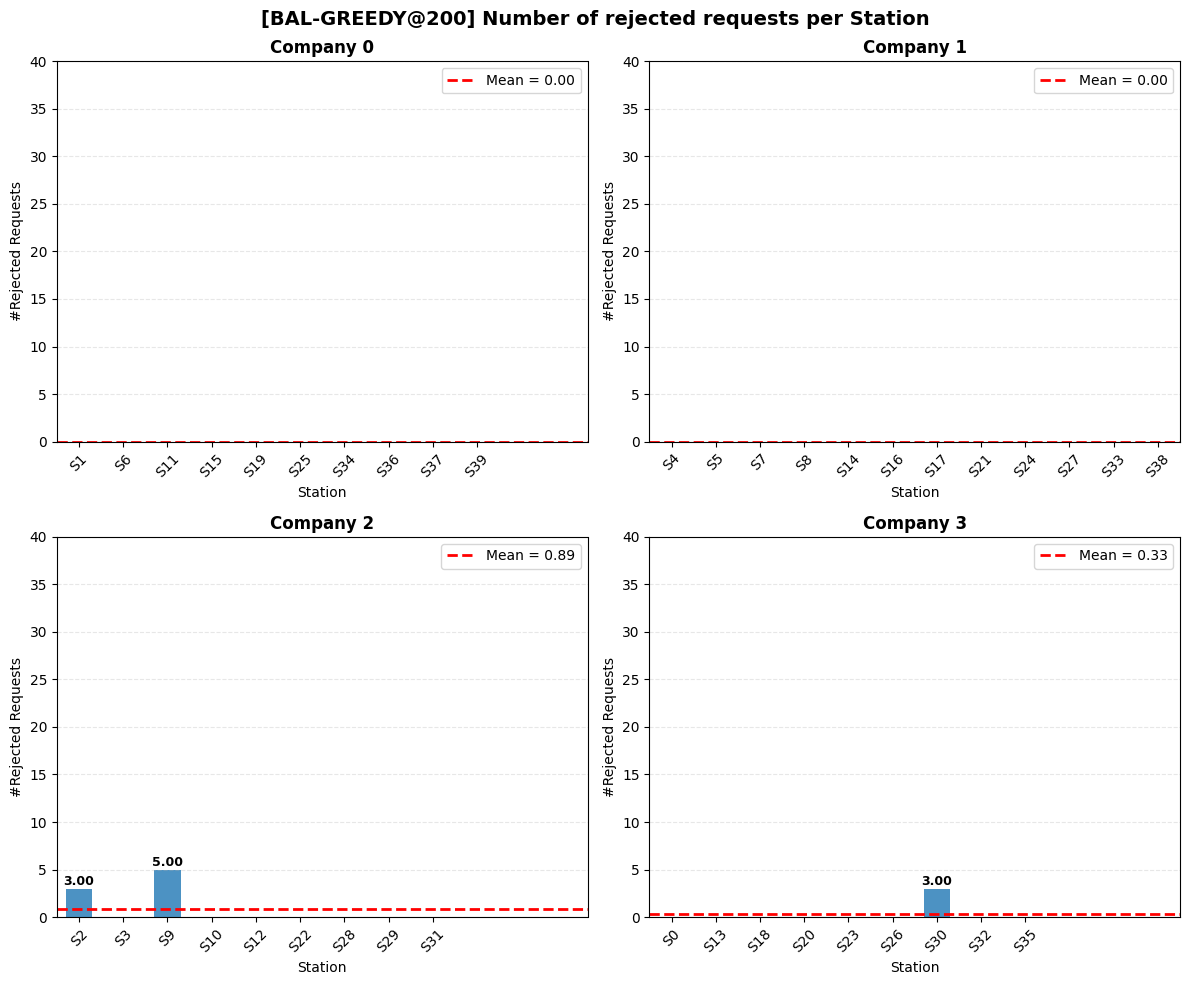

In [159]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

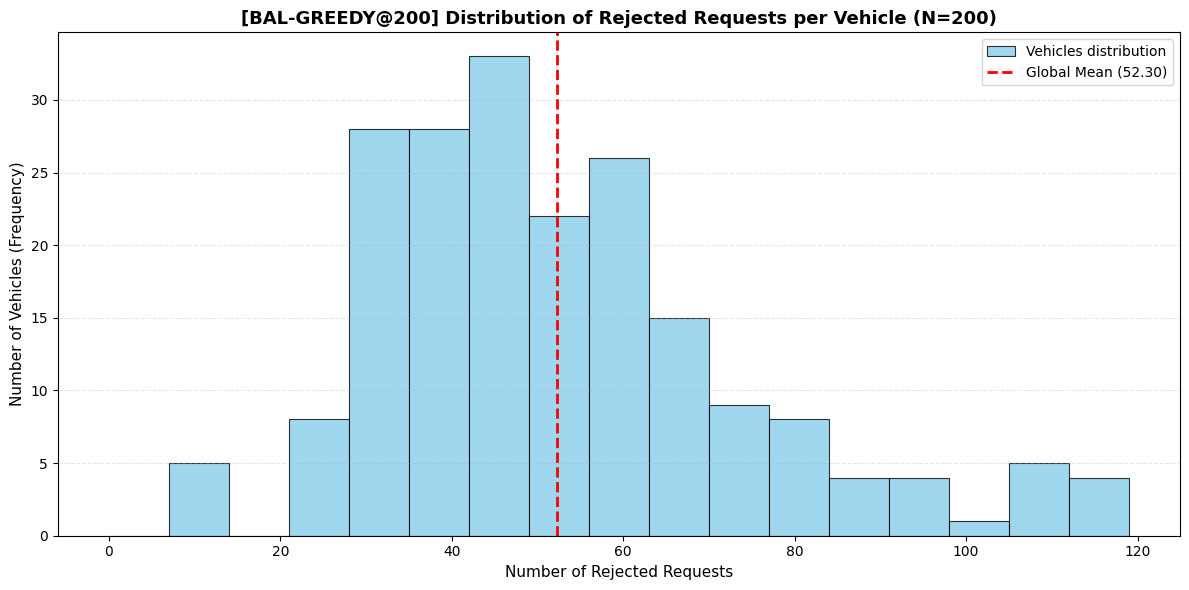

In [160]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

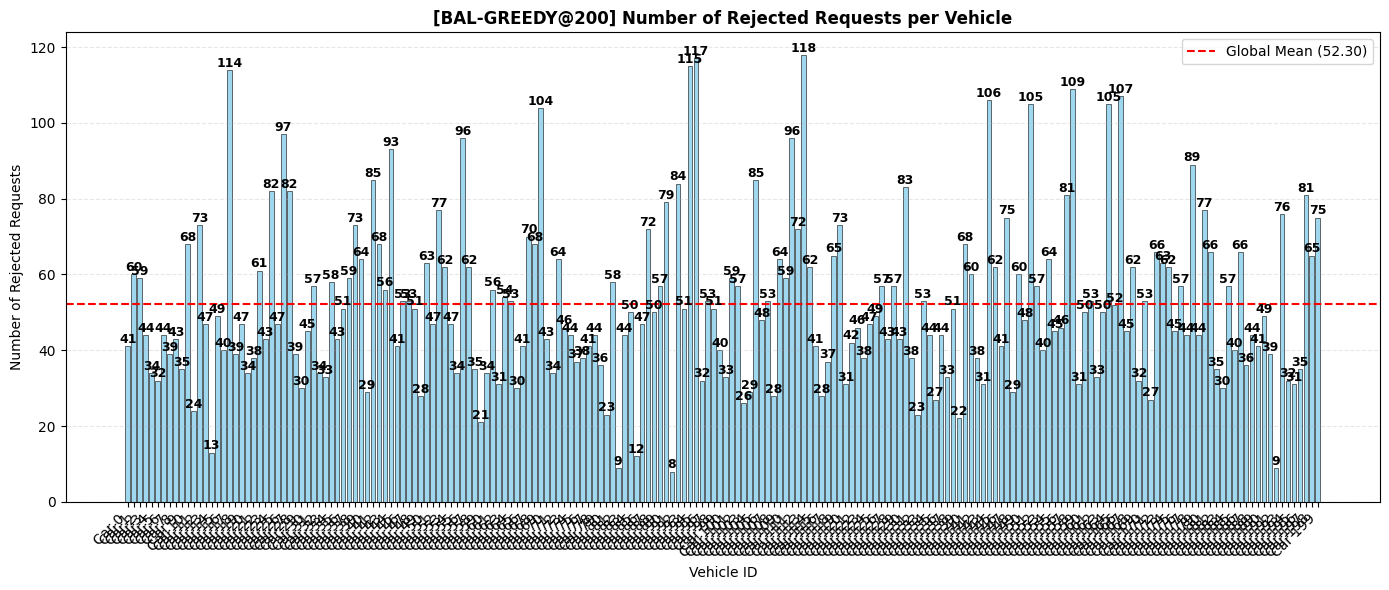

In [161]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

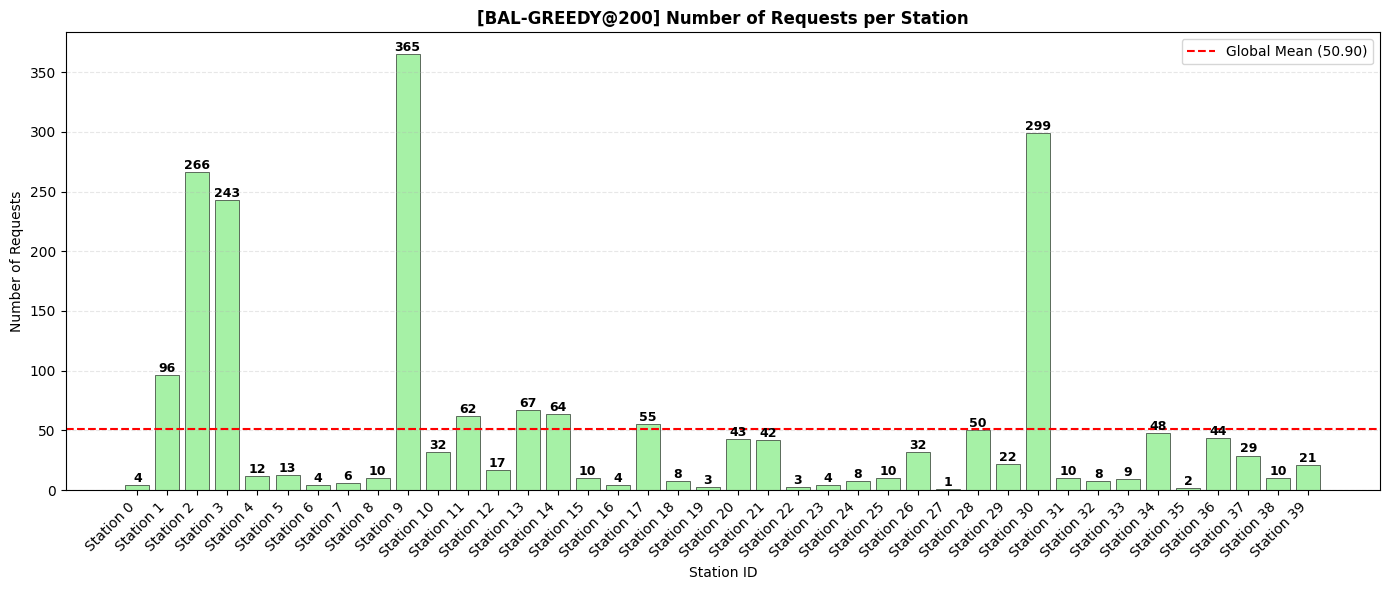

In [162]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [163]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [164]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [165]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:15:51.005 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:15:54.010 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:15:55.202 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:15:56.894 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:15:58.652 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:16:00.546 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:16:02.133 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:16:04.788 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:16:07.064 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:16:08.047 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:16:09.289 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [166]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 145.18 kWh
  Station 1: 5.98 kWh
  Station 2: 110.52 kWh
  Station 3: 62.27 kWh
  Station 4: 105.12 kWh
  Station 5: 61.37 kWh
  Station 6: 49.16 kWh
  Station 7: 80.00 kWh
  Station 8: 25.79 kWh
  Station 9: 42.41 kWh
  Station 10: 0.87 kWh
  Station 11: 19.79 kWh
  Station 12: 37.45 kWh
  Station 13: 166.25 kWh
  Station 14: 84.17 kWh
  Station 15: 46.62 kWh
  Station 16: 26.09 kWh
  Station 17: 46.88 kWh
  Station 18: 23.15 kWh
  Station 19: 5.56 kWh
  Station 20: 85.20 kWh
  Station 21: 12.55 kWh
  Station 22: 188.86 kWh
  Station 23: 139.92 kWh
  Station 24: 28.93 kWh
  Station 25: 11.12 kWh
  Station 26: 12.96 kWh
  Station 27: 43.47 kWh
  Station 28: 17.41 kWh
  Station 29: 8.18 kWh
  Station 30: 10.67 kWh
  Station 31: 5.03 kWh
  Station 32: 48.52 kWh
  Station 33: 94.23 kWh
  Station 34: 9.92 kWh
  Station 35: 11.06 kWh
  Station 36: 81.38 kWh
  Station 37: 8.03 kWh
  Station 38: 185.10 kWh
  Station 3

In [167]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

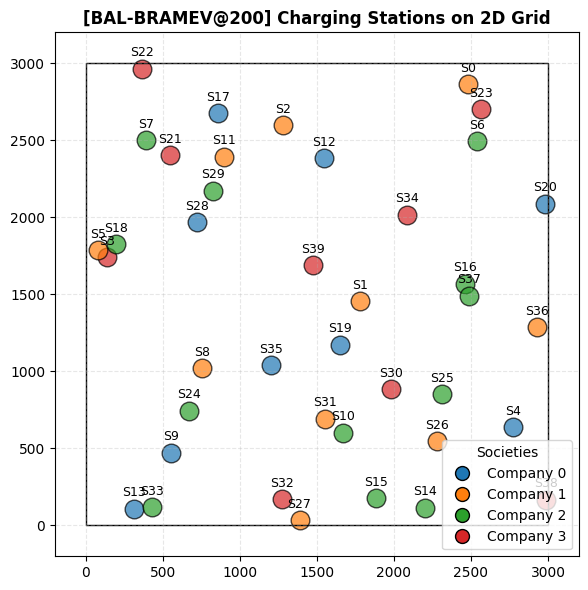

In [168]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

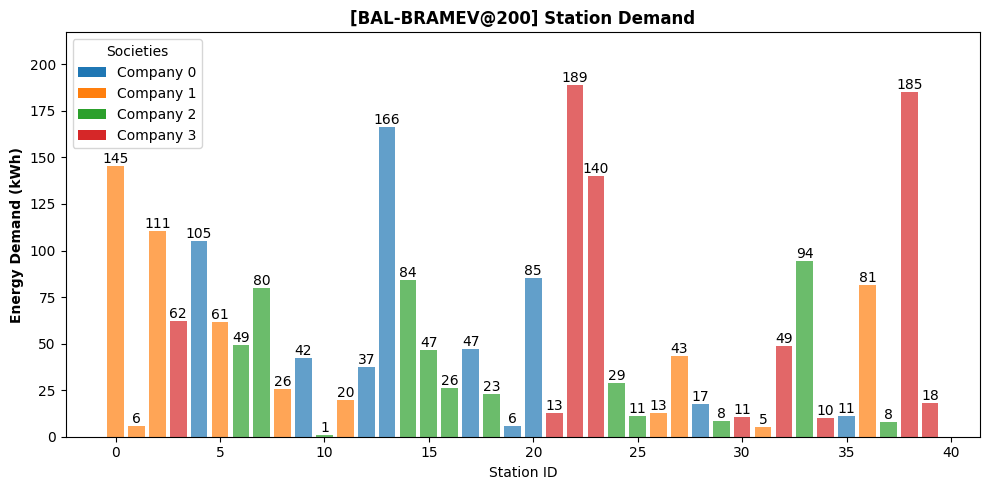

In [169]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

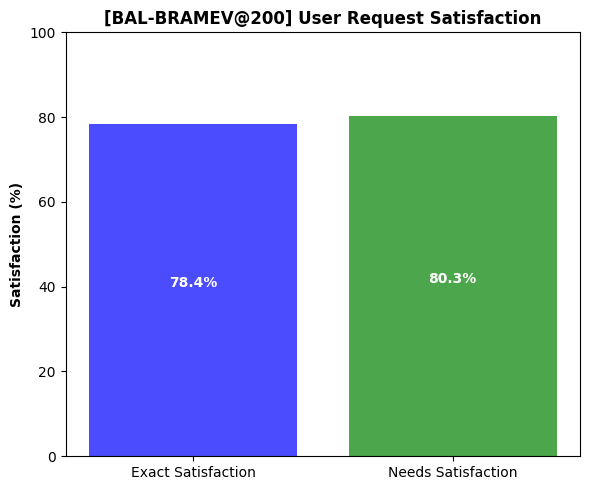

In [170]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

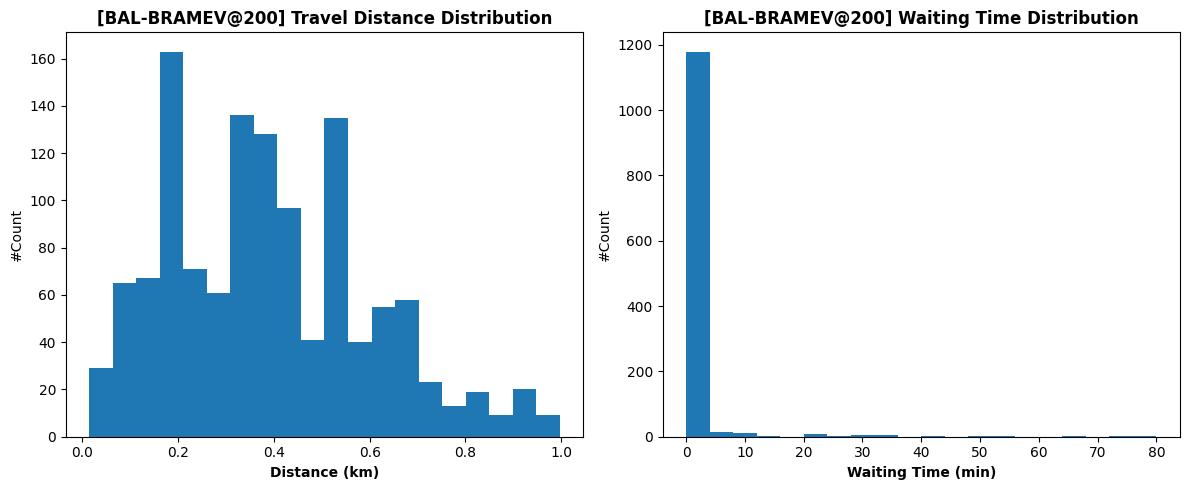

In [171]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

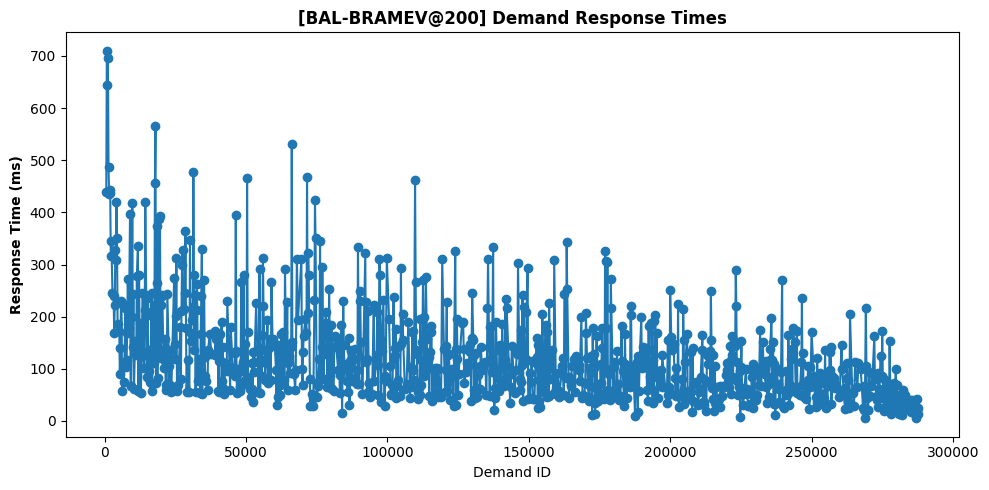

In [172]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

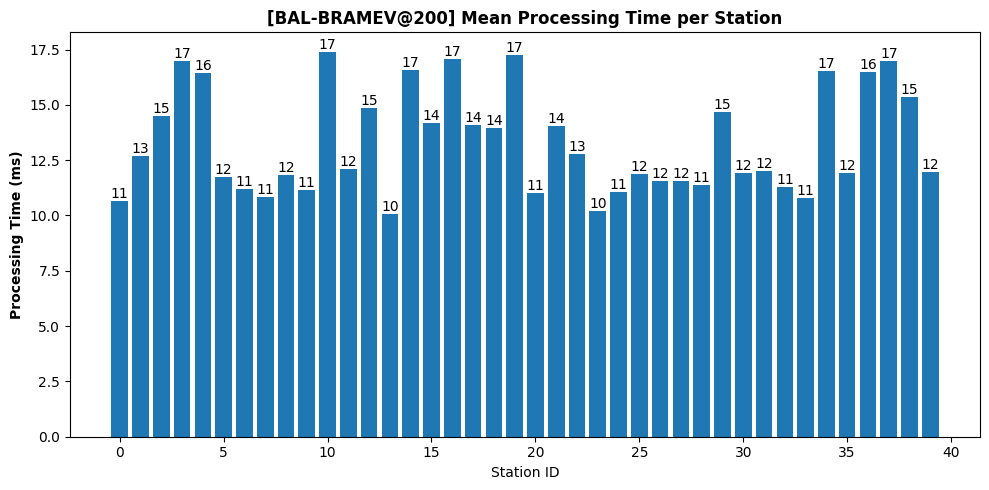

In [173]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

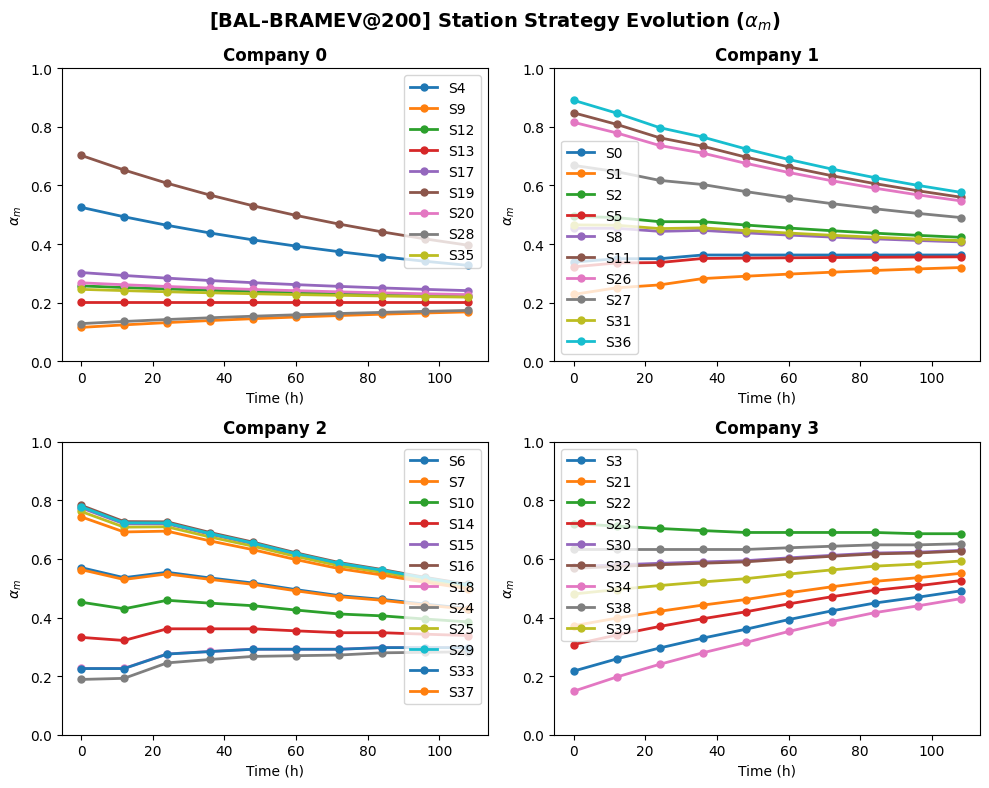

In [174]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [175]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           4  0.604861  0.320833  0.124306  0.024306  0.066667   
1            0           9  0.311806  0.118056  0.102083  0.082639       NaN   
2            0          12  0.296528  0.156250  0.020833  0.000000  0.027083   
3            0          13  0.628472  0.611806  0.560417  0.595139       NaN   
4            0          17  0.381944  0.247222  0.079167  0.000000  0.000000   
5            0          19  0.085417  0.000000  0.000000  0.000000  0.000000   
6            0          20  0.606944  0.326389  0.156944  0.120139       NaN   
7            0          28  0.270139  0.000000  0.000000  0.000000       NaN   
8            0          35  0.097222  0.024306  0.000000  0.020833       NaN   
9            1           0  0.713889  0.541667  0.372222  0.497222       NaN   
10           1           1  0.102778  0.000000  0.000000  0.000000       NaN   
11           1           2  0.655556  0.

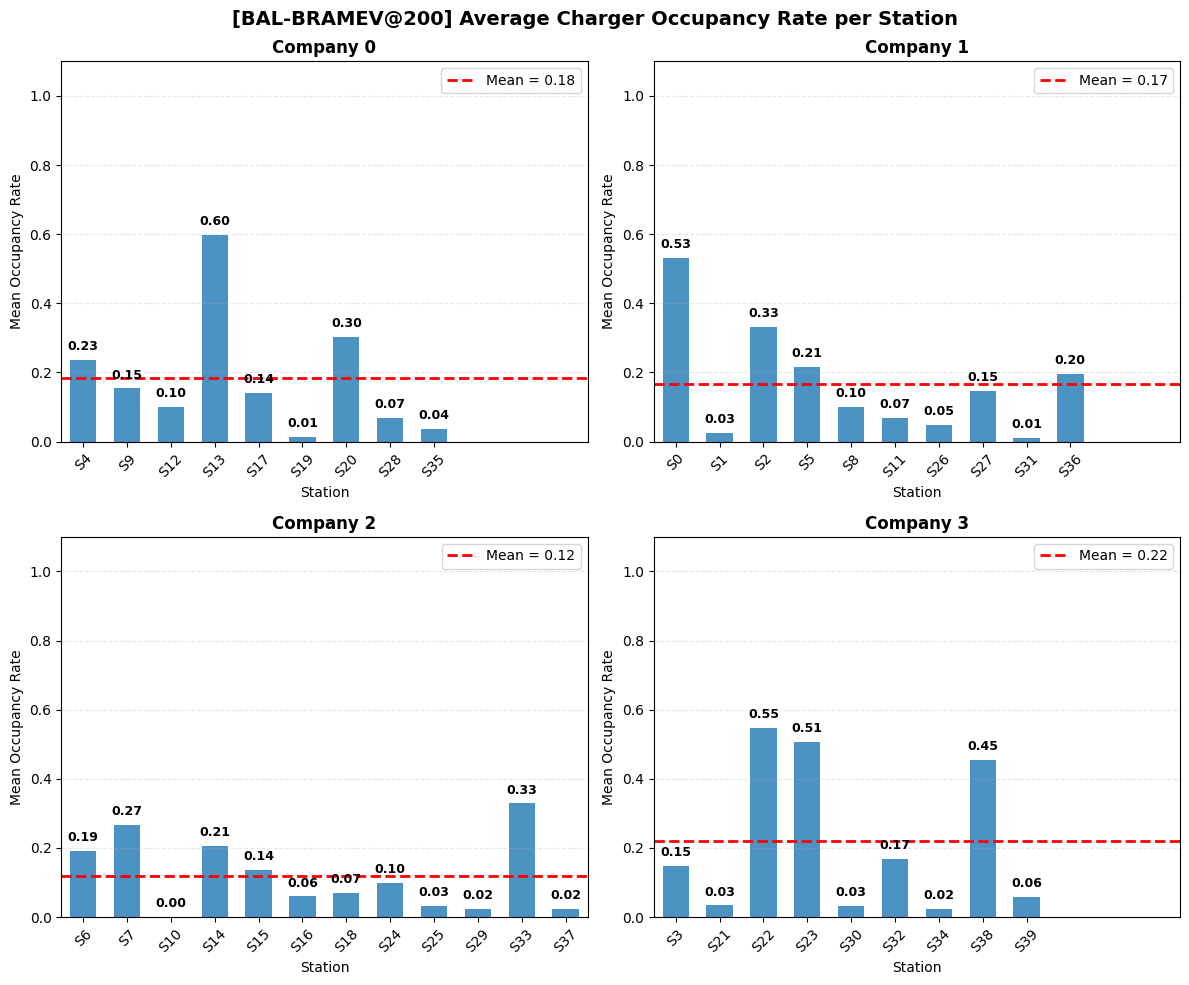

In [176]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

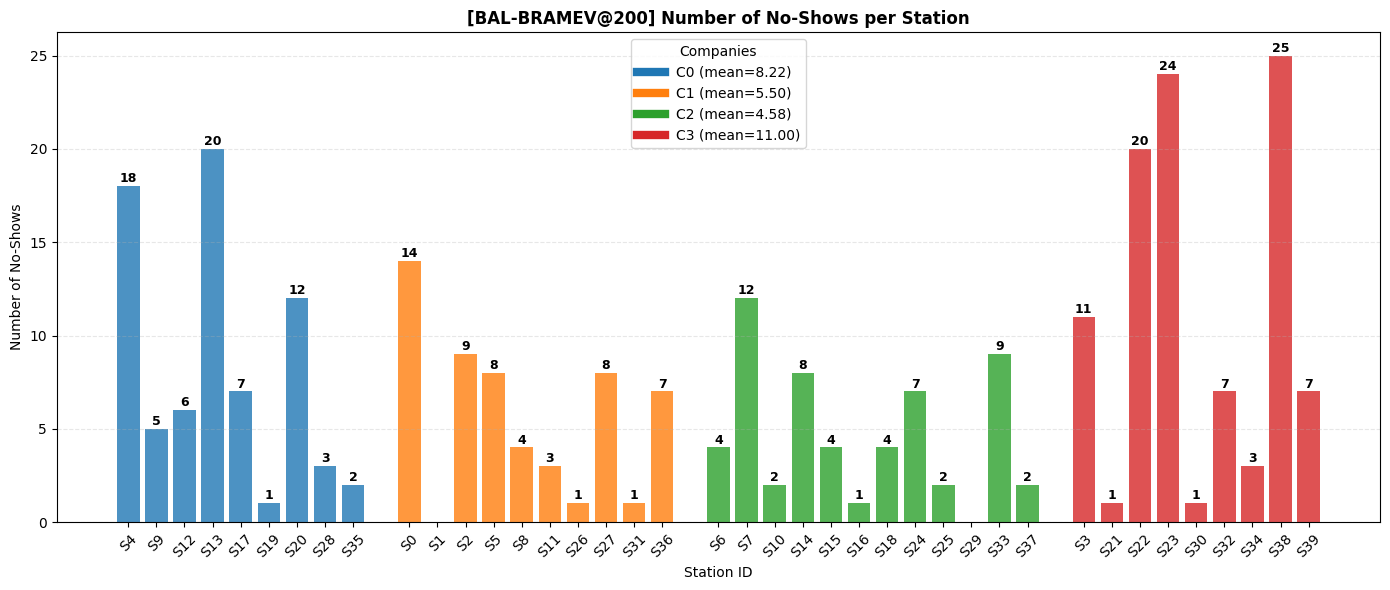

In [177]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [178]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,4,79,60,18,0,0,0.759494,0.227848,0.0,0.0
1,0,9,30,25,5,0,0,0.833333,0.166667,0.0,0.0
2,0,12,26,20,6,0,0,0.769231,0.230769,0.0,0.0
3,0,13,120,95,20,0,0,0.791667,0.166667,0.0,0.0
4,0,17,33,25,7,0,0,0.757576,0.212121,0.0,0.0
5,0,19,4,3,1,0,0,0.750000,0.250000,0.0,0.0
6,0,20,64,51,12,0,0,0.796875,0.187500,0.0,0.0
7,0,28,13,10,3,0,0,0.769231,0.230769,0.0,0.0
8,0,35,9,7,2,0,0,0.777778,0.222222,0.0,0.0
9,1,0,100,84,14,0,0,0.840000,0.140000,0.0,0.0


NUMBER OF REJECTED REQUESTS

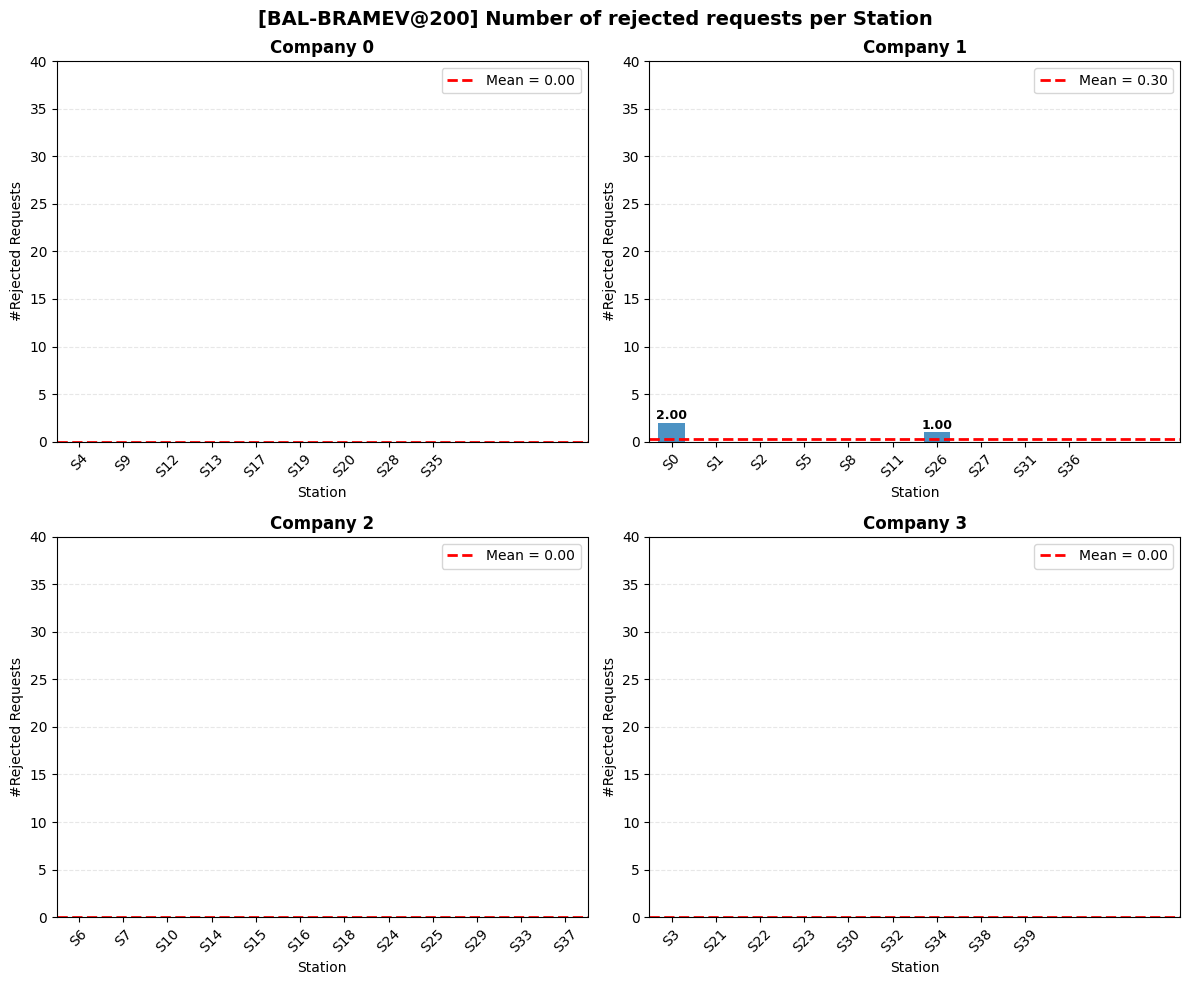

In [179]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

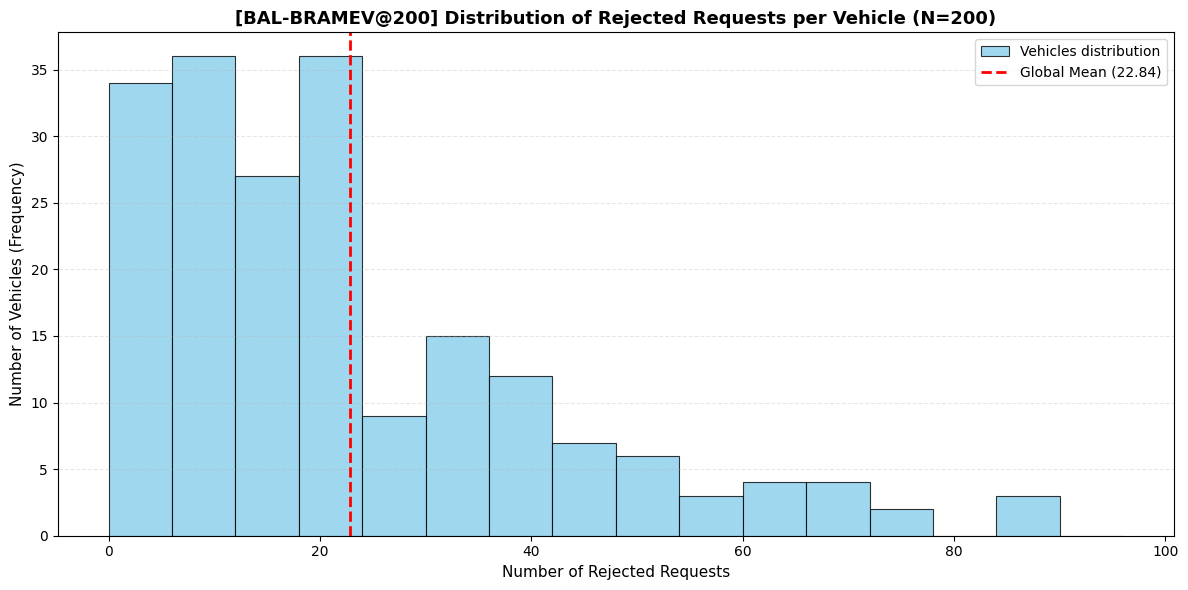

In [180]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

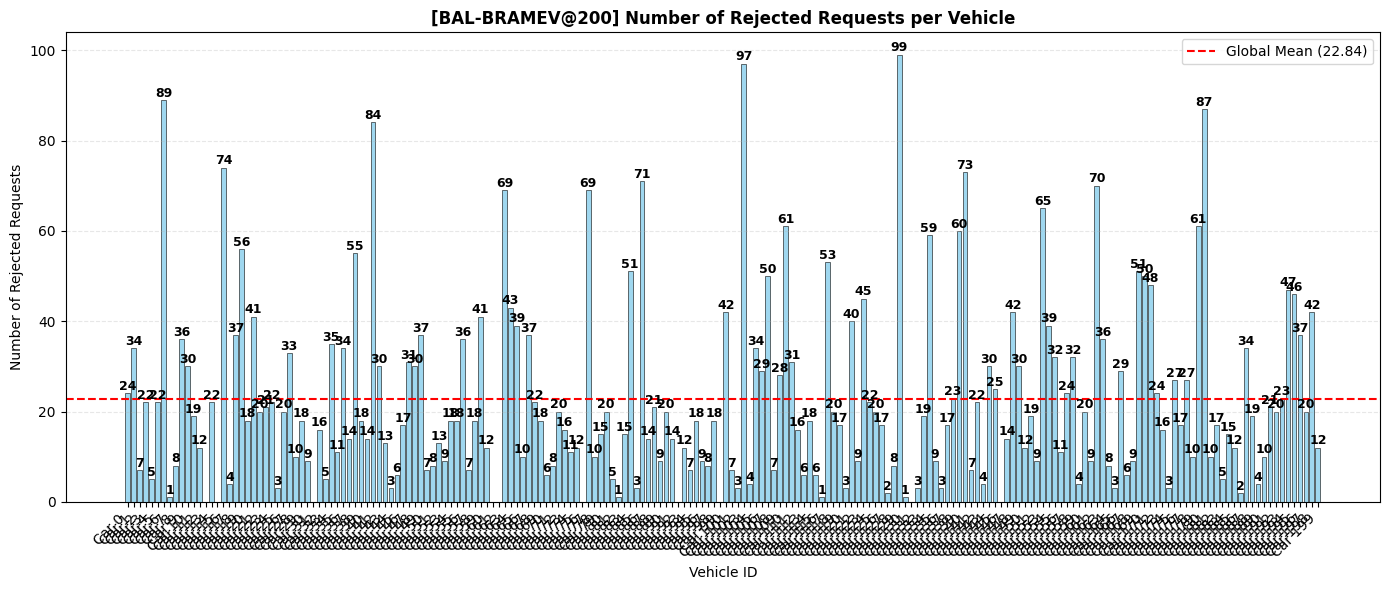

In [181]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

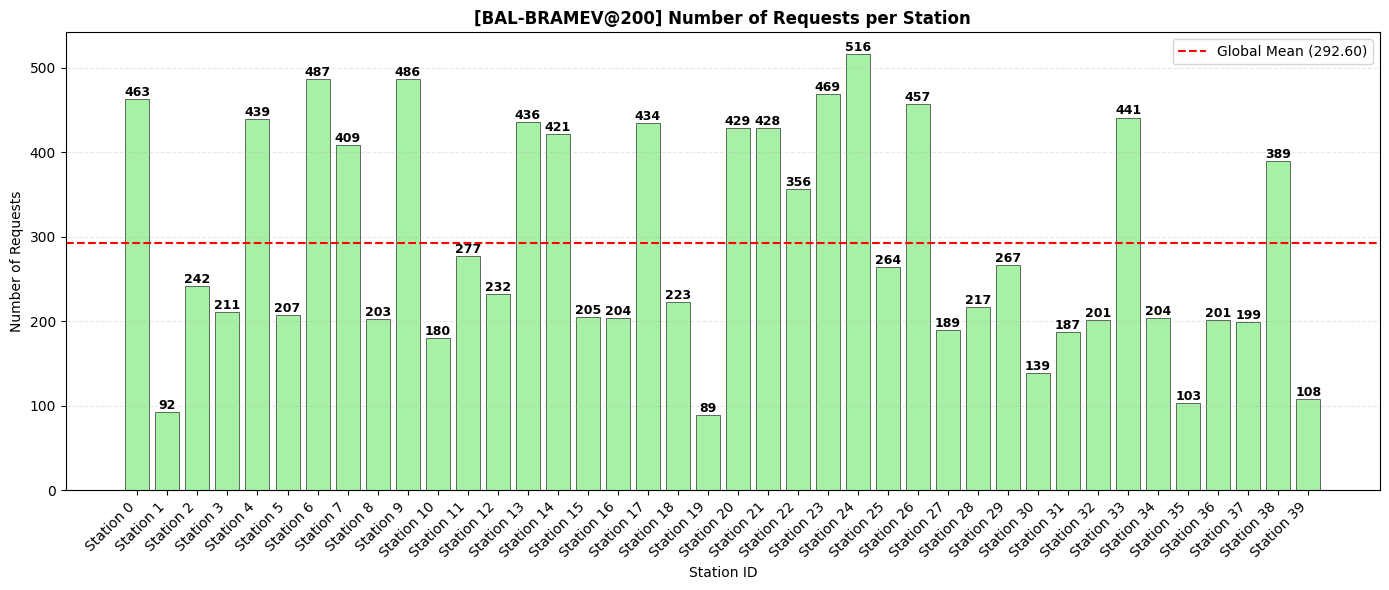

In [182]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [183]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

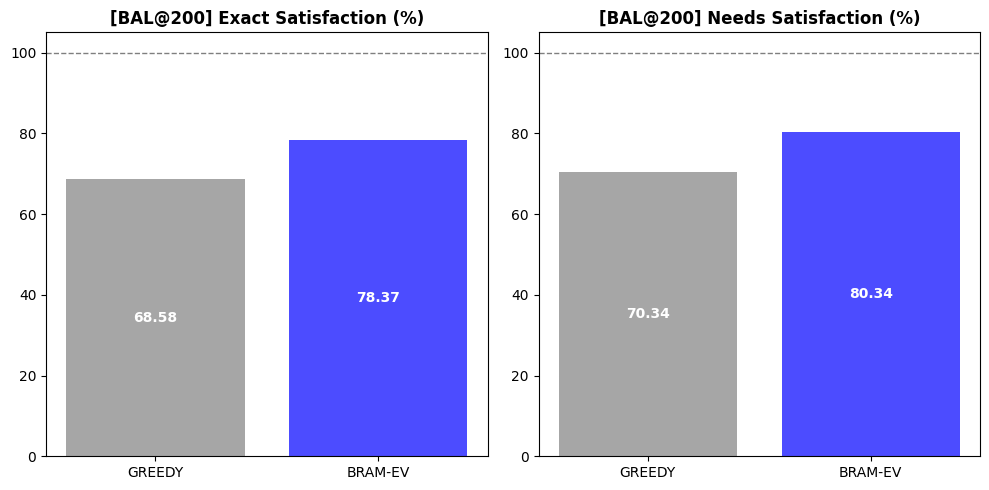

In [184]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

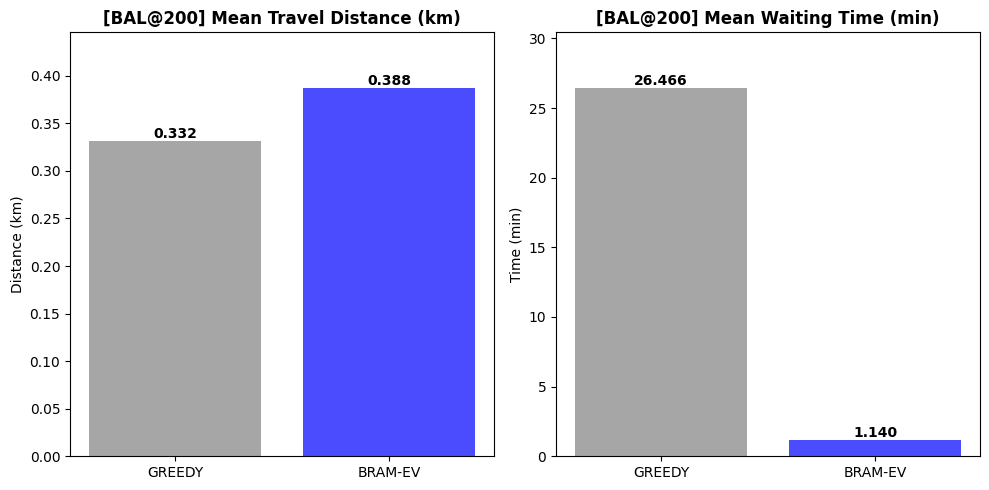

In [185]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

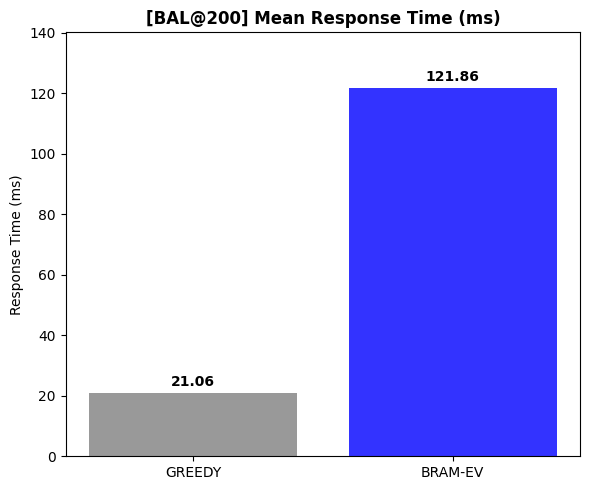

In [186]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [187]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [188]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [189]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [190]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:17:53.674 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 12/1440
2026-07-09 20:17:54.150 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 24/1440
2026-07-09 20:17:54.724 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 36/1440
2026-07-09 20:17:55.117 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 48/1440
2026-07-09 20:17:55.637 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 60/1440
2026-07-09 20:17:56.119 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 72/1440
2026-07-09 20:17:56.515 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 84/1440
2026-07-09 20:17:56.957 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 96/1440
2026-07-09 20:17:57.392 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 108/1440
2026-07-09 20:17:57.794 | INFO     | src.experiments.simulation_greedy:step:53 - INSTANT 120/1440
2026-07-09 20:17:58.345 | IN

##### *Metrics*

In [191]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 186.68 kWh
  Station 1: 21.73 kWh
  Station 2: 88.87 kWh
  Station 3: 2.87 kWh
  Station 4: 1.62 kWh
  Station 5: 4.37 kWh
  Station 6: 141.32 kWh
  Station 7: 9.74 kWh
  Station 8: 7.30 kWh
  Station 9: 124.62 kWh
  Station 10: 80.45 kWh
  Station 11: 77.06 kWh
  Station 12: 78.52 kWh
  Station 13: 8.37 kWh
  Station 14: 132.76 kWh
  Station 15: 10.23 kWh
  Station 16: 127.09 kWh
  Station 17: 275.90 kWh
  Station 18: 75.83 kWh
  Station 19: 107.79 kWh
  Station 20: 15.58 kWh
  Station 21: 16.65 kWh
  Station 22: 19.78 kWh
  Station 23: 26.82 kWh
  Station 24: 0.00 kWh
  Station 25: 84.59 kWh
  Station 26: 265.62 kWh
  Station 27: 182.10 kWh
  Station 28: 9.32 kWh
  Station 29: 272.53 kWh
  Station 30: 4.73 kWh
  Station 31: 1.83 kWh
  Station 32: 19.90 kWh
  Station 33: 58.72 kWh
  Station 34: 20.99 kWh
  Station 35: 11.14 kWh
  Station 36: 10.92 kWh
  Station 37: 10.15 kWh
  Station 38: 12.89 kWh
  Station 3

In [192]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

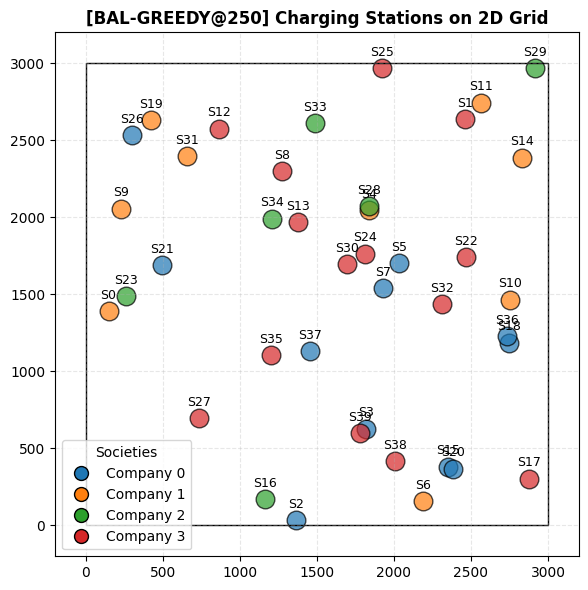

In [193]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

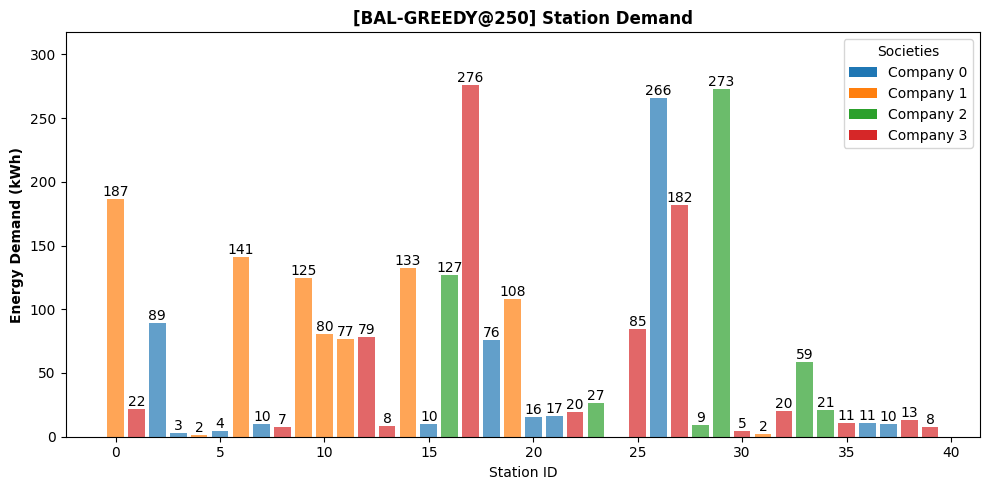

In [194]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

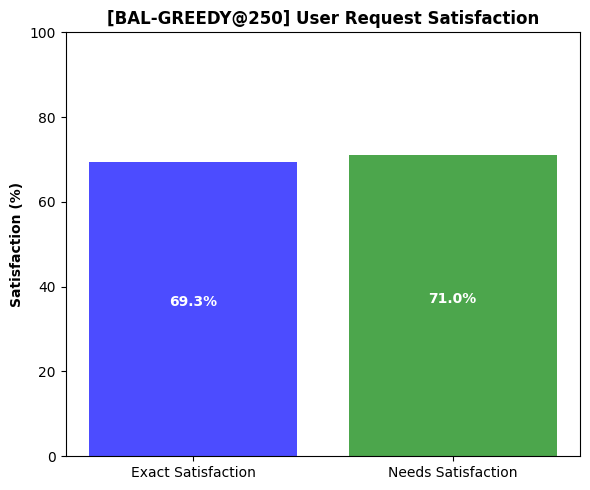

In [195]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

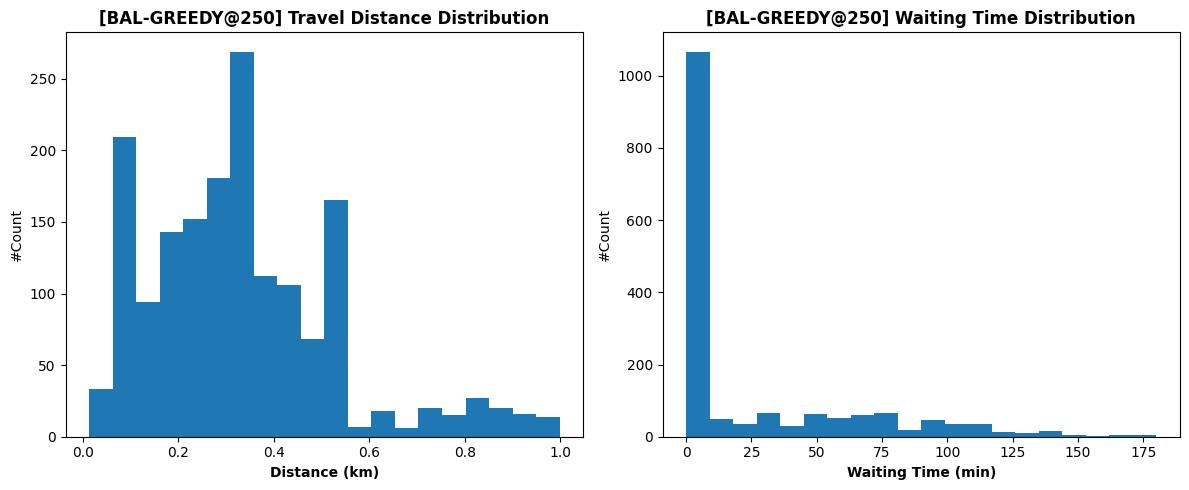

In [196]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

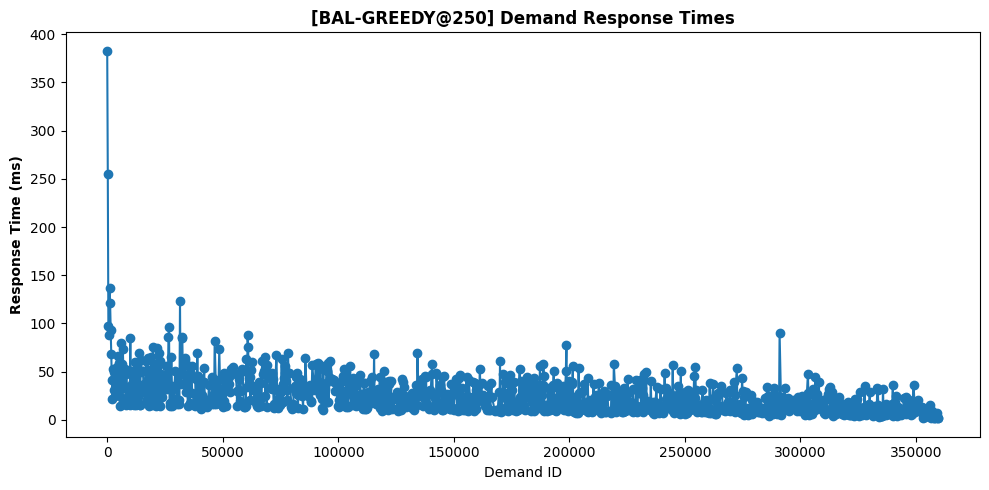

In [197]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

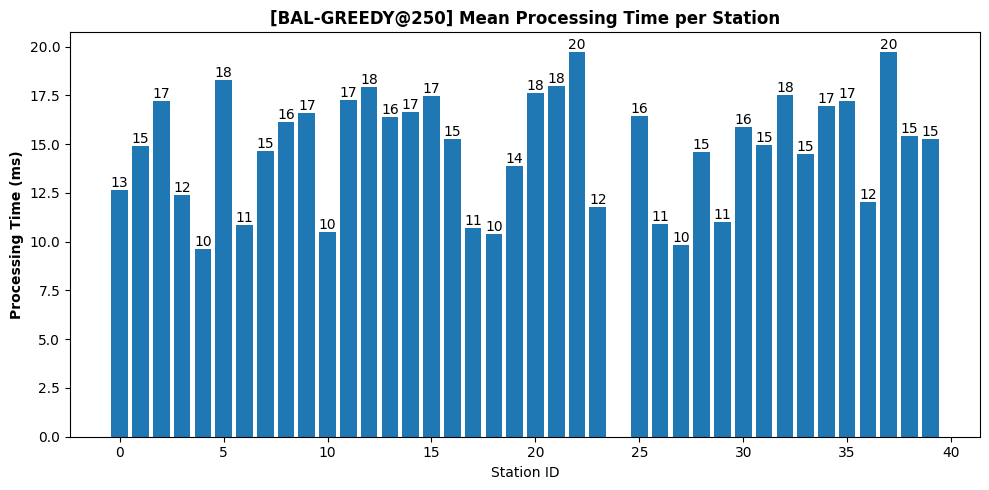

In [198]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [199]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.538889  0.368056  0.069444  0.000000  0.099306   
1            0           3  0.029861  0.000000  0.000000  0.000000       NaN   
2            0           5  0.054861  0.000000  0.000000  0.000000  0.000000   
3            0           7  0.111806  0.030556  0.000000  0.000000  0.000000   
4            0          15  0.131250  0.021528  0.000000  0.000000  0.000000   
5            0          18  0.437500  0.341667  0.143750  0.167361       NaN   
6            0          20  0.206250  0.000000  0.000000  0.000000  0.000000   
7            0          21  0.168056  0.050000  0.000000  0.000000  0.000000   
8            0          26  0.833333  0.798611  0.786806  0.641667  0.650000   
9            0          36  0.158333  0.000000  0.000000  0.000000       NaN   
10           0          37  0.079861  0.064583  0.000000  0.000000  0.000000   
11           1           0  0.668056  0.

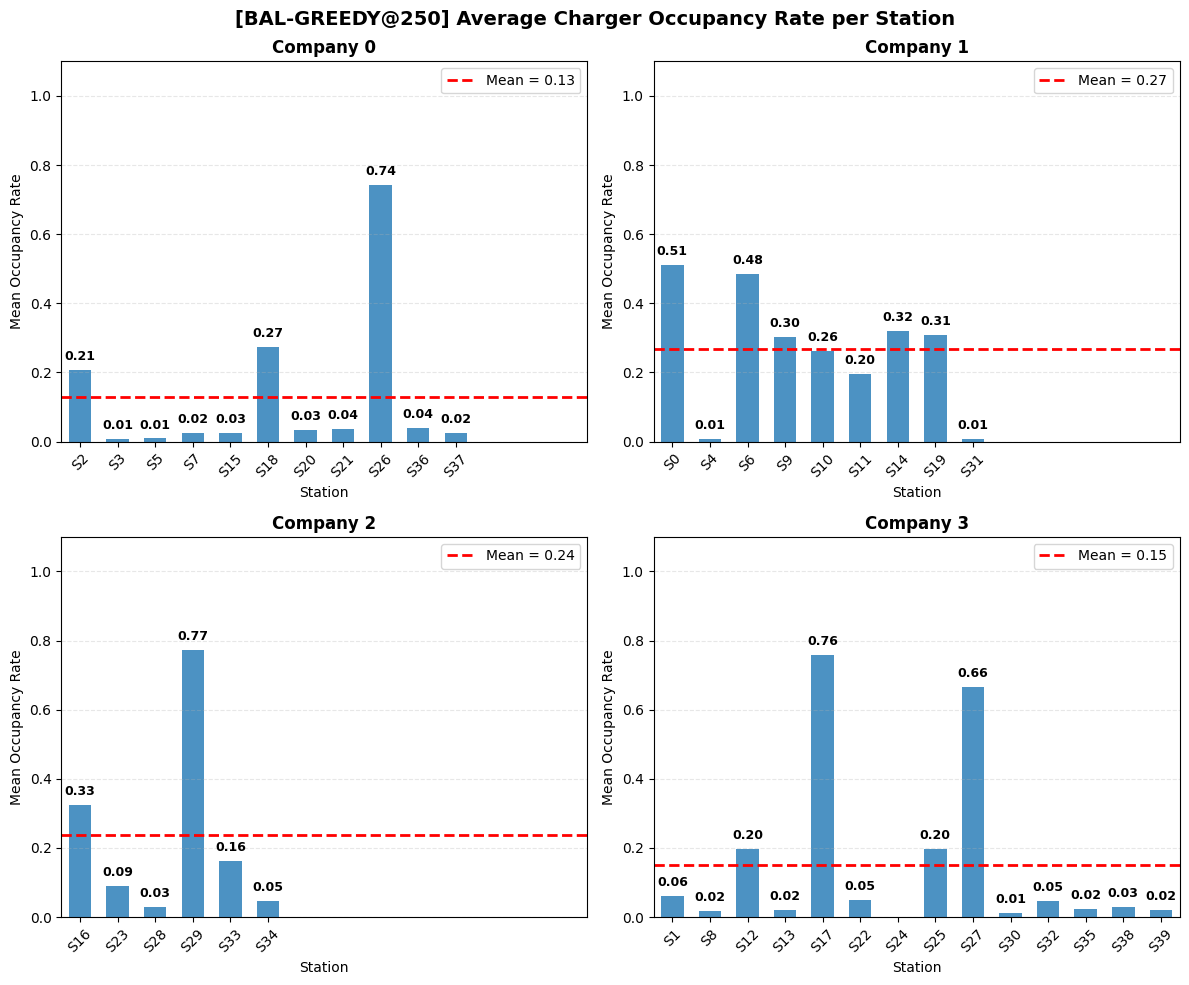

In [200]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

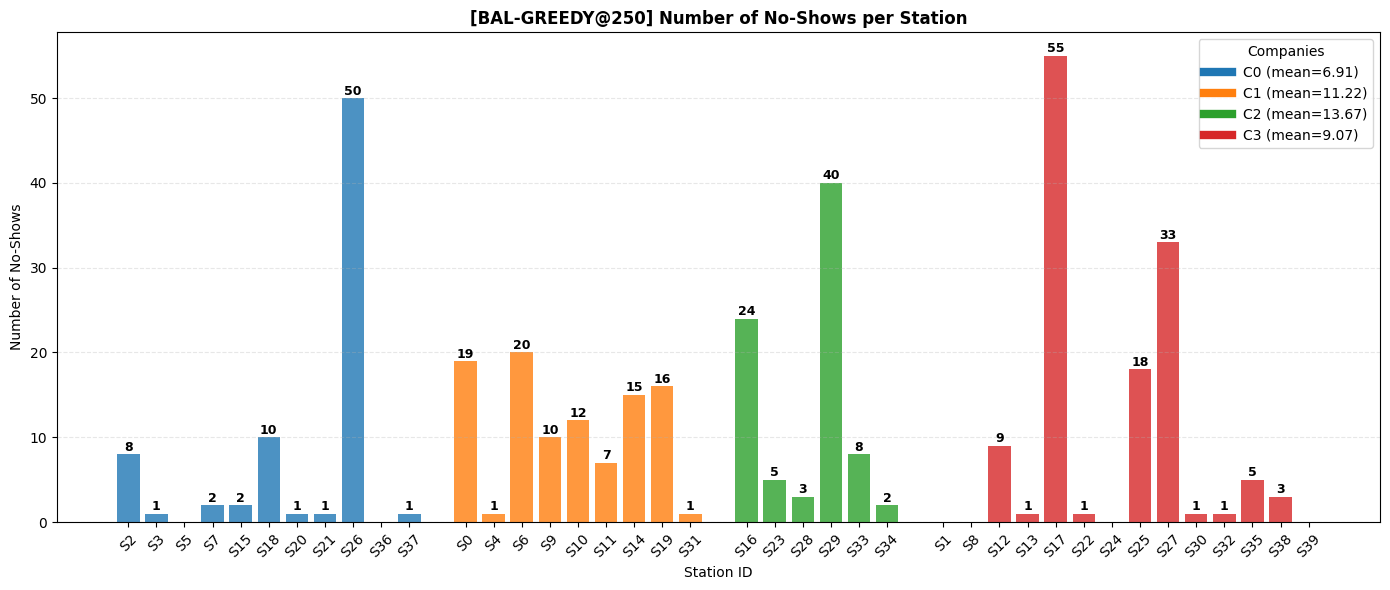

In [201]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [202]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,58,49,8,0,0,0.844828,0.137931,0.000000,0.000000
1,0,3,3,2,1,0,0,0.666667,0.333333,0.000000,0.000000
2,0,5,3,3,0,0,0,1.000000,0.000000,0.000000,0.000000
3,0,7,7,5,2,0,0,0.714286,0.285714,0.000000,0.000000
4,0,15,8,6,2,0,0,0.750000,0.250000,0.000000,0.000000
5,0,18,57,46,10,0,0,0.807018,0.175439,0.000000,0.000000
6,0,20,9,8,1,0,0,0.888889,0.111111,0.000000,0.000000
7,0,21,10,9,1,0,0,0.900000,0.100000,0.000000,0.000000
8,0,26,256,201,50,4,0,0.785156,0.195312,0.015625,0.000000
9,0,36,6,6,0,0,0,1.000000,0.000000,0.000000,0.000000


NUMBER OF REJECTED REQUESTS

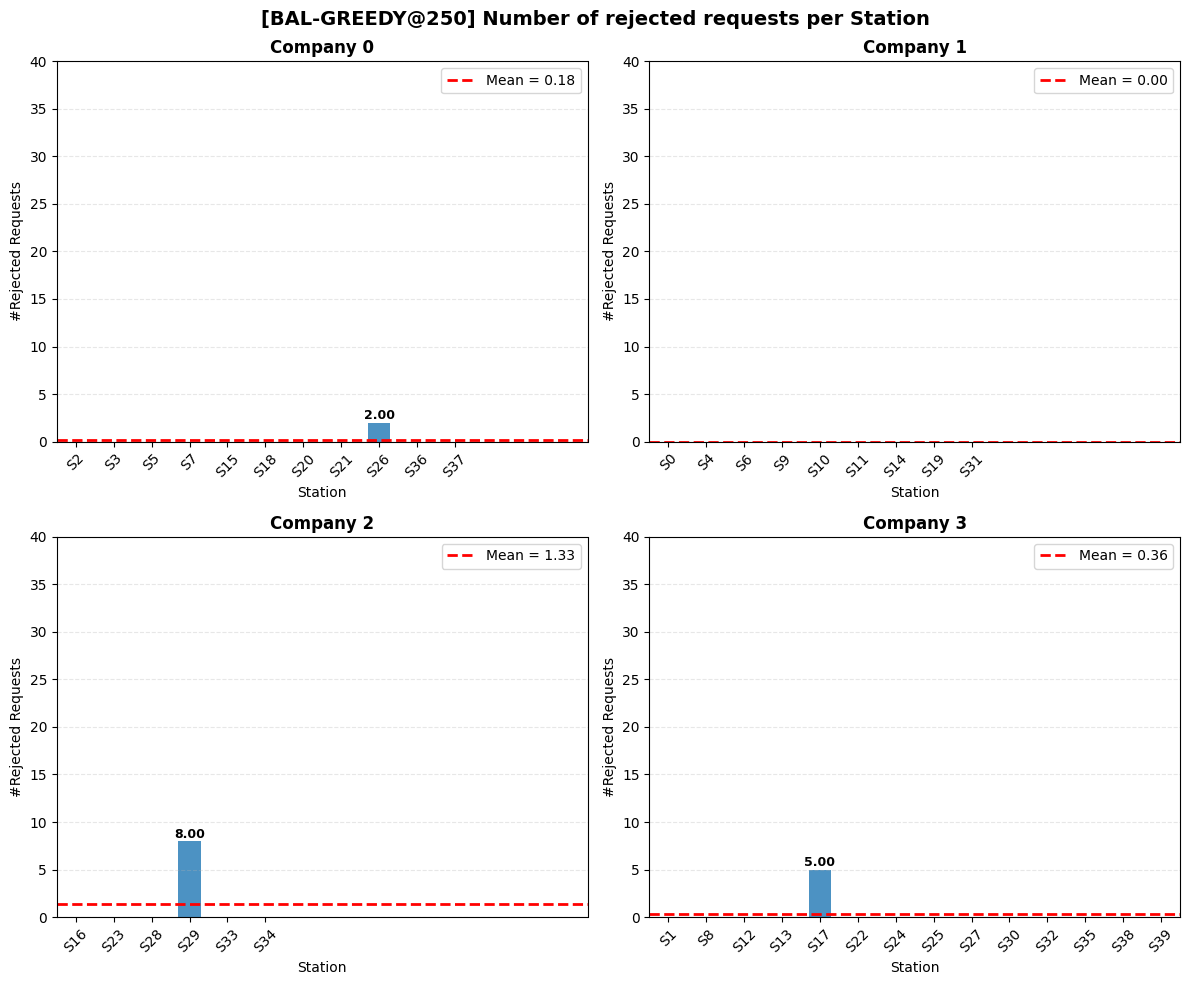

In [203]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [204]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [205]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [206]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-07-09 20:18:33.323 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-07-09 20:18:36.794 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-07-09 20:18:38.294 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-07-09 20:18:40.178 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-07-09 20:18:43.090 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-07-09 20:18:46.073 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-07-09 20:18:46.712 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-07-09 20:18:48.363 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-07-09 20:18:51.525 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-07-09 20:18:54.178 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-07-09 20:18:55.423 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-07

##### *Metrics*

In [207]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 87.22 kWh
  Station 1: 34.81 kWh
  Station 2: 96.21 kWh
  Station 3: 60.12 kWh
  Station 4: 101.67 kWh
  Station 5: 38.08 kWh
  Station 6: 20.02 kWh
  Station 7: 29.79 kWh
  Station 8: 41.46 kWh
  Station 9: 24.13 kWh
  Station 10: 160.45 kWh
  Station 11: 7.88 kWh
  Station 12: 11.95 kWh
  Station 13: 27.38 kWh
  Station 14: 211.70 kWh
  Station 15: 13.93 kWh
  Station 16: 18.23 kWh
  Station 17: 56.85 kWh
  Station 18: 114.49 kWh
  Station 19: 6.54 kWh
  Station 20: 91.40 kWh
  Station 21: 251.20 kWh
  Station 22: 35.83 kWh
  Station 23: 4.67 kWh
  Station 24: 6.96 kWh
  Station 25: 15.19 kWh
  Station 26: 3.73 kWh
  Station 27: 9.54 kWh
  Station 28: 33.41 kWh
  Station 29: 217.32 kWh
  Station 30: 98.47 kWh
  Station 31: 34.83 kWh
  Station 32: 5.40 kWh
  Station 33: 166.65 kWh
  Station 34: 18.02 kWh
  Station 35: 116.62 kWh
  Station 36: 46.49 kWh
  Station 37: 118.08 kWh
  Station 38: 60.64 kWh
  Station

In [208]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

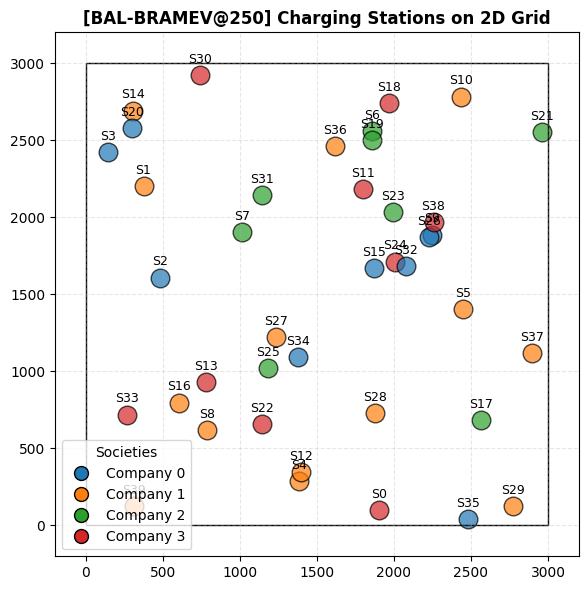

In [209]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

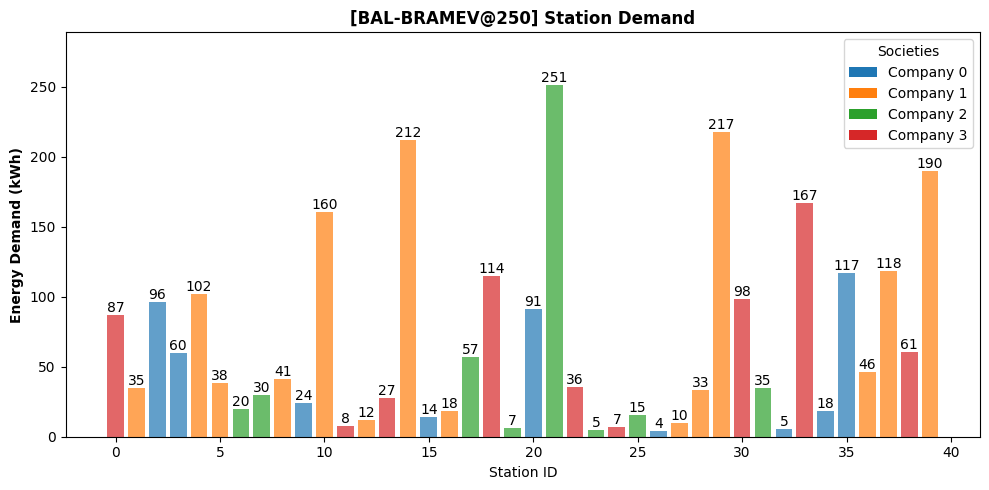

In [210]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

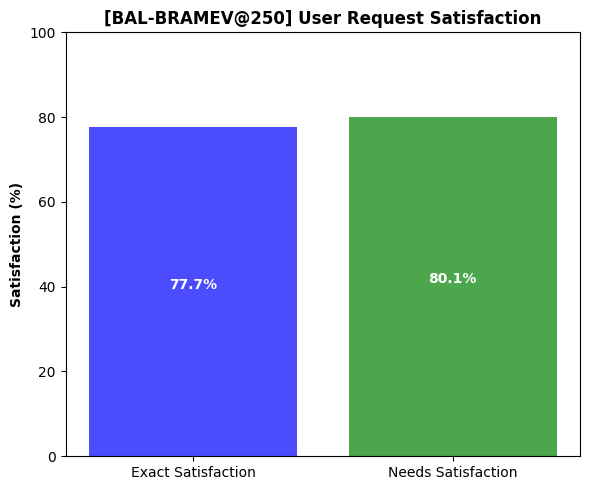

In [211]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

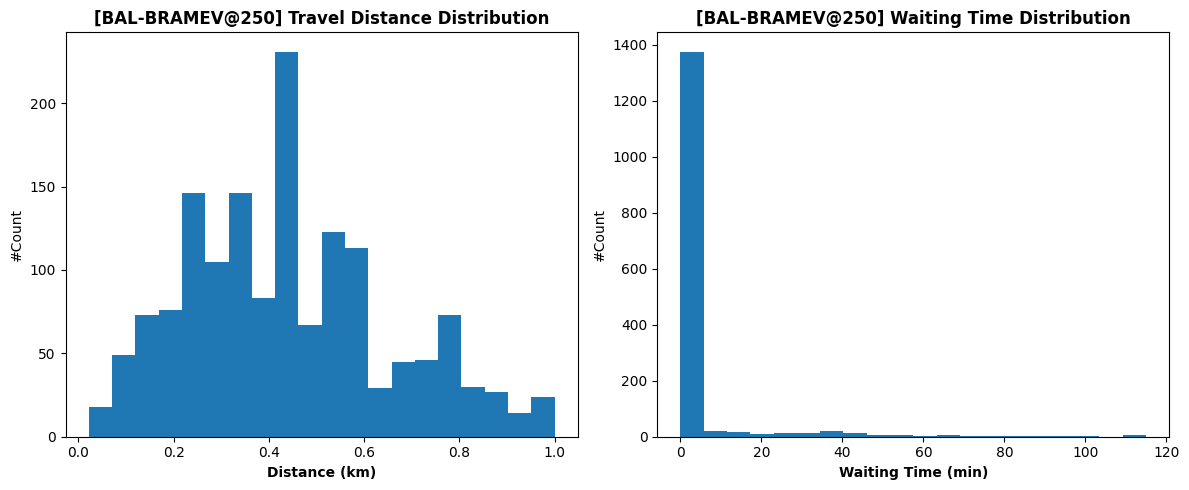

In [212]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

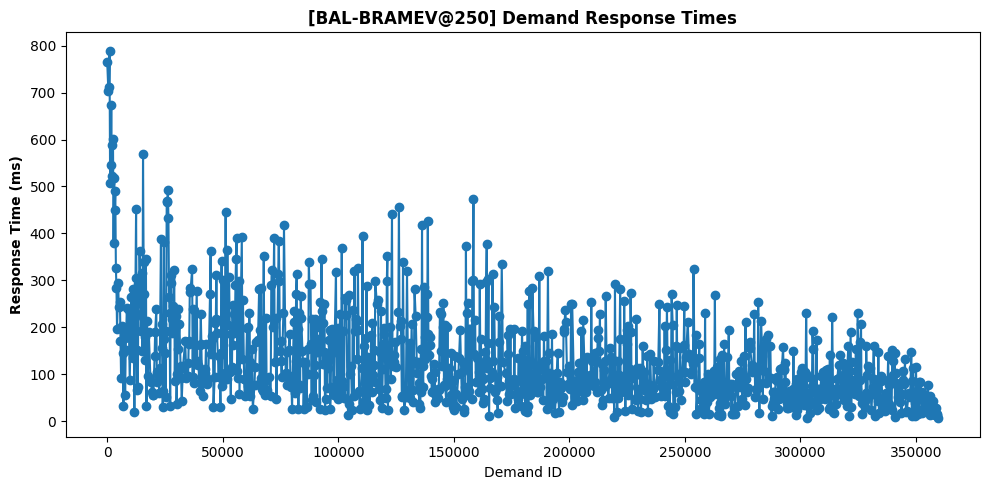

In [213]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

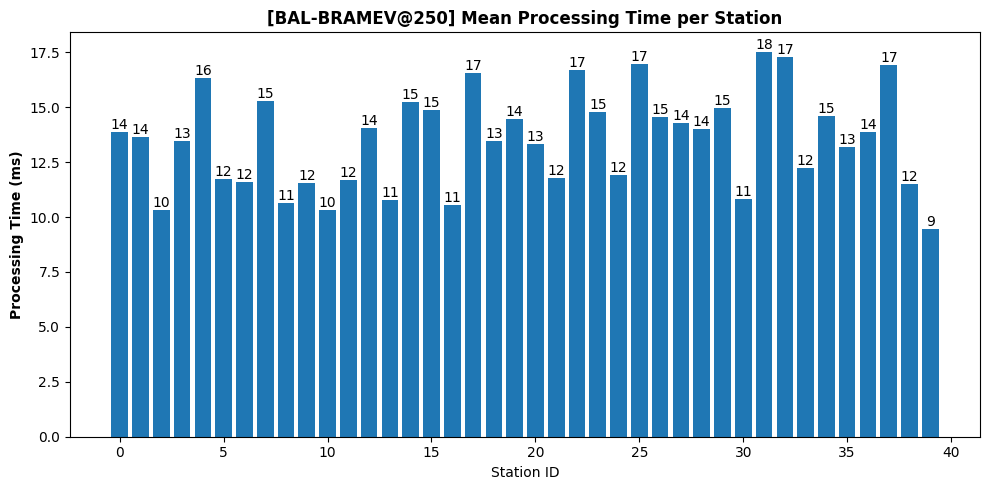

In [214]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

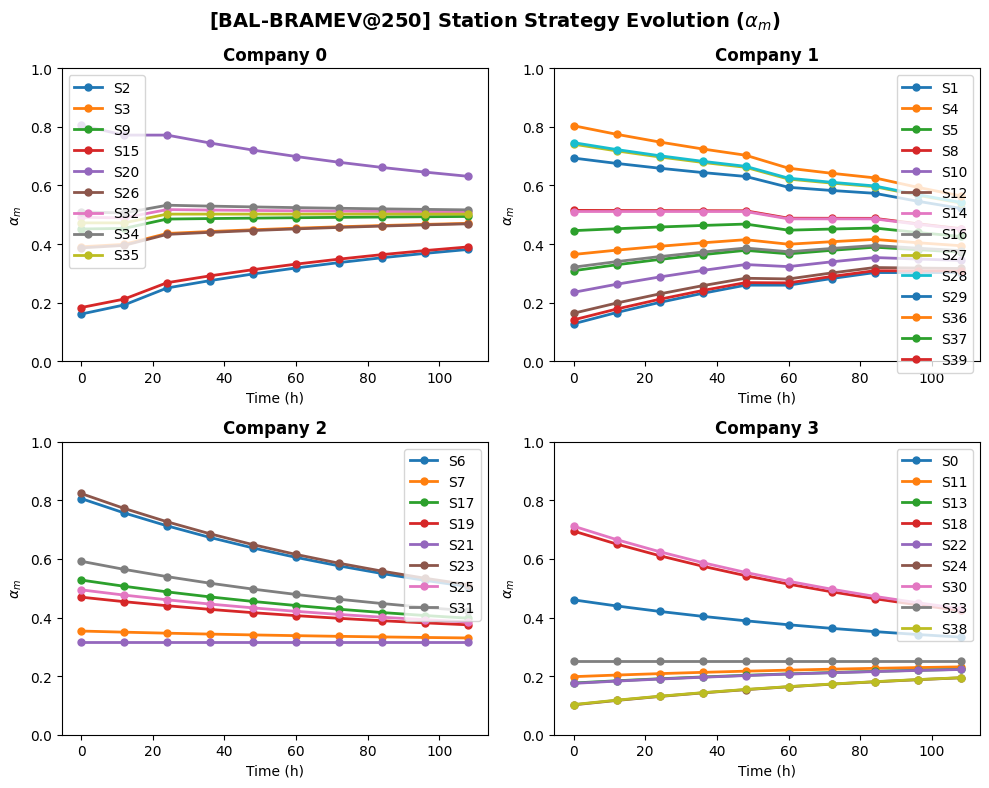

In [215]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [216]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.523611  0.375000  0.159722  0.222222       NaN   
1            0           3  0.375000  0.224306  0.063194  0.047222  0.154167   
2            0           9  0.263889  0.058333  0.010417  0.027778       NaN   
3            0          15  0.159722  0.038194  0.000000  0.000000  0.000000   
4            0          20  0.496528  0.369444  0.189583  0.112500  0.120139   
5            0          26  0.063889  0.000000  0.000000  0.000000  0.000000   
6            0          32  0.070833  0.000000  0.000000  0.000000  0.000000   
7            0          34  0.225000  0.027083  0.000000  0.000000  0.000000   
8            0          35  0.571528  0.398611  0.156944  0.185417  0.301389   
9            1           1  0.368056  0.078472  0.000000  0.000000  0.040972   
10           1           4  0.566667  0.456944  0.193750  0.034028  0.029861   
11           1           5  0.248611  0.

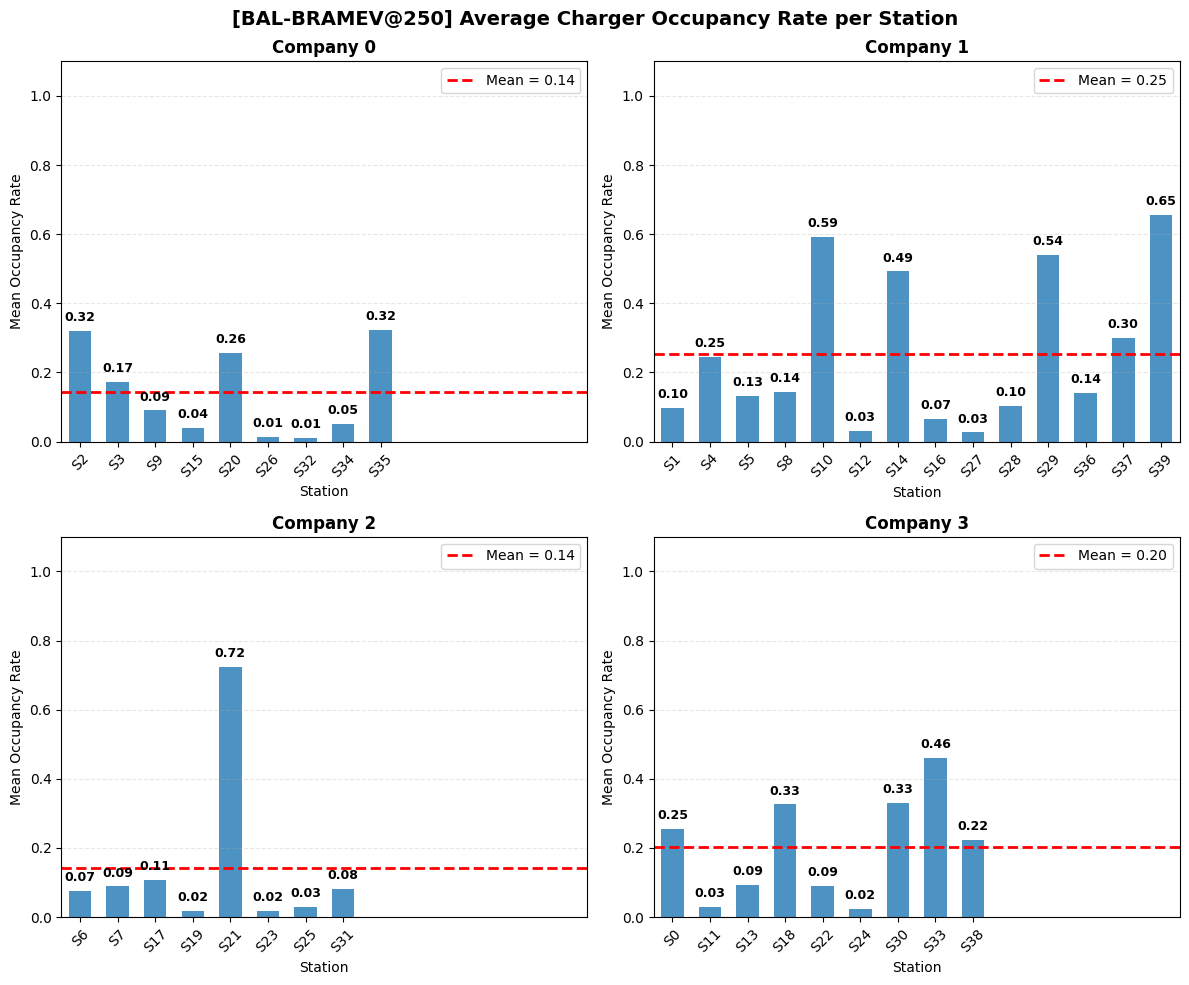

In [217]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

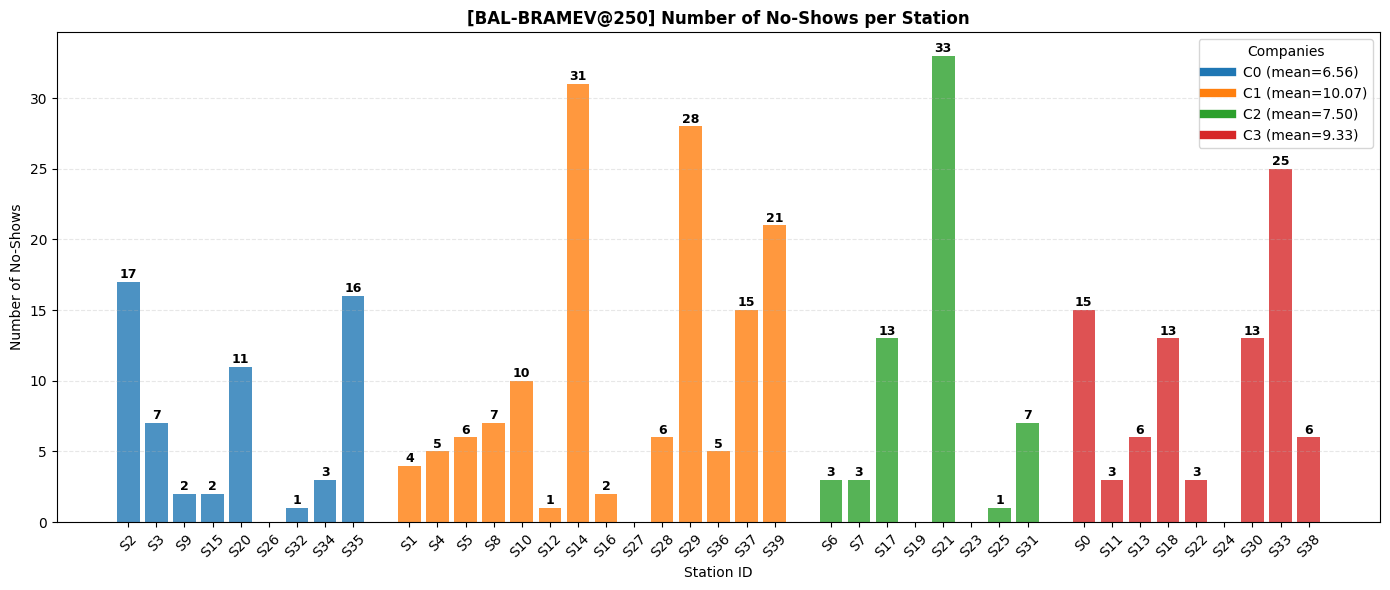

In [218]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [219]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,69,51,17,0,0,0.739130,0.246377,0.0,0.0
1,0,3,41,34,7,0,0,0.829268,0.170732,0.0,0.0
2,0,9,17,15,2,0,0,0.882353,0.117647,0.0,0.0
3,0,15,10,8,2,0,0,0.800000,0.200000,0.0,0.0
4,0,20,67,54,11,0,0,0.805970,0.164179,0.0,0.0
5,0,26,2,2,0,0,0,1.000000,0.000000,0.0,0.0
6,0,32,4,3,1,0,0,0.750000,0.250000,0.0,0.0
7,0,34,13,10,3,0,0,0.769231,0.230769,0.0,0.0
8,0,35,82,66,16,0,0,0.804878,0.195122,0.0,0.0
9,1,1,24,19,4,0,0,0.791667,0.166667,0.0,0.0


NUMBER OF REJECTED REQUESTS

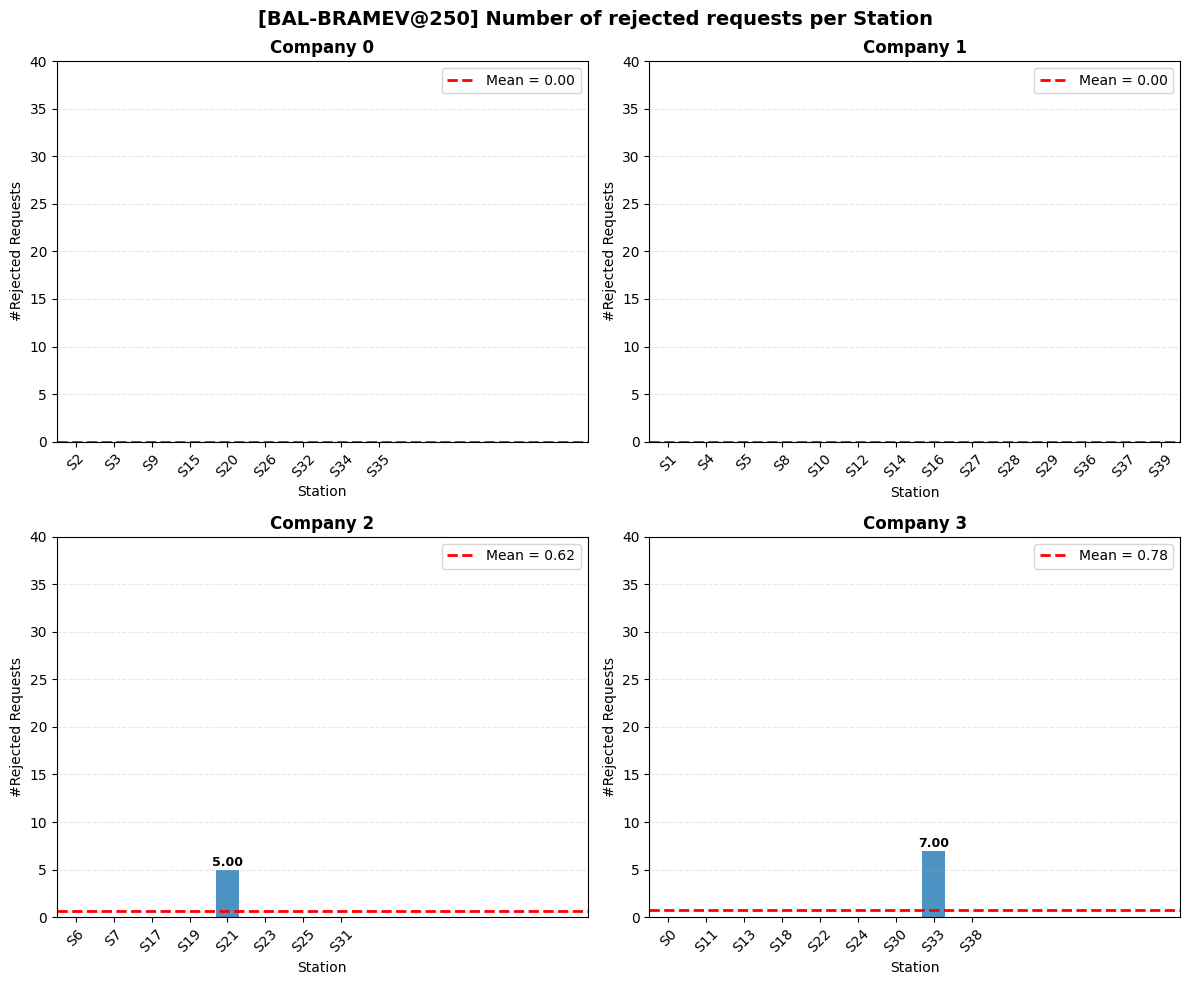

In [220]:
plot_society_station_rejected_request(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB NO RESPONSE PER CAR / FAIRNESS CAR

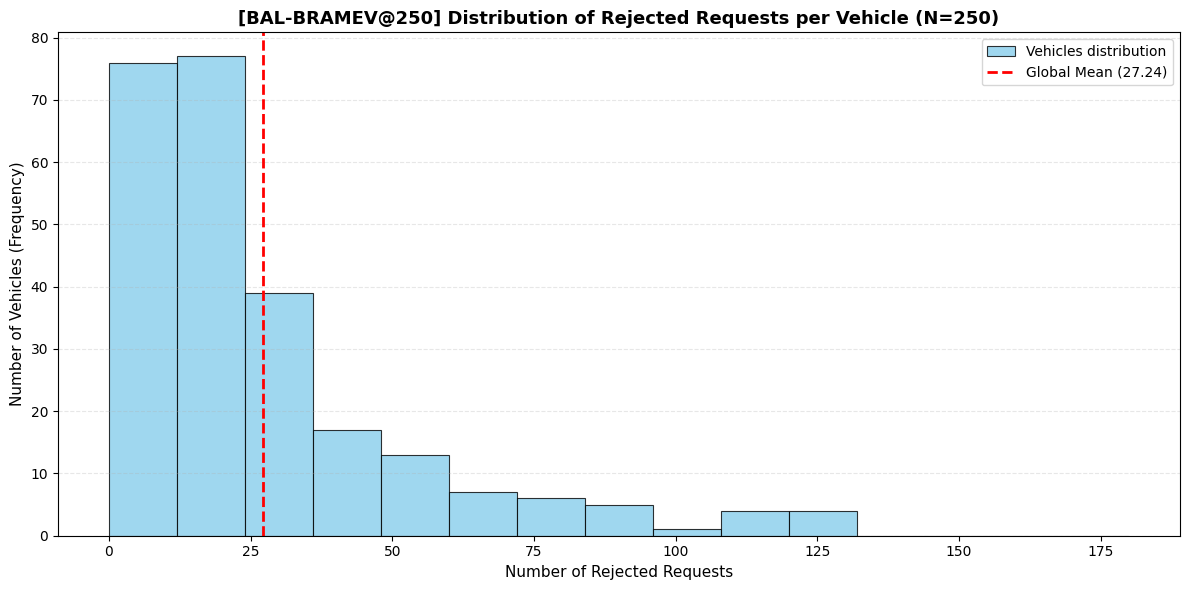

In [221]:
plot_car_rejected_hist(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

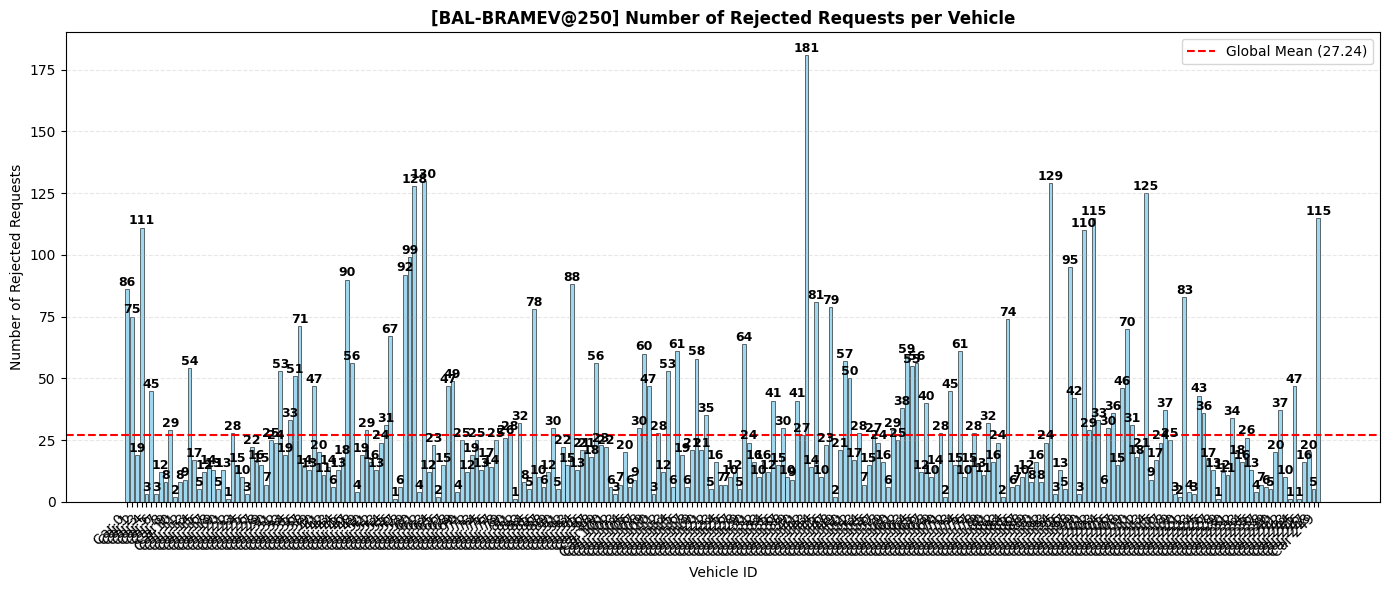

In [222]:
plot_car_rejected(cars, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NB REQUEST PER STATION / FAIRNESS STATION

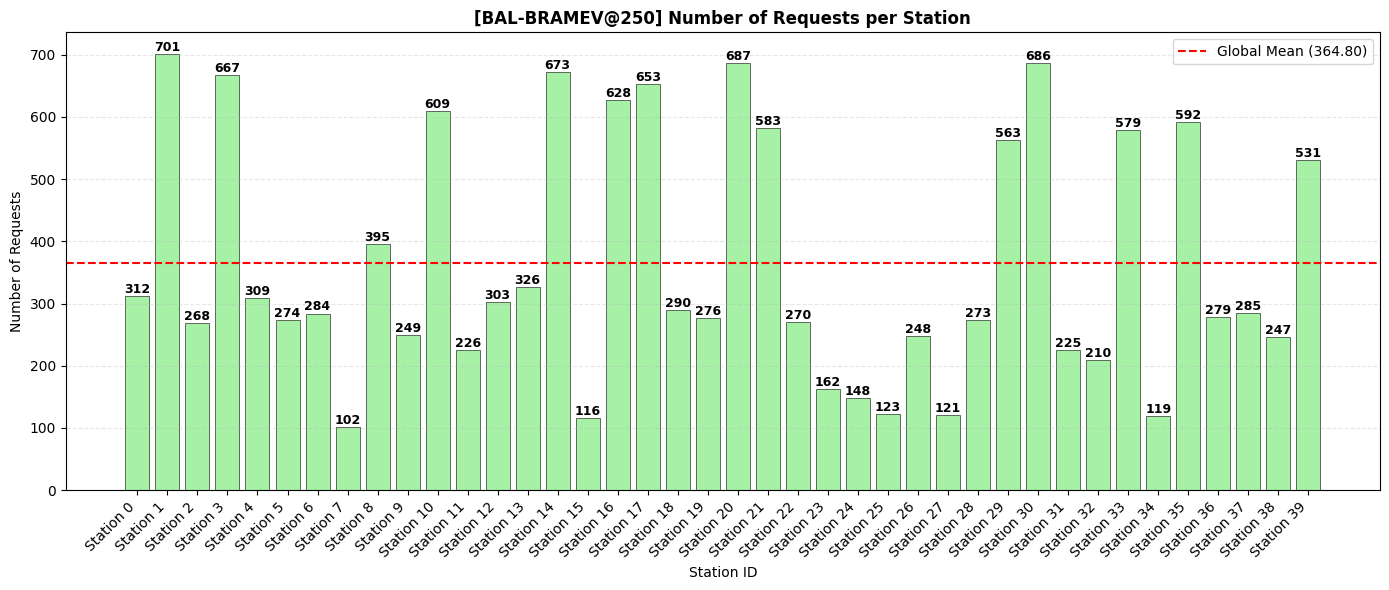

In [223]:
plot_station_requests(stations, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **COMPARISON**

##### *Params*

In [224]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

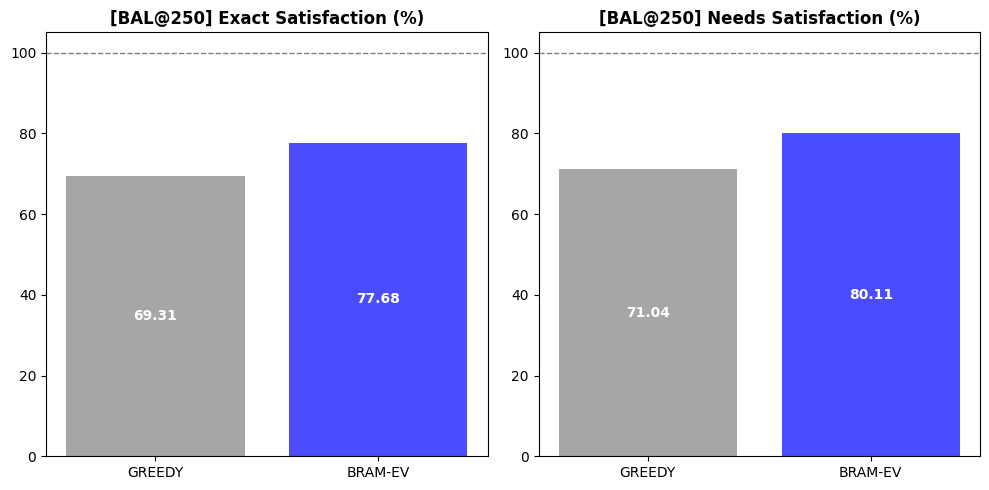

In [225]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

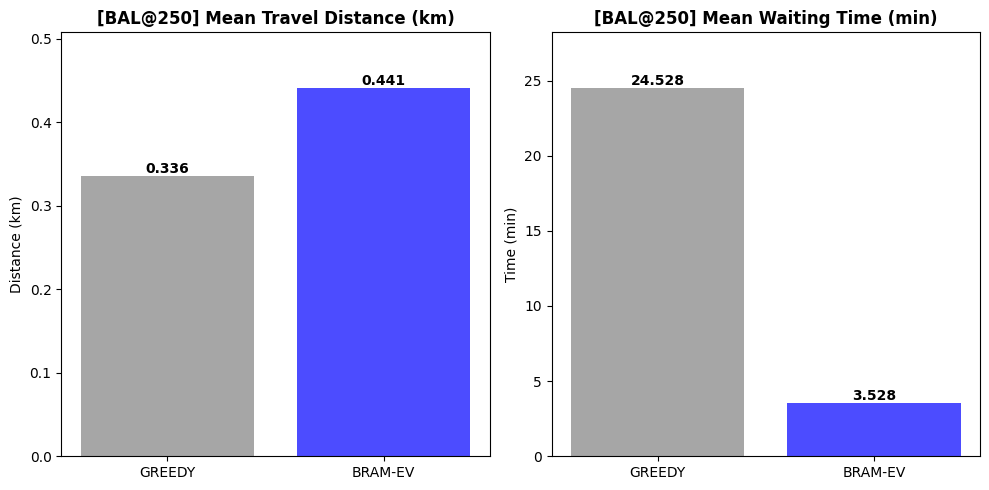

In [226]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

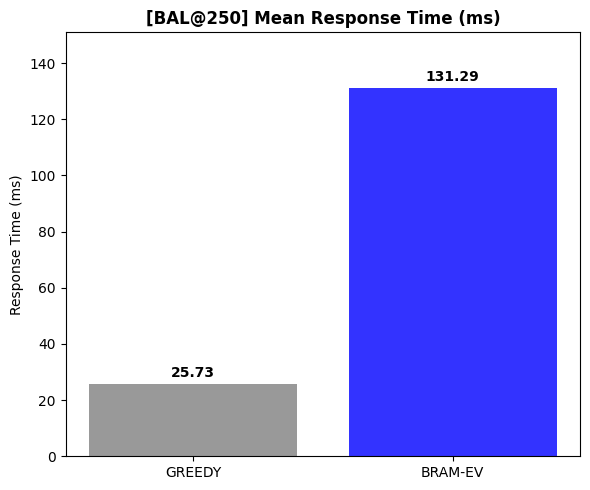

In [227]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

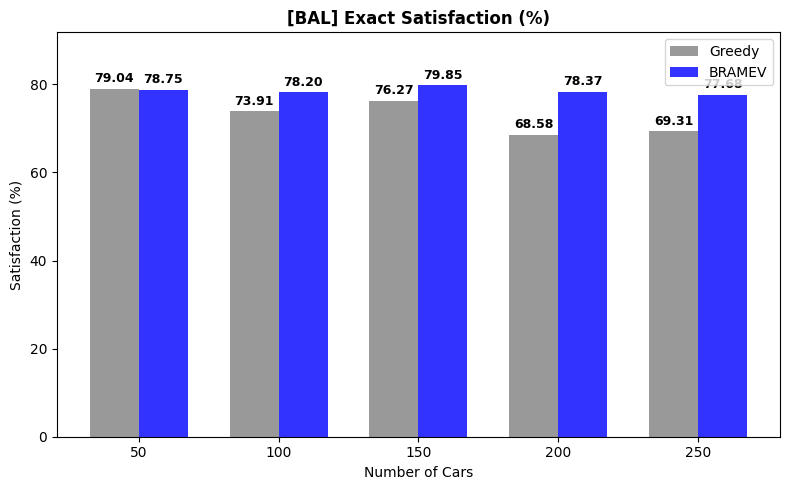

In [228]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

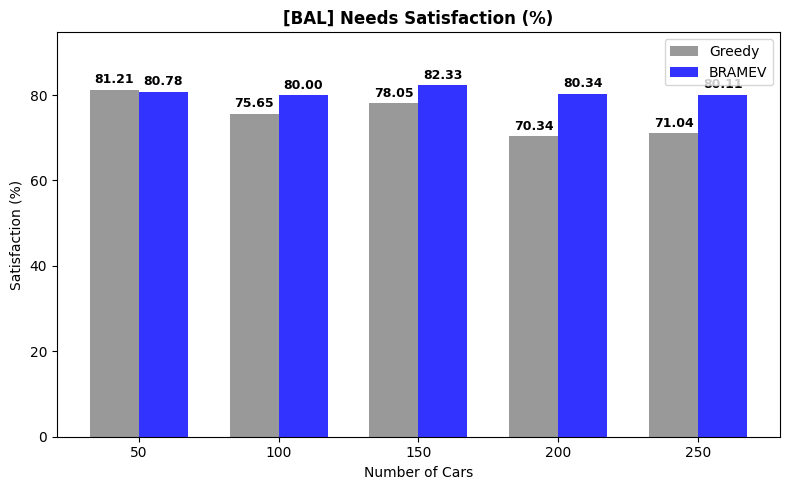

In [229]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

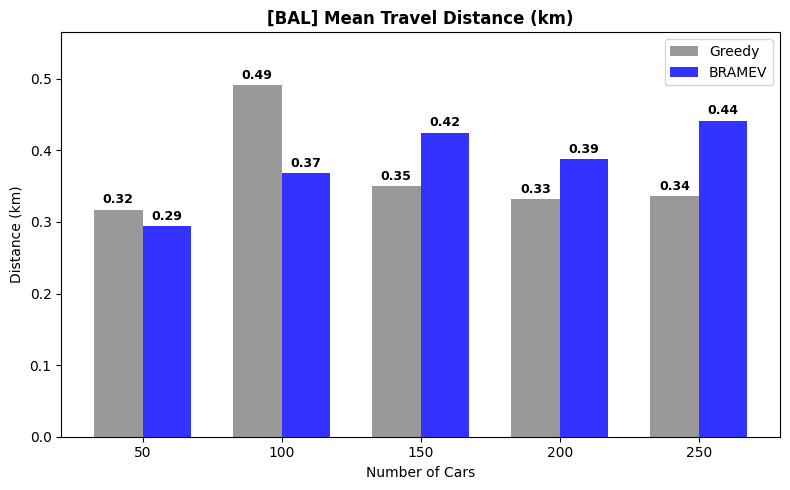

In [230]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


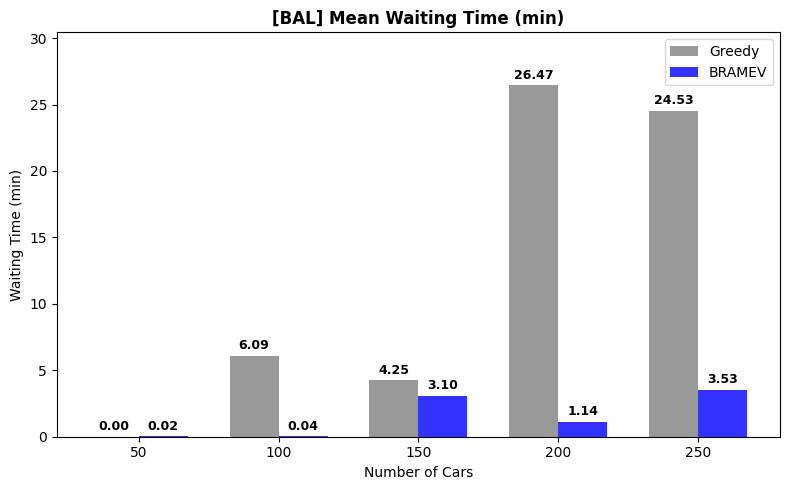

In [231]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


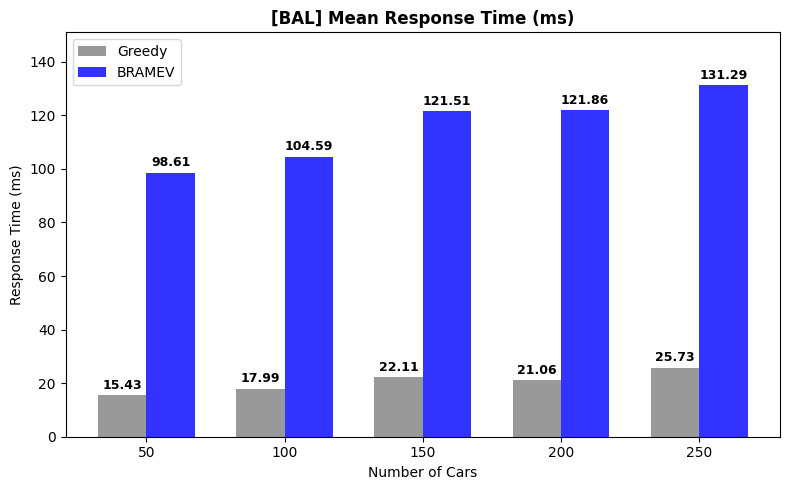

: 

In [ ]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
